# 02 - EDA Notebook

Notebook này là khung tự học cho **Giai đoạn 3 - Exploratory Data Analysis** của project Credit Risk Scoring & Loan Decisioning System.

Nguyên tắc sử dụng:
- Chỉ phân tích khám phá dữ liệu, chưa modeling.
- Không xử lý missing/outlier chính thức trong notebook này.
- Không chỉnh sửa trực tiếp `df_raw`; nếu cần tạo biến tạm thì dùng `df_eda = df_raw.copy()`.
- Mỗi bảng/biểu đồ cần đi kèm nhận xét: quan sát, ý nghĩa nghiệp vụ, rủi ro dữ liệu, bước tiếp theo.
- Luôn ghi chú potential leakage với các biến như `loan_grade`, `loan_int_rate` nếu xuất hiện.

## Section 0 - Mục tiêu và phạm vi EDA

**Mục tiêu:** hiểu phân phối dữ liệu, quan hệ giữa feature và target, tín hiệu rủi ro tín dụng, và các điểm cần chú ý trước feature engineering/modeling.

**Input:** dataset gốc trong `data/raw/`, đặc biệt sheet `Credit Risk Data`.

**Output mong muốn:**
- Target distribution và baseline default rate.
- Nhóm biến numeric/categorical/ID/target.
- Numeric EDA: distribution, skewness, outlier pattern, quan hệ với target.
- Categorical EDA: category distribution, default rate theo nhóm, rare groups.
- Correlation/redundancy review.
- Missing/outlier follow-up từ Data Audit.
- Leakage/fairness/proxy notes.
- Bảng tổng hợp `eda_findings` để đưa vào report.

In [1]:
# 0.1 - Thiết lập môi trường notebook
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# 1. Cấu hình hiển thị
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

# 2. Các hằng số chính
TARGET_COL = "loan_status"
ID_COL = "client_ID"
DATA_SHEET_NAME = "Credit Risk Data"
DICTIONARY_SHEET_NAME = "Data Dictionary"

# 3. Random seed
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Environment ready for EDA")
print(f"TARGET_COL      : {TARGET_COL}")
print(f"ID_COL          : {ID_COL}")
print(f"DATA_SHEET_NAME : {DATA_SHEET_NAME}")
print(f"RANDOM_STATE    : {RANDOM_STATE}")


Environment ready for EDA
TARGET_COL      : loan_status
ID_COL          : client_ID
DATA_SHEET_NAME : Credit Risk Data
RANDOM_STATE    : 42


In [2]:
# 0.2 - Xác định PROJECT_ROOT và đường dẫn dữ liệu

# ============================================================
# 1. Xác định PROJECT_ROOT
# ============================================================

CURRENT_CWD = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc project từ CWD hiện tại hoặc các thư mục cha."""
    for candidate in (start, *start.parents):
        required_folders = ("data", "notebooks", "src")
        if all((candidate / folder).exists() for folder in required_folders):
            return candidate
    raise FileNotFoundError(
        "Không xác định được PROJECT_ROOT. "
        "Hãy chạy notebook từ trong repo CREDIT_RISK_PROJECT hoặc một thư mục con của repo."
    )

PROJECT_ROOT = find_project_root(CURRENT_CWD)

# ============================================================
# 2. Khai báo đường dẫn chính
# ============================================================

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "Credit Risk Dataset.xlsx"
REPORT_PATH = PROJECT_ROOT / "reports"
FIGURE_PATH = PROJECT_ROOT / "notebooks" / "figures"

REPORT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# ============================================================
# 3. Kiểm tra cấu hình path
# ============================================================

print(f"CWD           : {CURRENT_CWD}")
print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"RAW_DATA_PATH : {RAW_DATA_PATH}")
print(f"File tồn tại  : {RAW_DATA_PATH.exists()}")
print(f"REPORT_PATH   : {REPORT_PATH}")
print(f"FIGURE_PATH   : {FIGURE_PATH}")

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy dataset tại: {RAW_DATA_PATH}" 
        "Hãy kiểm tra file 'Credit Risk Dataset.xlsx' trong data/raw/."
    )


CWD           : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
PROJECT_ROOT  : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
RAW_DATA_PATH : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\data\raw\Credit Risk Dataset.xlsx
File tồn tại  : True
REPORT_PATH   : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\reports
FIGURE_PATH   : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\notebooks\figures


In [3]:
# 0.3 - Load dataset gốc

# ============================================================
# 1. Kiểm tra file và sheet trước khi load
# ============================================================

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu raw tại: {RAW_DATA_PATH}")

file_suffix = RAW_DATA_PATH.suffix.lower()

# ============================================================
# 2. Load dữ liệu
# ============================================================

if file_suffix in {".xlsx", ".xls"}:
    excel_file = pd.ExcelFile(RAW_DATA_PATH, engine="openpyxl")
    print(f"Các sheet trong workbook: {excel_file.sheet_names}")

    if DATA_SHEET_NAME not in excel_file.sheet_names:
        raise ValueError(
            f"Không tìm thấy sheet '{DATA_SHEET_NAME}'. "
            f"Các sheet hiện có: {excel_file.sheet_names}"
        )

    df_raw = pd.read_excel(
        RAW_DATA_PATH,
        sheet_name=DATA_SHEET_NAME,
        engine="openpyxl",
    )
elif file_suffix == ".csv":
    df_raw = pd.read_csv(RAW_DATA_PATH)
else:
    raise ValueError(f"Định dạng file chưa được hỗ trợ: {file_suffix}")

# Bản copy để EDA tạm thời nếu cần. Không chỉnh sửa trực tiếp df_raw.
df_eda = df_raw.copy()
RAW_SHAPE = df_raw.shape

# ============================================================
# 3. Tổng quan dataset
# ============================================================

print()
print("=" * 70)
print(f"Dataset raw: {RAW_SHAPE[0]:,} dòng x {RAW_SHAPE[1]} cột")
print("=" * 70)

print()
print("--- 5 dòng đầu tiên ---")
display(df_raw.head())

print()
print("--- Thông tin DataFrame ---")
df_raw.info(memory_usage="deep")

# ============================================================
# 4. Kiểm tra nhanh sau khi load
# ============================================================

print()
print("--- Kiểm tra nhanh sau khi load ---")
print(f"Target '{TARGET_COL}' tồn tại : {TARGET_COL in df_raw.columns}")
print(f"ID '{ID_COL}' tồn tại         : {ID_COL in df_raw.columns}")
print(f"Tên cột bị trùng              : {int(df_raw.columns.duplicated().sum())}")

if TARGET_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy target column: {TARGET_COL}")


Các sheet trong workbook: ['Credit Risk Data', 'Data Dictionary']



Dataset raw: 32,581 dòng x 29 cột

--- 5 dòng đầu tiên ---


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.5932,"8,402.4538",0.7356,14,0.4956,0
1,CUST_00002,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.1042,"1,607.8028",0.2716,10,0.5854,3
2,CUST_00003,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.5729,"2,760.5056",0.8605,14,0.7507,0
3,CUST_00004,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.5344,"7,155.2862",0.6436,15,0.3793,0
4,CUST_00005,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.6434,"15,626.1534",0.9306,4,0.2281,0



--- Thông tin DataFrame ---


<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  str    
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  str    
 6   loan_grade                  32581 non-null  str    
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  str    
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      32581 non-null

In [4]:
# 0.4 - Kiểm tra sức khỏe dữ liệu nhanh trước EDA

# ============================================================
# 1. Tính các chỉ số data health cơ bản
# ============================================================

row_count, column_count = df_raw.shape
duplicate_row_count = int(df_raw.duplicated().sum())
duplicate_row_rate = duplicate_row_count / row_count

if ID_COL in df_raw.columns:
    duplicate_id_count = int(df_raw[ID_COL].duplicated().sum())
    duplicate_id_rate = duplicate_id_count / row_count
else:
    duplicate_id_count = np.nan
    duplicate_id_rate = np.nan

missing_by_column = df_raw.isna().sum().sort_values(ascending=False)
columns_with_missing = int((missing_by_column > 0).sum())
total_missing_values = int(missing_by_column.sum())

target_missing = int(df_raw[TARGET_COL].isna().sum()) if TARGET_COL in df_raw.columns else np.nan
target_unique_values = (
    sorted(df_raw[TARGET_COL].dropna().unique().tolist())
    if TARGET_COL in df_raw.columns
    else []
)

health_snapshot = pd.DataFrame([
    {
        "rows": row_count,
        "columns": column_count,
        "duplicate_rows": duplicate_row_count,
        "duplicate_row_rate": duplicate_row_rate,
        "duplicate_ids": duplicate_id_count,
        "duplicate_id_rate": duplicate_id_rate,
        "columns_with_missing": columns_with_missing,
        "total_missing_values": total_missing_values,
        "target_missing": target_missing,
        "target_unique_values": target_unique_values,
    }
])

# ============================================================
# 2. Hiển thị snapshot và missing overview
# ============================================================

print("=" * 80)
print("QUICK DATA HEALTH SNAPSHOT")
print("=" * 80)

display(
    health_snapshot.style.format({
        "duplicate_row_rate": "{:.2%}",
        "duplicate_id_rate": "{:.2%}",
    })
)

missing_overview = (
    missing_by_column[missing_by_column > 0]
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)

if missing_overview.empty:
    print("Không phát hiện missing values ở checkpoint EDA.")
else:
    missing_overview["missing_rate"] = missing_overview["missing_count"] / row_count
    print()
    print("--- Columns with missing values ---")
    display(missing_overview.style.format({"missing_rate": "{:.2%}"}))

# ============================================================
# 3. Nhận xét nhanh để định hướng EDA
# ============================================================

quick_health_notes = []

if duplicate_row_count == 0:
    quick_health_notes.append("Không phát hiện duplicate rows ở checkpoint EDA.")
else:
    quick_health_notes.append(f"Có {duplicate_row_count:,} duplicate rows cần review.")

if ID_COL in df_raw.columns and duplicate_id_count == 0:
    quick_health_notes.append(f"{ID_COL} đang unique.")
elif ID_COL in df_raw.columns:
    quick_health_notes.append(f"{ID_COL} có {duplicate_id_count:,} giá trị bị lặp.")
else:
    quick_health_notes.append(f"Không có cột {ID_COL}, không kiểm tra duplicate ID được.")

if columns_with_missing == 0:
    quick_health_notes.append("Không có cột missing.")
else:
    quick_health_notes.append(
        f"Có {columns_with_missing} cột missing; cần nối kết quả với Data Audit trước khi xử lý."
    )

if target_missing == 0:
    quick_health_notes.append(f"Target {TARGET_COL} không bị missing.")
else:
    quick_health_notes.append(f"Target {TARGET_COL} có {target_missing:,} missing rows, cần xử lý trước modeling.")

quick_health_note = " ".join(quick_health_notes)
print()
print("Quick health note:")
print(quick_health_note)


QUICK DATA HEALTH SNAPSHOT


,rows,columns,duplicate_rows,duplicate_row_rate,duplicate_ids,duplicate_id_rate,columns_with_missing,total_missing_values,target_missing,target_unique_values
0,32581,29,0,0.00%,0,0.00%,2,4011,0,"[0, 1]"



--- Columns with missing values ---


,column,missing_count,missing_rate
0,loan_int_rate,3116,9.56%
1,person_emp_length,895,2.75%



Quick health note:
Không phát hiện duplicate rows ở checkpoint EDA. client_ID đang unique. Có 2 cột missing; cần nối kết quả với Data Audit trước khi xử lý. Target loan_status không bị missing.


## Section 1 - Target Analysis

Theo kế hoạch, target là `loan_status` với ý nghĩa dự kiến:
- `0` = non-default.
- `1` = default.

Trong EDA cần xác nhận phân phối target, baseline default rate và mức độ imbalance trước khi nghĩ đến metric/modeling.

TARGET DISTRIBUTION
Target column        : loan_status
Target missing count : 0
Observed classes     : [0, 1]

--- Target count/rate ---


,loan_status,count,rate
0,0,25473,78.18%
1,1,7108,21.82%


Default rate      : 21.82%
Non-default rate  : 78.18%
Imbalance ratio   : 3.58:1


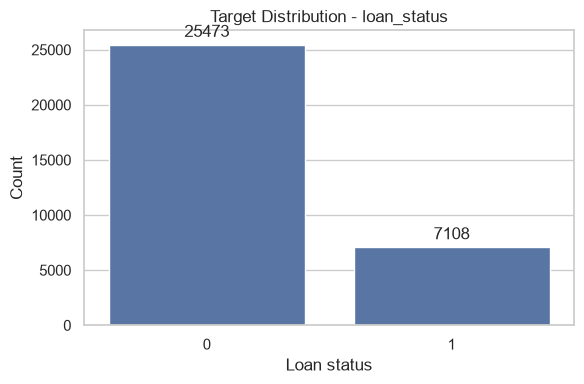


Target note:
Default rate is 21.82%; class balance is moderately imbalanced. For later modeling, do not rely only on accuracy; compare ROC-AUC, PR-AUC, recall/precision by threshold, and probability calibration.


In [5]:
# 1.1 - Phân phối target

# ============================================================
# 1. Kiểm tra target column
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy target column: {TARGET_COL}")

target_series = df_raw[TARGET_COL]
target_missing_count = int(target_series.isna().sum())
target_unique_values = sorted(target_series.dropna().unique().tolist())
expected_target_values = {0, 1}
unexpected_target_values = sorted(set(target_unique_values) - expected_target_values)

print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)
print(f"Target column        : {TARGET_COL}")
print(f"Target missing count : {target_missing_count:,}")
print(f"Observed classes     : {target_unique_values}")

if unexpected_target_values:
    print(f"WARNING - Unexpected target values: {unexpected_target_values}")

# ============================================================
# 2. Tính count/rate/default rate
# ============================================================

target_distribution = (
    target_series
    .value_counts(dropna=False)
    .rename_axis(TARGET_COL)
    .reset_index(name="count")
)

target_distribution["rate"] = target_distribution["count"] / len(df_raw)
target_distribution = target_distribution.sort_values(TARGET_COL).reset_index(drop=True)

default_rate = float(target_series.mean())
non_default_rate = 1 - default_rate
class_imbalance_ratio = (
    target_distribution["count"].max() / target_distribution["count"].min()
    if len(target_distribution) >= 2 and target_distribution["count"].min() > 0
    else np.nan
)

print()
print("--- Target count/rate ---")
display(target_distribution.style.format({"rate": "{:.2%}"}))

print(f"Default rate      : {default_rate:.2%}")
print(f"Non-default rate  : {non_default_rate:.2%}")
print(f"Imbalance ratio   : {class_imbalance_ratio:.2f}:1")

# ============================================================
# 3. Visualize target distribution
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_raw, x=TARGET_COL, order=target_distribution[TARGET_COL], ax=ax)
ax.set_title("Target Distribution - loan_status")
ax.set_xlabel("Loan status")
ax.set_ylabel("Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Nhận xét nhanh phục vụ EDA/modeling sau này
# ============================================================

if default_rate < 0.10 or default_rate > 0.90:
    imbalance_assessment = "strongly imbalanced"
elif default_rate < 0.25 or default_rate > 0.75:
    imbalance_assessment = "moderately imbalanced"
else:
    imbalance_assessment = "not severely imbalanced"

target_note = (
    f"Default rate is {default_rate:.2%}; class balance is {imbalance_assessment}. "
    "For later modeling, do not rely only on accuracy; compare ROC-AUC, PR-AUC, "
    "recall/precision by threshold, and probability calibration."
)

print()
print("Target note:")
print(target_note)


## Section 2 - Phân nhóm biến

Trước khi EDA sâu, cần phân nhóm biến để chọn loại bảng/biểu đồ phù hợp.

Các nhóm cần có:
- Numeric features.
- Categorical features.
- Identifier.
- Target.
- Potential leakage candidates.
- Sensitive/proxy candidates.

In [6]:
# 2.1 - Phân nhóm columns

# ============================================================
# 1. Tách nhóm column theo vai trò cơ bản
# ============================================================

all_cols = df_raw.columns.tolist()
identifier_cols = [col for col in [ID_COL] if col in df_raw.columns]
target_cols = [col for col in [TARGET_COL] if col in df_raw.columns]

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_raw.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

feature_cols = [
    col for col in all_cols
    if col not in set(identifier_cols + target_cols)
]

numeric_feature_cols = [col for col in numeric_cols if col in feature_cols]
categorical_feature_cols = [col for col in categorical_cols if col in feature_cols]

# Các cột còn lại nếu dtype không rơi vào numeric/categorical phổ biến.
other_feature_cols = sorted(
    set(feature_cols) - set(numeric_feature_cols) - set(categorical_feature_cols)
)

# ============================================================
# 2. Watchlist cho leakage và sensitive/proxy variables
# ============================================================

potential_leakage_cols = [
    col for col in ["loan_grade", "loan_int_rate"]
    if col in df_raw.columns
]

sensitive_or_proxy_cols = [
    col for col in ["gender", "country", "state", "city", "city_latitude", "city_longitude"]
    if col in df_raw.columns
]

geographic_cols = [
    col for col in ["country", "state", "city", "city_latitude", "city_longitude"]
    if col in df_raw.columns
]

binary_like_cols = [
    col for col in feature_cols
    if df_raw[col].nunique(dropna=True) == 2
]

high_cardinality_categorical_cols = [
    col for col in categorical_feature_cols
    if df_raw[col].nunique(dropna=True) > 20
]

# ============================================================
# 3. Tạo summary table để review nhanh
# ============================================================

feature_group_records = [
    {
        "group": "all_columns",
        "count": len(all_cols),
        "columns": all_cols,
        "note": "Toàn bộ columns trong raw dataset.",
    },
    {
        "group": "identifier_cols",
        "count": len(identifier_cols),
        "columns": identifier_cols,
        "note": "Không dùng như feature modeling.",
    },
    {
        "group": "target_cols",
        "count": len(target_cols),
        "columns": target_cols,
        "note": "Biến mục tiêu; không đưa vào X.",
    },
    {
        "group": "feature_cols",
        "count": len(feature_cols),
        "columns": feature_cols,
        "note": "Candidates trước khi loại leakage/policy.",
    },
    {
        "group": "numeric_feature_cols",
        "count": len(numeric_feature_cols),
        "columns": numeric_feature_cols,
        "note": "Phù hợp numeric EDA, histogram, correlation.",
    },
    {
        "group": "categorical_feature_cols",
        "count": len(categorical_feature_cols),
        "columns": categorical_feature_cols,
        "note": "Phù hợp countplot/default rate theo nhóm.",
    },
    {
        "group": "other_feature_cols",
        "count": len(other_feature_cols),
        "columns": other_feature_cols,
        "note": "Cần review nếu không rỗng.",
    },
    {
        "group": "potential_leakage_cols",
        "count": len(potential_leakage_cols),
        "columns": potential_leakage_cols,
        "note": "EDA được xem, nhưng không mặc định dùng Primary Model.",
    },
    {
        "group": "sensitive_or_proxy_cols",
        "count": len(sensitive_or_proxy_cols),
        "columns": sensitive_or_proxy_cols,
        "note": "Dùng cho fairness/proxy review, cần cân nhắc trước modeling.",
    },
    {
        "group": "binary_like_cols",
        "count": len(binary_like_cols),
        "columns": binary_like_cols,
        "note": "Có thể cần xử lý như categorical/binary.",
    },
    {
        "group": "high_cardinality_categorical_cols",
        "count": len(high_cardinality_categorical_cols),
        "columns": high_cardinality_categorical_cols,
        "note": "Cần cẩn thận khi encode/modeling.",
    },
]

feature_group_summary = pd.DataFrame(feature_group_records)

print("=" * 90)
print("FEATURE GROUP SUMMARY")
print("=" * 90)
display(feature_group_summary)

# ============================================================
# 4. Validation checks để tránh phân nhóm sai nghiêm trọng
# ============================================================

if set(identifier_cols).intersection(feature_cols):
    raise ValueError("Identifier column vẫn nằm trong feature_cols.")

if set(target_cols).intersection(feature_cols):
    raise ValueError("Target column vẫn nằm trong feature_cols.")

if other_feature_cols:
    print("WARNING - Có feature columns chưa được phân loại numeric/categorical:")
    print(other_feature_cols)

# ============================================================
# 5. Notes cho các phần EDA sau
# ============================================================

feature_group_notes = []
feature_group_notes.append(
    f"EDA feature candidates: {len(feature_cols)} columns "
    f"({len(numeric_feature_cols)} numeric, {len(categorical_feature_cols)} categorical)."
)

if potential_leakage_cols:
    feature_group_notes.append(
        "Potential leakage watchlist: " + ", ".join(potential_leakage_cols) + "."
    )

if sensitive_or_proxy_cols:
    feature_group_notes.append(
        "Sensitive/proxy watchlist: " + ", ".join(sensitive_or_proxy_cols) + "."
    )

if high_cardinality_categorical_cols:
    feature_group_notes.append(
        "High-cardinality categorical columns need careful review: "
        + ", ".join(high_cardinality_categorical_cols) + "."
    )

feature_group_note = " ".join(feature_group_notes)

print()
print("Feature group note:")
print(feature_group_note)


FEATURE GROUP SUMMARY


,group,count,columns,note
0,all_columns,29,"[client_ID, person_age, person_income, person_...",Toàn bộ columns trong raw dataset.
1,identifier_cols,1,[client_ID],Không dùng như feature modeling.
2,target_cols,1,[loan_status],Biến mục tiêu; không đưa vào X.
3,feature_cols,27,"[person_age, person_income, person_home_owners...",Candidates trước khi loại leakage/policy.
4,numeric_feature_cols,16,"[person_age, person_income, person_emp_length,...","Phù hợp numeric EDA, histogram, correlation."
5,categorical_feature_cols,11,"[person_home_ownership, loan_intent, loan_grad...",Phù hợp countplot/default rate theo nhóm.
6,other_feature_cols,0,[],Cần review nếu không rỗng.
7,potential_leakage_cols,2,"[loan_grade, loan_int_rate]","EDA được xem, nhưng không mặc định dùng Primar..."
8,sensitive_or_proxy_cols,6,"[gender, country, state, city, city_latitude, ...","Dùng cho fairness/proxy review, cần cân nhắc t..."
9,binary_like_cols,2,"[cb_person_default_on_file, gender]",Có thể cần xử lý như categorical/binary.



Feature group note:
EDA feature candidates: 27 columns (16 numeric, 11 categorical). Potential leakage watchlist: loan_grade, loan_int_rate. Sensitive/proxy watchlist: gender, country, state, city, city_latitude, city_longitude.


## Section 3 - Numeric EDA

Cần xem distribution, skewness, missing, outlier pattern và quan hệ giữa numeric features với target.

Không kết luận một điểm là invalid chỉ vì nó là outlier thống kê; cần liên kết với business rules từ Data Audit.

In [7]:
# 3.1 - Numeric summary table

# ============================================================
# 1. Kiểm tra input numeric features
# ============================================================

if "numeric_feature_cols" not in globals():
    raise NameError("Chưa có numeric_feature_cols. Hãy chạy cell 2.1 trước.")

if not numeric_feature_cols:
    raise ValueError("numeric_feature_cols đang rỗng; không có biến numeric để EDA.")

missing_numeric_cols = [col for col in numeric_feature_cols if col not in df_raw.columns]
if missing_numeric_cols:
    raise KeyError(f"Các numeric_feature_cols không tồn tại trong df_raw: {missing_numeric_cols}")

# ============================================================
# 2. Tạo thống kê mô tả numeric
# ============================================================

PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
numeric_df = df_raw[numeric_feature_cols]

base_numeric_stats = (
    numeric_df
    .describe(percentiles=PERCENTILES)
    .T
    .rename(columns={
        "1%": "p01",
        "5%": "p05",
        "25%": "p25",
        "50%": "median",
        "75%": "p75",
        "95%": "p95",
        "99%": "p99",
    })
)

numeric_eda_summary = pd.DataFrame(index=numeric_feature_cols)
numeric_eda_summary["dtype"] = numeric_df.dtypes.astype(str)
numeric_eda_summary["non_missing_count"] = numeric_df.notna().sum()
numeric_eda_summary["missing_count"] = numeric_df.isna().sum()
numeric_eda_summary["missing_rate"] = numeric_df.isna().mean()

stat_cols = ["mean", "std", "min", "p01", "p05", "p25", "median", "p75", "p95", "p99", "max"]
for col in stat_cols:
    numeric_eda_summary[col] = base_numeric_stats[col]

numeric_eda_summary["skewness"] = numeric_df.skew(numeric_only=True)
numeric_eda_summary["zero_count"] = (numeric_df == 0).sum()
numeric_eda_summary["zero_rate"] = numeric_eda_summary["zero_count"] / len(df_raw)
numeric_eda_summary["negative_count"] = (numeric_df < 0).sum()

# ============================================================
# 3. Tạo các flag review phục vụ EDA
# ============================================================

STRONG_SKEW_THRESHOLD = 2.0
MODERATE_SKEW_THRESHOLD = 1.0
HIGH_MISSING_THRESHOLD = 0.05
P99_MAX_RATIO_THRESHOLD = 5.0

review_notes = {}

for column in numeric_feature_cols:
    notes = []
    row = numeric_eda_summary.loc[column]

    if row["missing_rate"] > 0:
        notes.append(f"missing={row['missing_rate']:.2%}")

    if pd.notna(row["skewness"]):
        abs_skew = abs(row["skewness"])
        if abs_skew >= STRONG_SKEW_THRESHOLD:
            notes.append(f"strong_skew={row['skewness']:.2f}")
        elif abs_skew >= MODERATE_SKEW_THRESHOLD:
            notes.append(f"moderate_skew={row['skewness']:.2f}")

    if pd.notna(row["p99"]) and row["p99"] != 0 and pd.notna(row["max"]):
        p99_max_ratio = abs(row["max"] / row["p99"])
        if p99_max_ratio >= P99_MAX_RATIO_THRESHOLD:
            notes.append(f"max_vs_p99_ratio={p99_max_ratio:.1f}")

    if row["negative_count"] > 0:
        notes.append(f"negative_count={int(row['negative_count']):,}")

    if column in potential_leakage_cols:
        notes.append("potential_leakage_watchlist")

    if column in sensitive_or_proxy_cols:
        notes.append("sensitive_or_proxy_watchlist")

    review_notes[column] = " | ".join(notes)

numeric_eda_summary["review_note"] = pd.Series(review_notes)
numeric_eda_summary["needs_review"] = numeric_eda_summary["review_note"].ne("")

numeric_eda_summary = (
    numeric_eda_summary
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values(["needs_review", "missing_rate", "skewness"], ascending=[False, False, False])
    .reset_index(drop=True)
)

numeric_review_cols = numeric_eda_summary.loc[
    numeric_eda_summary["needs_review"],
    "column",
].tolist()

numeric_review_summary = numeric_eda_summary.loc[
    numeric_eda_summary["needs_review"],
    ["column", "missing_rate", "min", "median", "p95", "p99", "max", "skewness", "zero_rate", "negative_count", "review_note"],
].copy()

# ============================================================
# 4. Hiển thị kết quả
# ============================================================

print("=" * 90)
print("NUMERIC EDA SUMMARY")
print("=" * 90)
print(f"Numeric feature columns: {len(numeric_feature_cols)}")
print(f"Numeric columns needing review: {len(numeric_review_cols)}")

formatters = {
    "missing_rate": "{:.2%}",
    "zero_rate": "{:.2%}",
    "mean": "{:,.4f}",
    "std": "{:,.4f}",
    "min": "{:,.4f}",
    "p01": "{:,.4f}",
    "p05": "{:,.4f}",
    "p25": "{:,.4f}",
    "median": "{:,.4f}",
    "p75": "{:,.4f}",
    "p95": "{:,.4f}",
    "p99": "{:,.4f}",
    "max": "{:,.4f}",
    "skewness": "{:.2f}",
}

display(numeric_eda_summary.style.format(formatters))

print()
print("--- Numeric columns needing review ---")
if numeric_review_summary.empty:
    print("Không có numeric column nào bị flag review theo ngưỡng hiện tại.")
else:
    display(numeric_review_summary.style.format(formatters))

# ============================================================
# 5. Note ngắn để dùng ở phần tổng hợp EDA
# ============================================================

numeric_summary_note = (
    f"Reviewed {len(numeric_feature_cols)} numeric features; "
    f"{len(numeric_review_cols)} were flagged for missingness, skew/outlier pattern, "
    "negative values, leakage watchlist, or sensitive/proxy watchlist."
)

print()
print("Numeric summary note:")
print(numeric_summary_note)


NUMERIC EDA SUMMARY
Numeric feature columns: 16
Numeric columns needing review: 12


,column,dtype,non_missing_count,missing_count,missing_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,skewness,zero_count,zero_rate,negative_count,review_note,needs_review
0,loan_int_rate,float64,29465,3116,9.56%,11.0117,3.2405,5.4200,5.4200,6.0300,7.9000,10.9900,13.4700,16.3200,18.6200,23.2200,0.21,0,0.00%,0,missing=9.56% | potential_leakage_watchlist,True
1,person_emp_length,float64,31686,895,2.75%,4.7897,4.1426,0.0000,0.0000,0.0000,2.0000,4.0000,7.0000,13.0000,18.0000,123.0000,2.61,4105,12.60%,0,missing=2.75% | strong_skew=2.61 | max_vs_p99_ratio=6.8,True
2,person_income,int64,32581,0,0.00%,"66,074.8485","61,983.1192","4,000.0000","14,400.0000","22,880.0000","38,500.0000","55,000.0000","79,200.0000","138,000.0000","225,200.0000","6,000,000.0000",32.87,0,0.00%,0,strong_skew=32.87 | max_vs_p99_ratio=26.6,True
3,other_debt,float64,32581,0,0.00%,"11,567.9598","13,060.9309",225.2074,"1,483.1146","2,510.9244","5,387.1685","8,995.0706","14,562.9303","27,965.0964","46,354.6458","1,187,998.9145",28.46,0,0.00%,0,strong_skew=28.46 | max_vs_p99_ratio=25.6,True
4,person_age,int64,32581,0,0.00%,27.7346,6.3481,20.0000,21.0000,22.0000,23.0000,26.0000,30.0000,40.0000,50.0000,144.0000,2.58,0,0.00%,0,strong_skew=2.58,True
5,cb_person_cred_hist_length,int64,32581,0,0.00%,5.8042,4.0550,2.0000,2.0000,2.0000,3.0000,4.0000,8.0000,14.0000,17.0000,30.0000,1.66,0,0.00%,0,moderate_skew=1.66,True
6,past_delinquencies,int64,32581,0,0.00%,0.5051,0.7117,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,6.0000,1.40,19702,60.47%,0,moderate_skew=1.40,True
7,loan_amnt,int64,32581,0,0.00%,"9,589.3711","6,322.0866",500.0000,"1,000.0000","2,000.0000","5,000.0000","8,000.0000","12,200.0000","24,000.0000","29,800.0000","35,000.0000",1.19,0,0.00%,0,moderate_skew=1.19,True
8,loan_to_income_ratio,float64,32581,0,0.00%,0.1706,0.1070,0.0008,0.0200,0.0389,0.0897,0.1481,0.2292,0.3788,0.5000,0.8300,1.07,0,0.00%,0,moderate_skew=1.07,True
9,loan_percent_income,float64,32581,0,0.00%,0.1702,0.1068,0.0000,0.0200,0.0400,0.0900,0.1500,0.2300,0.3800,0.5000,0.8300,1.06,9,0.03%,0,moderate_skew=1.06,True



--- Numeric columns needing review ---


,column,missing_rate,min,median,p95,p99,max,skewness,zero_rate,negative_count,review_note
0,loan_int_rate,9.56%,5.4200,10.9900,16.3200,18.6200,23.2200,0.21,0.00%,0,missing=9.56% | potential_leakage_watchlist
1,person_emp_length,2.75%,0.0000,4.0000,13.0000,18.0000,123.0000,2.61,12.60%,0,missing=2.75% | strong_skew=2.61 | max_vs_p99_ratio=6.8
2,person_income,0.00%,"4,000.0000","55,000.0000","138,000.0000","225,200.0000","6,000,000.0000",32.87,0.00%,0,strong_skew=32.87 | max_vs_p99_ratio=26.6
3,other_debt,0.00%,225.2074,"8,995.0706","27,965.0964","46,354.6458","1,187,998.9145",28.46,0.00%,0,strong_skew=28.46 | max_vs_p99_ratio=25.6
4,person_age,0.00%,20.0000,26.0000,40.0000,50.0000,144.0000,2.58,0.00%,0,strong_skew=2.58
5,cb_person_cred_hist_length,0.00%,2.0000,4.0000,14.0000,17.0000,30.0000,1.66,0.00%,0,moderate_skew=1.66
6,past_delinquencies,0.00%,0.0000,0.0000,2.0000,3.0000,6.0000,1.40,60.47%,0,moderate_skew=1.40
7,loan_amnt,0.00%,500.0000,"8,000.0000","24,000.0000","29,800.0000","35,000.0000",1.19,0.00%,0,moderate_skew=1.19
8,loan_to_income_ratio,0.00%,0.0008,0.1481,0.3788,0.5000,0.8300,1.07,0.00%,0,moderate_skew=1.07
9,loan_percent_income,0.00%,0.0000,0.1500,0.3800,0.5000,0.8300,1.06,0.03%,0,moderate_skew=1.06



Numeric summary note:
Reviewed 16 numeric features; 12 were flagged for missingness, skew/outlier pattern, negative values, leakage watchlist, or sensitive/proxy watchlist.


NUMERIC DISTRIBUTION PLOTS
Numeric plot columns (10): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'loan_to_income_ratio', 'debt_to_income_ratio', 'credit_utilization_ratio', 'other_debt']


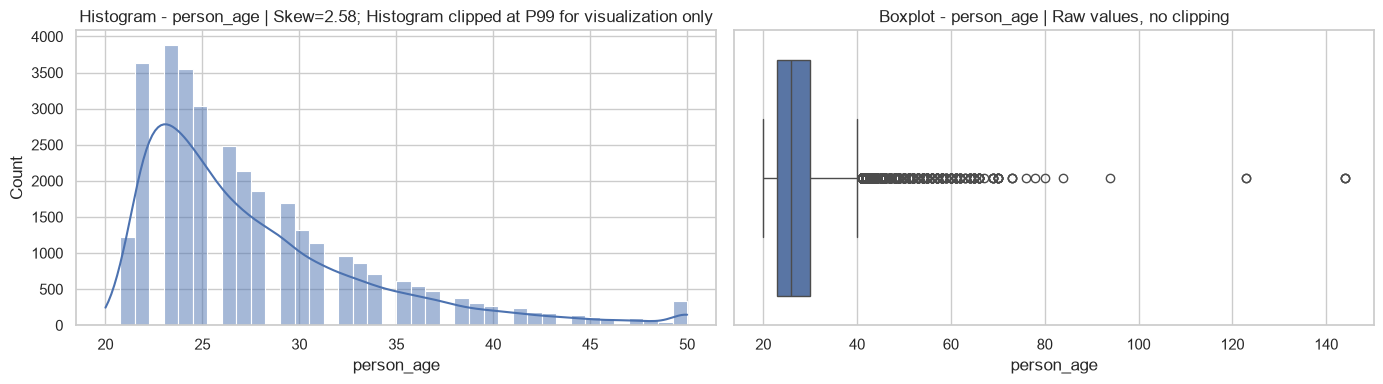

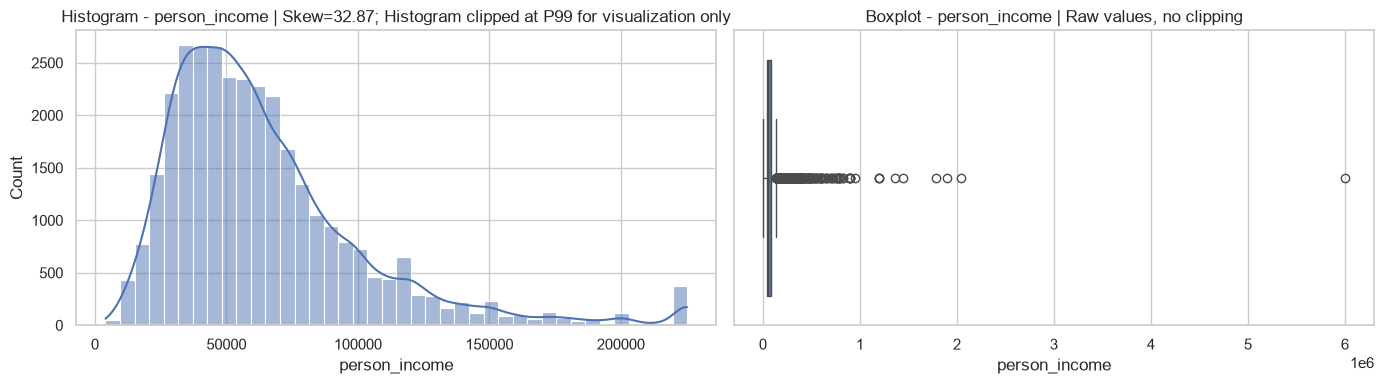

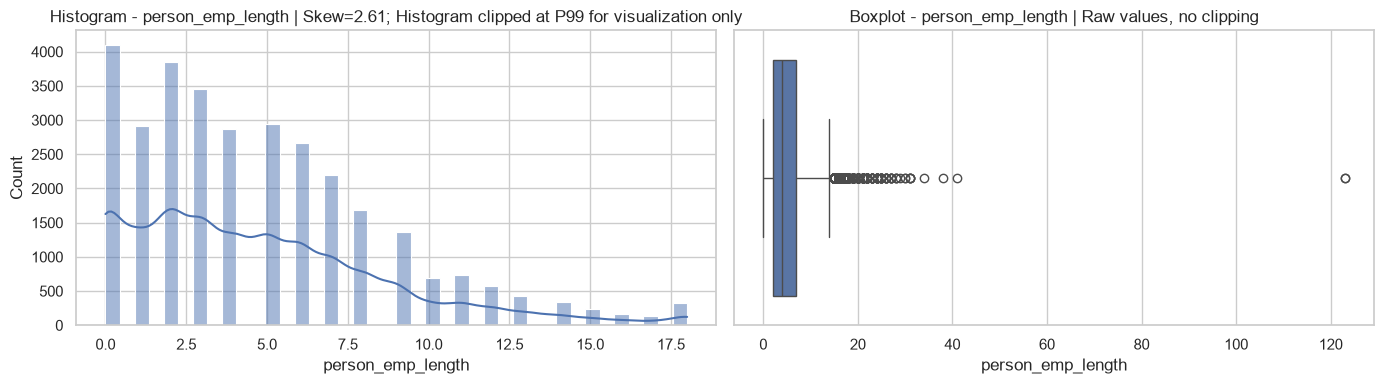

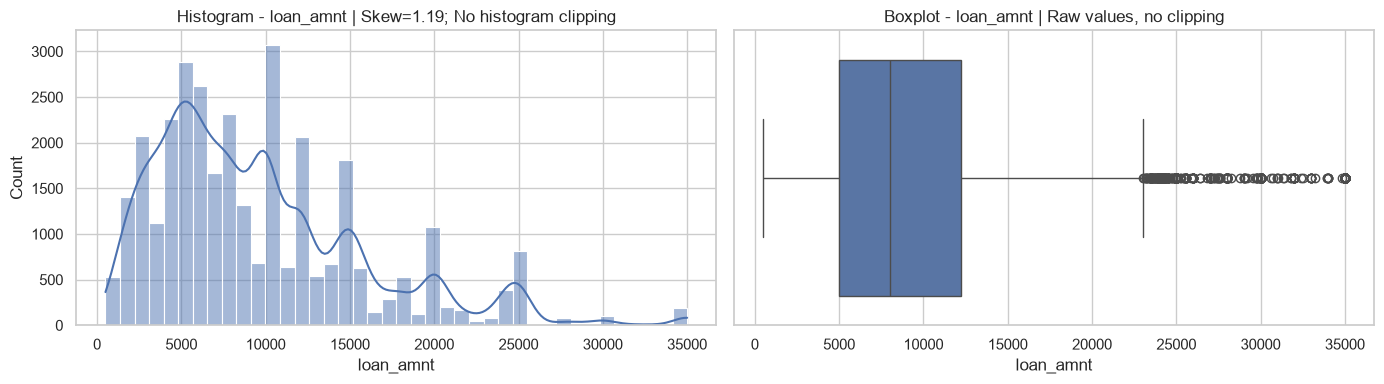

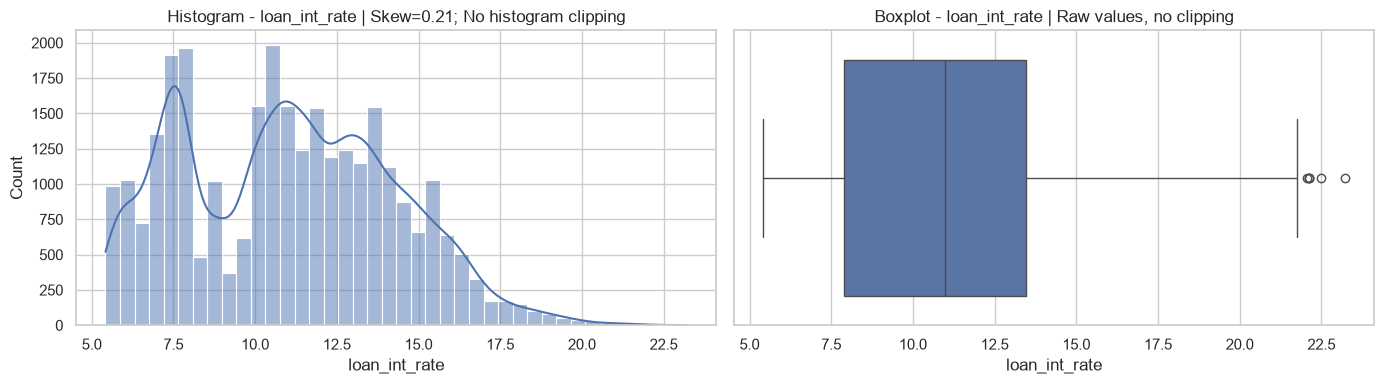

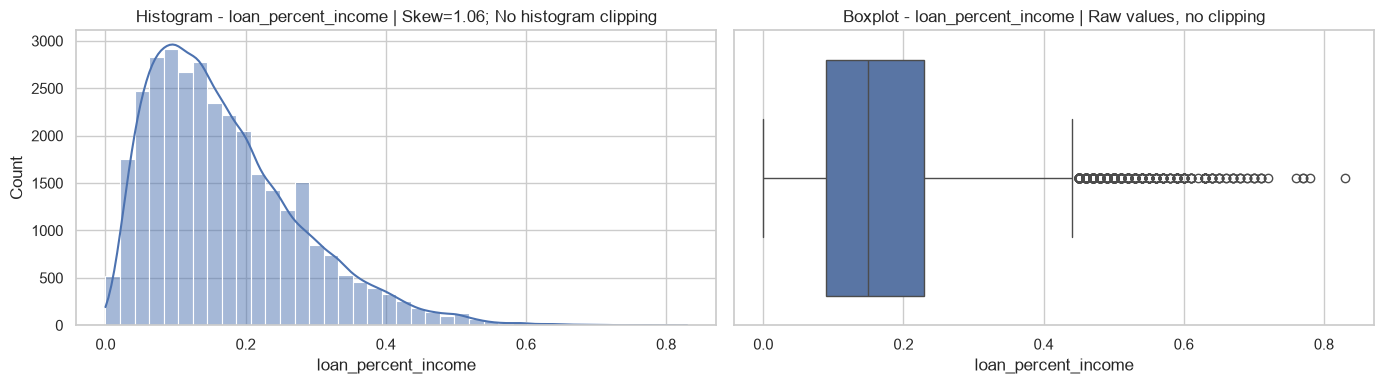

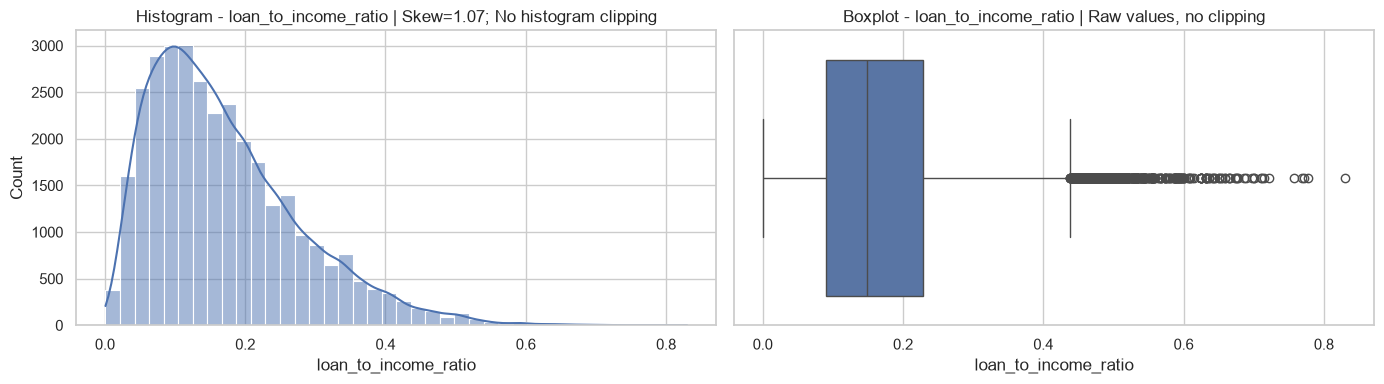

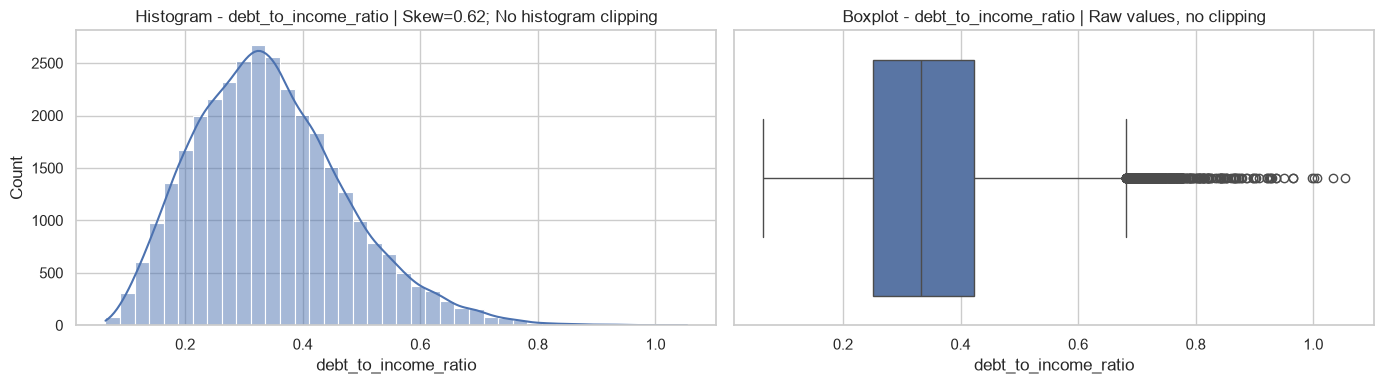

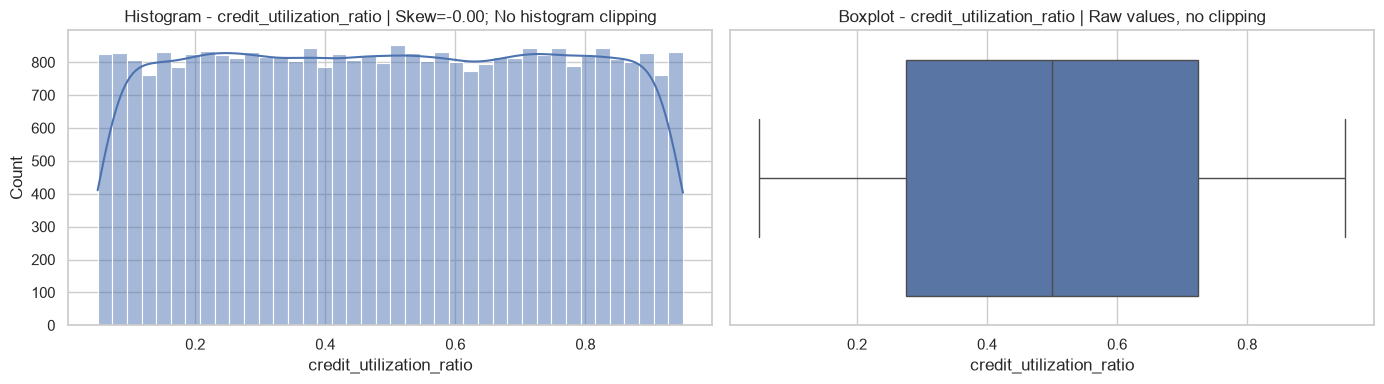

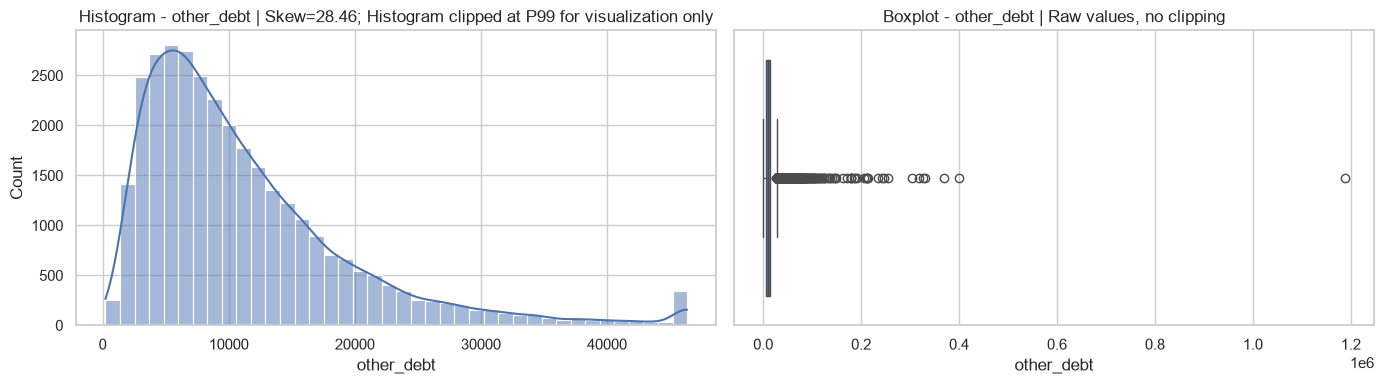


--- Numeric distribution notes ---


,column,status,skewness,p99,max,histogram_clipped_for_visualization,note
0,person_age,plotted,2.58,50.0000,144.0000,True,strong right/left skew; use median/quantiles and consider robust preprocessing later; no extreme max-vs-P99 gap by current heuristic.
1,person_income,plotted,32.87,"225,200.0000","6,000,000.0000",True,strong right/left skew; use median/quantiles and consider robust preprocessing later; max is far above P99; review outlier/business rule.
2,person_emp_length,plotted,2.61,18.0000,123.0000,True,strong right/left skew; use median/quantiles and consider robust preprocessing later; max is far above P99; review outlier/business rule.
3,loan_amnt,plotted,1.19,"29,800.0000","35,000.0000",False,moderate skew; compare mean vs median; no extreme max-vs-P99 gap by current heuristic.
4,loan_int_rate,plotted,0.21,18.6200,23.2200,False,roughly symmetric or mild skew; no extreme max-vs-P99 gap by current heuristic.
5,loan_percent_income,plotted,1.06,0.5000,0.8300,False,moderate skew; compare mean vs median; no extreme max-vs-P99 gap by current heuristic.
6,loan_to_income_ratio,plotted,1.07,0.5000,0.8300,False,moderate skew; compare mean vs median; no extreme max-vs-P99 gap by current heuristic.
7,debt_to_income_ratio,plotted,0.62,0.7020,1.0539,False,roughly symmetric or mild skew; no extreme max-vs-P99 gap by current heuristic.
8,credit_utilization_ratio,plotted,-0.00,0.9413,0.9500,False,roughly symmetric or mild skew; no extreme max-vs-P99 gap by current heuristic.
9,other_debt,plotted,28.46,"46,354.6458","1,187,998.9145",True,strong right/left skew; use median/quantiles and consider robust preprocessing later; max is far above P99; review outlier/business rule.



Numeric distribution note:
Plotted 10 numeric variables. Histograms may be clipped at P99 for visualization only; df_raw is unchanged.


In [8]:
# 3.2 - Visualize numeric distributions

# ============================================================
# 1. Chọn numeric variables quan trọng để visualize
# ============================================================

if "numeric_feature_cols" not in globals():
    raise NameError("Chưa có numeric_feature_cols. Hãy chạy cell 2.1 trước.")

numeric_plot_priority = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "other_debt",
]

numeric_plot_cols = [
    col for col in numeric_plot_priority
    if col in numeric_feature_cols and col in df_raw.columns
]

# Nếu danh sách ưu tiên không đủ, bổ sung vài cột bị flag review từ cell 3.1.
if "numeric_review_cols" in globals():
    for col in numeric_review_cols:
        if col in numeric_feature_cols and col not in numeric_plot_cols:
            numeric_plot_cols.append(col)
        if len(numeric_plot_cols) >= 10:
            break

print("=" * 90)
print("NUMERIC DISTRIBUTION PLOTS")
print("=" * 90)
print(f"Numeric plot columns ({len(numeric_plot_cols)}): {numeric_plot_cols}")

# ============================================================
# 2. Helper plot: histogram + boxplot, clip chỉ cho visualization
# ============================================================

def plot_numeric_distribution(column: str, clip_quantile: float = 0.99) -> dict:
    series = df_raw[column].dropna()

    if series.empty:
        return {
            "column": column,
            "status": "skipped_empty",
            "skewness": np.nan,
            "p99": np.nan,
            "max": np.nan,
            "note": "Không có non-missing values để plot.",
        }

    skewness = float(series.skew())
    p99 = float(series.quantile(clip_quantile))
    max_value = float(series.max())
    should_clip_for_hist = pd.notna(skewness) and abs(skewness) >= 2 and p99 < max_value

    plot_series = series.clip(upper=p99) if should_clip_for_hist else series
    clipping_note = f"Histogram clipped at P{int(clip_quantile * 100)} for visualization only" if should_clip_for_hist else "No histogram clipping"

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(plot_series, bins=40, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram - {column} | Skew={skewness:.2f}; {clipping_note}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")

    sns.boxplot(x=series, ax=axes[1])
    axes[1].set_title(f"Boxplot - {column} | Raw values, no clipping")
    axes[1].set_xlabel(column)

    plt.tight_layout()
    plt.show()

    if abs(skewness) >= 2:
        shape_note = "strong right/left skew; use median/quantiles and consider robust preprocessing later"
    elif abs(skewness) >= 1:
        shape_note = "moderate skew; compare mean vs median"
    else:
        shape_note = "roughly symmetric or mild skew"

    if max_value > p99 and p99 != 0 and abs(max_value / p99) >= 5:
        outlier_note = "max is far above P99; review outlier/business rule"
    else:
        outlier_note = "no extreme max-vs-P99 gap by current heuristic"

    return {
        "column": column,
        "status": "plotted",
        "skewness": skewness,
        "p99": p99,
        "max": max_value,
        "histogram_clipped_for_visualization": should_clip_for_hist,
        "note": f"{shape_note}; {outlier_note}.",
    }

# ============================================================
# 3. Plot và lưu notes
# ============================================================

numeric_distribution_records = []

for column in numeric_plot_cols:
    numeric_distribution_records.append(plot_numeric_distribution(column))

numeric_distribution_notes = pd.DataFrame(numeric_distribution_records)

print()
print("--- Numeric distribution notes ---")
if numeric_distribution_notes.empty:
    print("Không có numeric columns để plot.")
else:
    display(
        numeric_distribution_notes.style.format({
            "skewness": "{:.2f}",
            "p99": "{:,.4f}",
            "max": "{:,.4f}",
        })
    )

numeric_distribution_note = (
    f"Plotted {len(numeric_distribution_records)} numeric variables. "
    "Histograms may be clipped at P99 for visualization only; df_raw is unchanged."
)

print()
print("Numeric distribution note:")
print(numeric_distribution_note)


NUMERIC FEATURES BY TARGET
Target numeric columns (11): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'loan_to_income_ratio', 'debt_to_income_ratio', 'credit_utilization_ratio', 'past_delinquencies', 'other_debt']



--- Numeric target summary ---


,column,loan_status,count,missing,mean,median,std,min,p25,p75,max
0,person_age,0,25473,0,27.8071,26.0000,6.3697,20.0000,23.0000,30.0000,144.0000
1,person_age,1,7108,0,27.4747,26.0000,6.2636,20.0000,23.0000,30.0000,70.0000
2,person_income,0,25473,0,"70,804.3616","60,000.0000","66,568.8026","7,000.0000","42,000.0000","84,000.0000","6,000,000.0000"
3,person_income,1,7108,0,"49,125.6522","41,498.0000","36,907.3765","4,000.0000","30,000.0000","59,497.7500","703,800.0000"
4,person_emp_length,0,24860,613,4.9687,4.0000,4.1290,0.0000,2.0000,7.0000,123.0000
5,person_emp_length,1,6826,282,4.1376,3.0000,4.1270,0.0000,1.0000,6.0000,123.0000
6,loan_amnt,0,25473,0,"9,237.4642","8,000.0000","6,026.3755",500.0000,"5,000.0000","12,000.0000","35,000.0000"
7,loan_amnt,1,7108,0,"10,850.5030","9,600.0000","7,143.3453",900.0000,"5,000.0000","15,000.0000","35,000.0000"
8,loan_int_rate,0,23001,2472,10.4360,10.5900,2.9822,5.4200,7.6800,12.6900,22.0600
9,loan_int_rate,1,6464,644,13.0602,13.4900,3.2932,5.4200,10.7400,15.5800,23.2200



--- Numeric target driver summary ---


,column,non_default_count,default_count,non_default_median,default_median,median_diff_default_minus_non_default,median_lift,standardized_median_diff,non_default_mean,default_mean,mean_diff_default_minus_non_default,abs_standardized_median_diff
0,loan_percent_income,25473,7108,0.1300,0.2400,0.1100,+84.62%,+1.03,0.1488,0.2469,0.0981,1.03
1,loan_to_income_ratio,25473,7108,0.1333,0.2392,0.1059,+79.43%,+0.99,0.1487,0.2487,0.1000,0.99
2,loan_int_rate,23001,6464,10.5900,13.4900,2.9000,+27.38%,+0.89,10.4360,13.0602,2.6242,0.89
3,debt_to_income_ratio,25473,7108,0.3176,0.4179,0.1003,+31.58%,+0.78,0.3232,0.4240,0.1007,0.78
4,person_income,25473,7108,"60,000.0000","41,498.0000","-18,502.0000",-30.84%,-0.30,"70,804.3616","49,125.6522","-21,678.7093",0.30
5,loan_amnt,25473,7108,"8,000.0000","9,600.0000","1,600.0000",+20.00%,+0.25,"9,237.4642","10,850.5030","1,613.0388",0.25
6,person_emp_length,24860,6826,4.0000,3.0000,-1.0000,-25.00%,-0.24,4.9687,4.1376,-0.8312,0.24
7,other_debt,25473,7108,"9,727.9858","6,692.3459","-3,035.6399",-31.21%,-0.23,"12,384.3356","8,642.3067","-3,742.0289",0.23
8,credit_utilization_ratio,25473,7108,0.4994,0.5042,0.0049,+0.98%,+0.02,0.4989,0.5035,0.0046,0.02
9,person_age,25473,7108,26.0000,26.0000,0.0000,+0.00%,+0.00,27.8071,27.4747,-0.3325,0.00


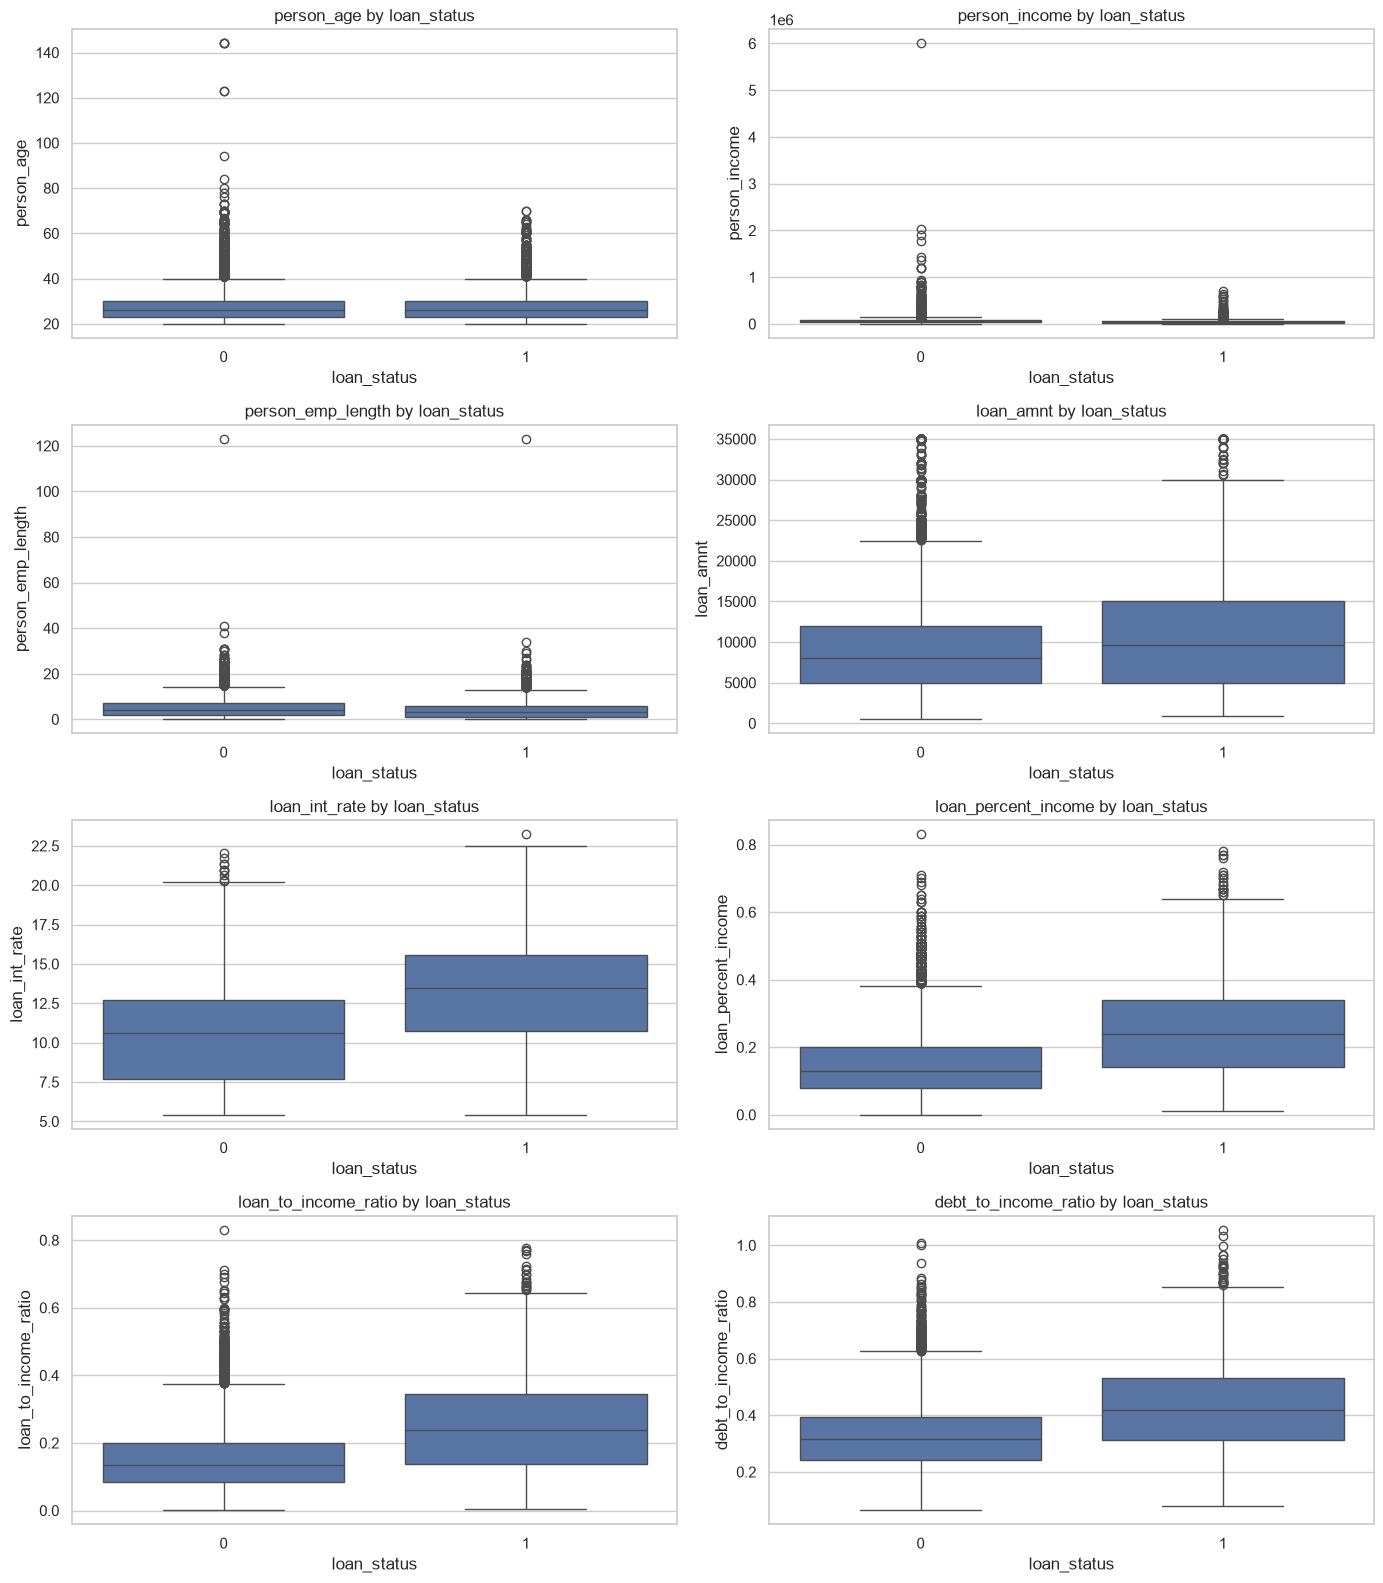


Top numeric target drivers:
['loan_percent_income', 'loan_to_income_ratio', 'loan_int_rate', 'debt_to_income_ratio', 'person_income']

Numeric target note:
Top numeric target drivers by absolute standardized median difference: loan_percent_income, loan_to_income_ratio, loan_int_rate, debt_to_income_ratio, person_income. Interpret these as EDA signals only; confirm with validation/modeling later.


In [9]:
# 3.3 - Numeric features theo target

# ============================================================
# 1. Kiểm tra input và chọn numeric variables để so sánh theo target
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy target column: {TARGET_COL}")

if "numeric_feature_cols" not in globals():
    raise NameError("Chưa có numeric_feature_cols. Hãy chạy cell 2.1 trước.")

expected_target_values = {0, 1}
observed_target_values = set(df_raw[TARGET_COL].dropna().unique().tolist())
if not observed_target_values.issubset(expected_target_values):
    print(f"WARNING - Target có giá trị ngoài 0/1: {sorted(observed_target_values - expected_target_values)}")

target_numeric_priority = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "past_delinquencies",
    "other_debt",
]

target_numeric_cols = [
    col for col in target_numeric_priority
    if col in numeric_feature_cols and col in df_raw.columns
]

if not target_numeric_cols:
    target_numeric_cols = numeric_feature_cols.copy()

print("=" * 90)
print("NUMERIC FEATURES BY TARGET")
print("=" * 90)
print(f"Target numeric columns ({len(target_numeric_cols)}): {target_numeric_cols}")

# ============================================================
# 2. Tạo bảng so sánh theo target
# ============================================================

numeric_target_summary_records = []

for column in target_numeric_cols:
    grouped = df_raw.groupby(TARGET_COL, dropna=False)[column]

    summary = grouped.agg(
        count="count",
        missing=lambda s: int(s.isna().sum()),
        mean="mean",
        median="median",
        std="std",
        min="min",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        max="max",
    ).reset_index()

    summary["column"] = column
    numeric_target_summary_records.append(summary)

numeric_target_summary = pd.concat(numeric_target_summary_records, ignore_index=True)
numeric_target_summary = numeric_target_summary[
    ["column", TARGET_COL, "count", "missing", "mean", "median", "std", "min", "p25", "p75", "max"]
]

# ============================================================
# 3. Tính chênh lệch giữa default và non-default
# ============================================================

driver_records = []

for column in target_numeric_cols:
    non_default = df_raw.loc[df_raw[TARGET_COL] == 0, column].dropna()
    default = df_raw.loc[df_raw[TARGET_COL] == 1, column].dropna()

    if non_default.empty or default.empty:
        continue

    non_default_median = float(non_default.median())
    default_median = float(default.median())
    non_default_mean = float(non_default.mean())
    default_mean = float(default.mean())

    pooled_std = float(df_raw[column].std(skipna=True))
    standardized_median_diff = (
        (default_median - non_default_median) / pooled_std
        if pooled_std and pd.notna(pooled_std)
        else np.nan
    )

    if non_default_median != 0:
        median_lift = (default_median - non_default_median) / abs(non_default_median)
    else:
        median_lift = np.nan

    driver_records.append({
        "column": column,
        "non_default_count": int(non_default.shape[0]),
        "default_count": int(default.shape[0]),
        "non_default_median": non_default_median,
        "default_median": default_median,
        "median_diff_default_minus_non_default": default_median - non_default_median,
        "median_lift": median_lift,
        "standardized_median_diff": standardized_median_diff,
        "non_default_mean": non_default_mean,
        "default_mean": default_mean,
        "mean_diff_default_minus_non_default": default_mean - non_default_mean,
    })

numeric_target_driver_summary = pd.DataFrame(driver_records)

if not numeric_target_driver_summary.empty:
    numeric_target_driver_summary["abs_standardized_median_diff"] = numeric_target_driver_summary[
        "standardized_median_diff"
    ].abs()
    numeric_target_driver_summary = (
        numeric_target_driver_summary
        .sort_values("abs_standardized_median_diff", ascending=False)
        .reset_index(drop=True)
    )

# ============================================================
# 4. Hiển thị bảng và boxplots
# ============================================================

formatters = {
    "mean": "{:,.4f}",
    "median": "{:,.4f}",
    "std": "{:,.4f}",
    "min": "{:,.4f}",
    "p25": "{:,.4f}",
    "p75": "{:,.4f}",
    "max": "{:,.4f}",
    "non_default_median": "{:,.4f}",
    "default_median": "{:,.4f}",
    "median_diff_default_minus_non_default": "{:,.4f}",
    "median_lift": "{:+.2%}",
    "standardized_median_diff": "{:+.2f}",
    "non_default_mean": "{:,.4f}",
    "default_mean": "{:,.4f}",
    "mean_diff_default_minus_non_default": "{:,.4f}",
    "abs_standardized_median_diff": "{:.2f}",
}

print()
print("--- Numeric target summary ---")
display(numeric_target_summary.style.format(formatters))

print()
print("--- Numeric target driver summary ---")
if numeric_target_driver_summary.empty:
    print("Không tạo được driver summary do thiếu dữ liệu ở một trong hai nhóm target.")
else:
    display(numeric_target_driver_summary.style.format(formatters))

# Plot tối đa 8 biến để notebook không quá nặng.
boxplot_cols = target_numeric_cols[:8]

n_cols = 2
n_rows = int(np.ceil(len(boxplot_cols) / n_cols)) if boxplot_cols else 0

if boxplot_cols:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, boxplot_cols):
        sns.boxplot(data=df_raw, x=TARGET_COL, y=column, ax=ax)
        ax.set_title(f"{column} by {TARGET_COL}")
        ax.set_xlabel(TARGET_COL)
        ax.set_ylabel(column)

    for ax in axes[len(boxplot_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

# ============================================================
# 5. Driver list và note cho phần tổng hợp EDA
# ============================================================

if numeric_target_driver_summary.empty:
    top_numeric_target_drivers = []
else:
    top_numeric_target_drivers = numeric_target_driver_summary["column"].head(5).tolist()

numeric_target_note = (
    "Top numeric target drivers by absolute standardized median difference: "
    + (", ".join(top_numeric_target_drivers) if top_numeric_target_drivers else "None")
    + ". Interpret these as EDA signals only; confirm with validation/modeling later."
)

print()
print("Top numeric target drivers:")
print(top_numeric_target_drivers)
print()
print("Numeric target note:")
print(numeric_target_note)


## 3.4 - Numeric Risk Trend by Bands

Phần này trả lời trực tiếp các câu hỏi business trend trong plan:
- Income tăng thì default rate có giảm không?
- Loan-to-income tăng thì default rate có tăng không?
- Debt-to-income tăng thì default rate có tăng không?

NUMERIC RISK TREND BY BANDS
Overall default rate: 21.82%

--- Default rate by band: person_income ---


,band,count,default_count,default_rate,feature,row_share,default_rate_gap
0,<25K,2469,1289,52.21%,person_income,7.58%,+30.39%
1,25K-50K,11613,3214,27.68%,person_income,35.64%,+5.86%
2,50K-75K,9622,1691,17.57%,person_income,29.53%,-4.24%
3,75K-100K,4670,513,10.99%,person_income,14.33%,-10.83%
4,>=100K,4207,401,9.53%,person_income,12.91%,-12.28%


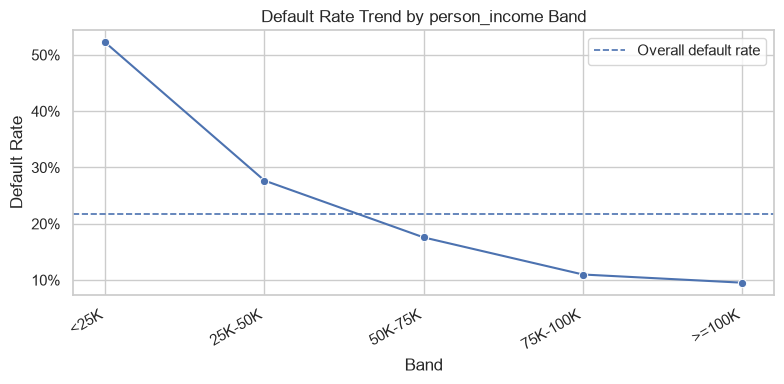


--- Default rate by band: loan_to_income_ratio ---


,band,count,default_count,default_rate,feature,row_share,default_rate_gap
0,<10%,9886,1108,11.21%,loan_to_income_ratio,30.34%,-10.61%
1,10%-20%,12321,1823,14.80%,loan_to_income_ratio,37.82%,-7.02%
2,20%-30%,6348,1402,22.09%,loan_to_income_ratio,19.48%,+0.27%
3,30%-40%,2835,1885,66.49%,loan_to_income_ratio,8.70%,+44.67%
4,>=40%,1191,890,74.73%,loan_to_income_ratio,3.66%,+52.91%


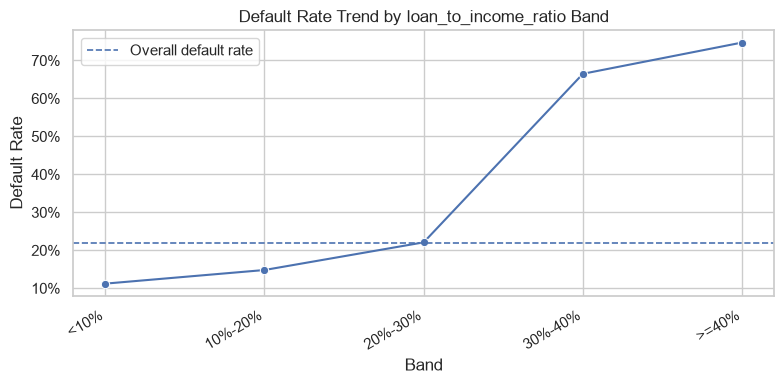


--- Default rate by band: debt_to_income_ratio ---


,band,count,default_count,default_rate,feature,row_share,default_rate_gap
0,<10%,186,24,12.90%,debt_to_income_ratio,0.57%,-8.91%
1,10%-20%,3923,431,10.99%,debt_to_income_ratio,12.04%,-10.83%
2,20%-30%,8649,1128,13.04%,debt_to_income_ratio,26.55%,-8.77%
3,30%-40%,9838,1644,16.71%,debt_to_income_ratio,30.20%,-5.11%
4,>=40%,9985,3881,38.87%,debt_to_income_ratio,30.65%,+17.05%


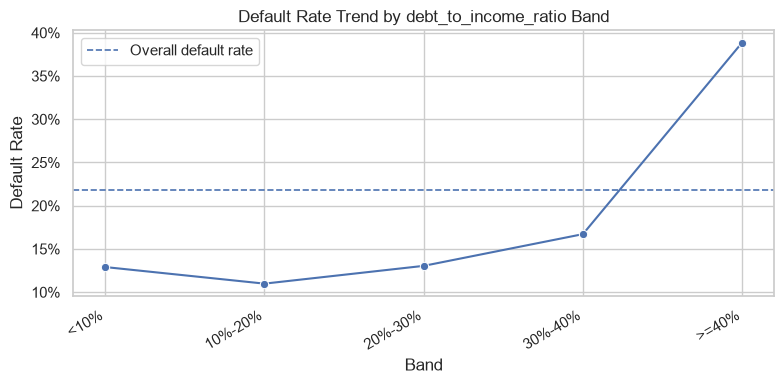


--- Numeric risk band trend summary ---


,feature,expected_direction,first_band,first_band_default_rate,last_band,last_band_default_rate,end_to_end_default_rate_delta
0,person_income,default_rate_down_when_feature_up,<25K,52.21%,>=100K,9.53%,-42.68%
1,loan_to_income_ratio,default_rate_up_when_feature_up,<10%,11.21%,>=40%,74.73%,+63.52%
2,debt_to_income_ratio,default_rate_up_when_feature_up,<10%,12.90%,>=40%,38.87%,+25.97%



Risk band trend note:
Band analysis adds a business-readable trend view for income, LTI and DTI. These trends are descriptive EDA evidence; feature selection still needs validation.


In [10]:
# 3.4 - Numeric Risk Trend by Bands

# ============================================================
# 1. Kiểm tra input
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy target column: {TARGET_COL}")

valid_target_mask = df_raw[TARGET_COL].isin([0, 1])
overall_default_rate = float(df_raw.loc[valid_target_mask, TARGET_COL].mean())

band_specs = [
    {
        "feature": "person_income",
        "band_col": "income_band",
        "labels": ["<25K", "25K-50K", "50K-75K", "75K-100K", ">=100K"],
        "bins": [-np.inf, 25_000, 50_000, 75_000, 100_000, np.inf],
        "expected_direction": "default_rate_down_when_feature_up",
    },
    {
        "feature": "loan_to_income_ratio",
        "band_col": "loan_to_income_band",
        "labels": ["<10%", "10%-20%", "20%-30%", "30%-40%", ">=40%"],
        "bins": [-np.inf, 0.10, 0.20, 0.30, 0.40, np.inf],
        "expected_direction": "default_rate_up_when_feature_up",
    },
    {
        "feature": "debt_to_income_ratio",
        "band_col": "debt_to_income_band",
        "labels": ["<10%", "10%-20%", "20%-30%", "30%-40%", ">=40%"],
        "bins": [-np.inf, 0.10, 0.20, 0.30, 0.40, np.inf],
        "expected_direction": "default_rate_up_when_feature_up",
    },
]

risk_band_tables = {}
risk_band_records = []

# ============================================================
# 2. Tính default rate theo band
# ============================================================

for spec in band_specs:
    feature = spec["feature"]

    if feature not in df_raw.columns:
        continue

    temp = df_raw.loc[
        valid_target_mask,
        [feature, TARGET_COL],
    ].copy()

    temp[spec["band_col"]] = pd.cut(
        temp[feature],
        bins=spec["bins"],
        labels=spec["labels"],
        include_lowest=True,
    )

    band_table = (
        temp
        .groupby(spec["band_col"], observed=False)[TARGET_COL]
        .agg(
            count="size",
            default_count="sum",
            default_rate="mean",
        )
        .reset_index()
        .rename(columns={spec["band_col"]: "band"})
    )

    band_table["feature"] = feature
    band_table["row_share"] = band_table["count"] / len(temp)
    band_table["default_rate_gap"] = band_table["default_rate"] - overall_default_rate

    risk_band_tables[feature] = band_table

    first_rate = band_table["default_rate"].iloc[0]
    last_rate = band_table["default_rate"].iloc[-1]
    end_to_end_delta = float(last_rate - first_rate)

    risk_band_records.append({
        "feature": feature,
        "expected_direction": spec["expected_direction"],
        "first_band": str(band_table["band"].iloc[0]),
        "first_band_default_rate": first_rate,
        "last_band": str(band_table["band"].iloc[-1]),
        "last_band_default_rate": last_rate,
        "end_to_end_default_rate_delta": end_to_end_delta,
    })

numeric_risk_band_trend_summary = pd.DataFrame(risk_band_records)

risk_band_trend_note = (
    "Band analysis adds a business-readable trend view for income, LTI and DTI. "
    "These trends are descriptive EDA evidence; feature selection still needs validation."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("NUMERIC RISK TREND BY BANDS")
print("=" * 90)
print(f"Overall default rate: {overall_default_rate:.2%}")

for feature, table in risk_band_tables.items():
    print(f"\n--- Default rate by band: {feature} ---")
    display(
        table.style.format({
            "row_share": "{:.2%}",
            "default_rate": "{:.2%}",
            "default_rate_gap": "{:+.2%}",
        })
    )

    plt.figure(figsize=(8, 4))
    ax = sns.lineplot(
        data=table,
        x="band",
        y="default_rate",
        marker="o",
    )
    ax.axhline(
        overall_default_rate,
        linestyle="--",
        linewidth=1.2,
        label="Overall default rate",
    )
    ax.set_title(f"Default Rate Trend by {feature} Band")
    ax.set_xlabel("Band")
    ax.set_ylabel("Default Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n--- Numeric risk band trend summary ---")
display(
    numeric_risk_band_trend_summary.style.format({
        "first_band_default_rate": "{:.2%}",
        "last_band_default_rate": "{:.2%}",
        "end_to_end_default_rate_delta": "{:+.2%}",
    })
)

print("\nRisk band trend note:")
print(risk_band_trend_note)

## Section 4 - Categorical EDA

Cần xem phân phối category, số lượng nhóm hiếm, và default rate theo từng category.

Cẩn thận với nhóm có sample size nhỏ vì default rate có thể nhiễu mạnh.

In [11]:
# 4.1 - Categorical summary table

# ============================================================
# 1. Kiểm tra input
# ============================================================

if "categorical_feature_cols" not in globals():
    raise NameError(
        "Chưa có categorical_feature_cols. "
        "Hãy chạy cell 2.1 trước."
    )

if not categorical_feature_cols:
    raise ValueError(
        "categorical_feature_cols đang rỗng; "
        "không có biến categorical để EDA."
    )

missing_categorical_cols = [
    col for col in categorical_feature_cols
    if col not in df_raw.columns
]

if missing_categorical_cols:
    raise KeyError(
        "Các categorical columns không tồn tại trong df_raw: "
        f"{missing_categorical_cols}"
    )

# ============================================================
# 2. Các token cần review
# ============================================================

# Các token khá rõ là biểu diễn missing
encoded_missing_tokens = {
    "", "na", "n/a", "nan", "null",
    "none", "missing", "?"
}

# Các token chưa chắc là missing, chỉ đánh dấu để review
review_tokens = {
    "unknown", "-"
}

HIGH_CARDINALITY_THRESHOLD = 20
DOMINANT_CATEGORY_THRESHOLD = 0.95

categorical_summary_records = []

# ============================================================
# 3. Tạo summary cho từng categorical feature
# ============================================================

for column in categorical_feature_cols:
    series = df_raw[column]

    row_count = len(series)
    missing_count = int(series.isna().sum())
    missing_rate = missing_count / row_count

    unique_count = int(
        series.nunique(dropna=True)
    )

    # --------------------------------------------------------
    # Top value
    # --------------------------------------------------------

    value_counts = series.value_counts(
        dropna=False
    )

    if value_counts.empty:
        top_value = np.nan
        top_value_count = 0
        top_value_rate = np.nan
    else:
        top_value = value_counts.index[0]

        if pd.isna(top_value):
            top_value = "<Missing>"

        top_value_count = int(
            value_counts.iloc[0]
        )

        top_value_rate = (
            top_value_count / row_count
        )

    # --------------------------------------------------------
    # Chuẩn hóa tạm để phát hiện whitespace/case problems
    # Không thay đổi df_raw
    # --------------------------------------------------------

    normalized = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    normalized_unique_count = int(
        normalized.nunique(dropna=True)
    )

    normalization_collision = (
        normalized_unique_count
        < unique_count
    )

    # --------------------------------------------------------
    # Kiểm tra encoded missing tokens
    # --------------------------------------------------------

    encoded_missing_mask = (
        normalized.isin(
            encoded_missing_tokens
        )
    )

    encoded_missing_count = int(
        encoded_missing_mask.sum()
    )

    encoded_tokens_found = sorted(
        normalized.loc[
            encoded_missing_mask
        ]
        .dropna()
        .unique()
        .tolist()
    )

    # --------------------------------------------------------
    # Review tokens như "unknown", "-"
    # --------------------------------------------------------

    review_token_mask = (
        normalized.isin(review_tokens)
    )

    review_token_count = int(
        review_token_mask.sum()
    )

    review_tokens_found = sorted(
        normalized.loc[
            review_token_mask
        ]
        .dropna()
        .unique()
        .tolist()
    )

    # --------------------------------------------------------
    # Đếm rare categories
    # Rare category = nhóm chiếm < 1%
    # --------------------------------------------------------

    non_missing_counts = (
        series
        .value_counts(dropna=True)
    )

    rare_category_count = int(
        (
            non_missing_counts / row_count
            < 0.01
        ).sum()
    )

    # --------------------------------------------------------
    # Tạo review notes
    # --------------------------------------------------------

    review_notes = []

    if missing_count > 0:
        review_notes.append(
            f"missing={missing_rate:.2%}"
        )

    if unique_count > HIGH_CARDINALITY_THRESHOLD:
        review_notes.append(
            f"high_cardinality={unique_count}"
        )

    if normalization_collision:
        review_notes.append(
            "case_or_whitespace_inconsistency"
        )

    if encoded_missing_count > 0:
        review_notes.append(
            f"encoded_missing={encoded_missing_count}"
        )

    if review_token_count > 0:
        review_notes.append(
            f"review_tokens={review_token_count}"
        )

    if (
        pd.notna(top_value_rate)
        and top_value_rate
        >= DOMINANT_CATEGORY_THRESHOLD
    ):
        review_notes.append(
            f"dominant_category={top_value_rate:.2%}"
        )

    if rare_category_count > 0:
        review_notes.append(
            f"rare_categories={rare_category_count}"
        )

    categorical_summary_records.append({
        "column": column,
        "unique_count": unique_count,
        "missing_count": missing_count,
        "missing_rate": missing_rate,
        "top_value": top_value,
        "top_value_count": top_value_count,
        "top_value_rate": top_value_rate,
        "normalized_unique_count": (
            normalized_unique_count
        ),
        "encoded_missing_count": (
            encoded_missing_count
        ),
        "encoded_tokens_found": (
            encoded_tokens_found
        ),
        "review_token_count": (
            review_token_count
        ),
        "review_tokens_found": (
            review_tokens_found
        ),
        "rare_category_count": (
            rare_category_count
        ),
        "review_note": (
            " | ".join(review_notes)
            if review_notes
            else "no_major_issue"
        ),
    })

# ============================================================
# 4. Tạo summary table
# ============================================================

categorical_eda_summary = pd.DataFrame(
    categorical_summary_records
)

categorical_eda_summary = (
    categorical_eda_summary
    .sort_values(
        ["unique_count", "missing_rate"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# Các column cần review thêm
categorical_review_cols = (
    categorical_eda_summary.loc[
        categorical_eda_summary[
            "review_note"
        ] != "no_major_issue",
        "column"
    ]
    .tolist()
)

# ============================================================
# 5. Display
# ============================================================

print("=" * 90)
print("CATEGORICAL EDA SUMMARY")
print("=" * 90)

display(
    categorical_eda_summary.style.format({
        "missing_rate": "{:.2%}",
        "top_value_rate": "{:.2%}",
    })
)

print()
print(
    "Categorical columns cần review "
    "(xem xét thêm):"
)
print(categorical_review_cols)

CATEGORICAL EDA SUMMARY


,column,unique_count,missing_count,missing_rate,top_value,top_value_count,top_value_rate,normalized_unique_count,encoded_missing_count,encoded_tokens_found,review_token_count,review_tokens_found,rare_category_count,review_note
0,city,18,0,0.00%,Victoria,1852,5.68%,18,0,[],0,[],0,no_major_issue
1,state,9,0,0.00%,BC,3679,11.29%,9,0,[],0,[],0,no_major_issue
2,loan_grade,7,0,0.00%,A,10777,33.08%,7,0,[],0,[],2,rare_categories=2
3,loan_intent,6,0,0.00%,EDUCATION,6453,19.81%,6,0,[],0,[],0,no_major_issue
4,person_home_ownership,4,0,0.00%,RENT,16446,50.48%,4,0,[],0,[],1,rare_categories=1
5,marital_status,4,0,0.00%,Single,16368,50.24%,4,0,[],0,[],0,no_major_issue
6,education_level,4,0,0.00%,High School,13185,40.47%,4,0,[],0,[],0,no_major_issue
7,employment_type,4,0,0.00%,Full-time,19473,59.77%,4,0,[],0,[],0,no_major_issue
8,country,3,0,0.00%,UK,10944,33.59%,3,0,[],0,[],0,no_major_issue
9,cb_person_default_on_file,2,0,0.00%,N,26836,82.37%,2,0,[],0,[],0,no_major_issue



Categorical columns cần review (xem xét thêm):
['loan_grade', 'person_home_ownership']


CATEGORICAL DISTRIBUTION PLOTS
Categorical plot columns (8):
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'employment_type', 'education_level', 'marital_status', 'gender']


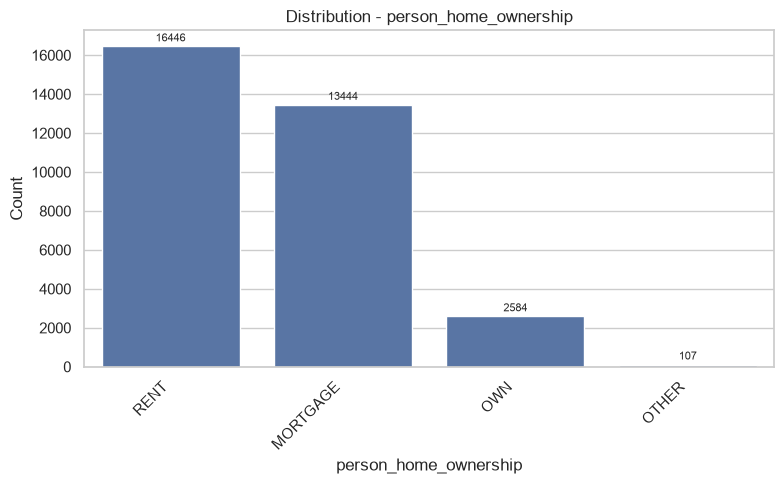

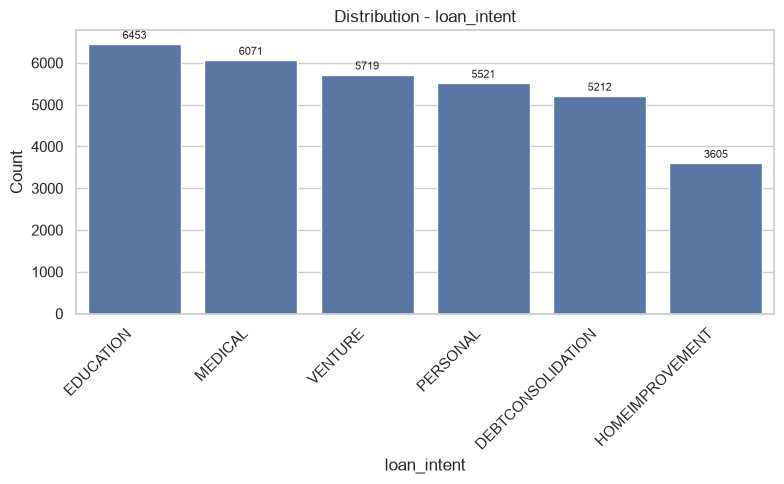

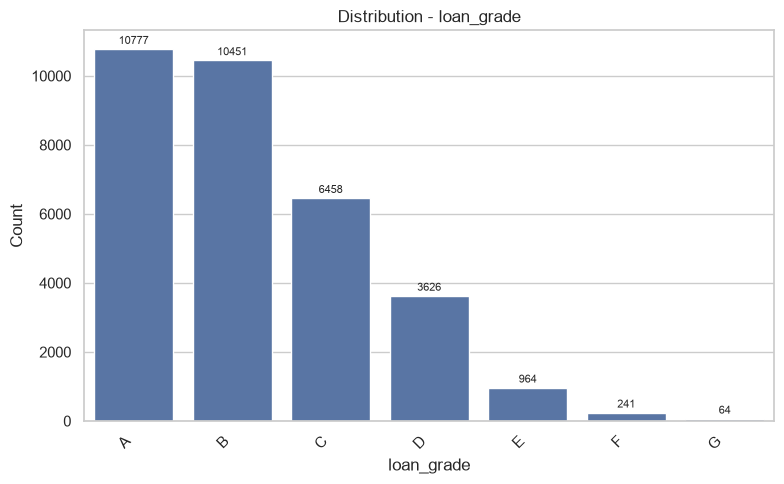

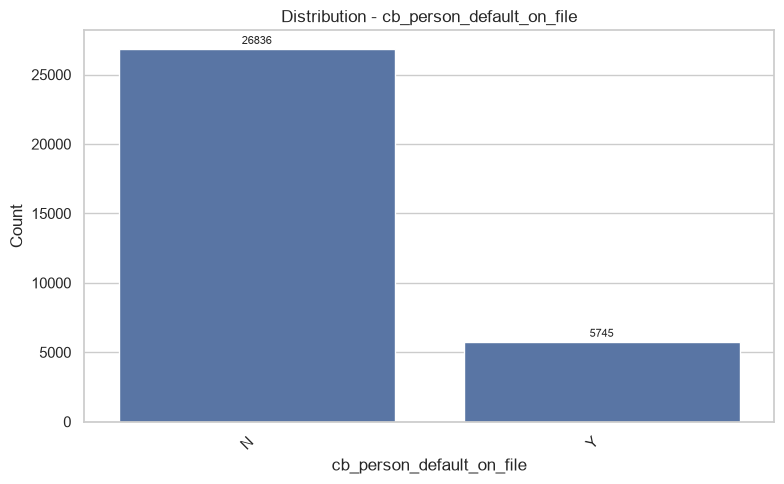

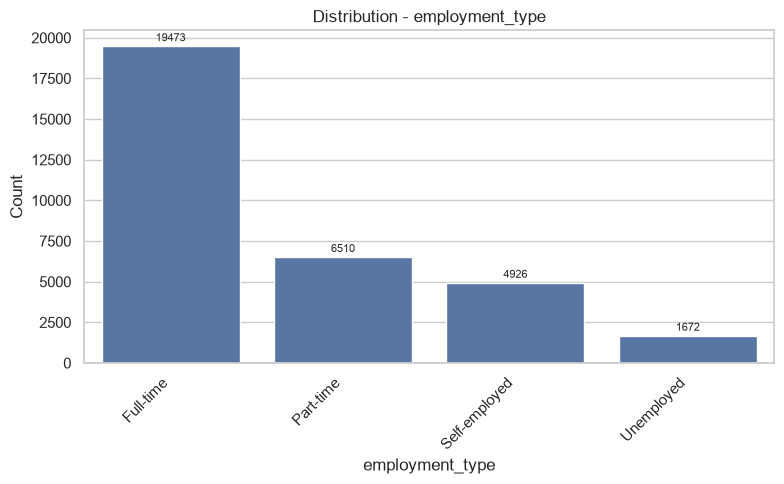

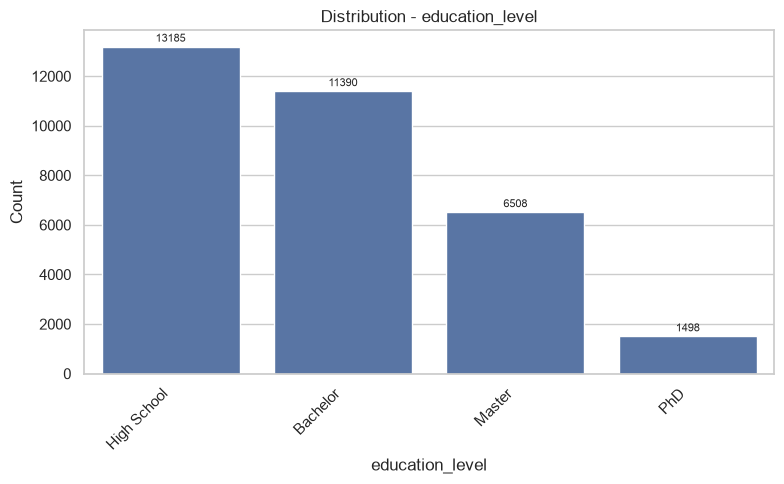

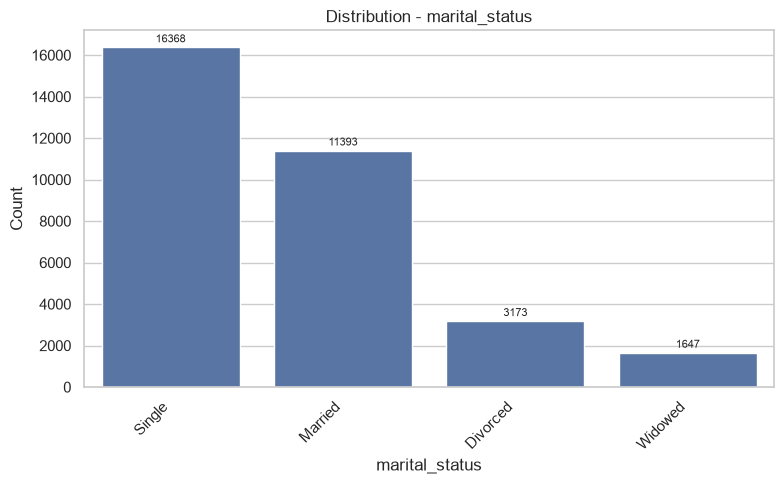

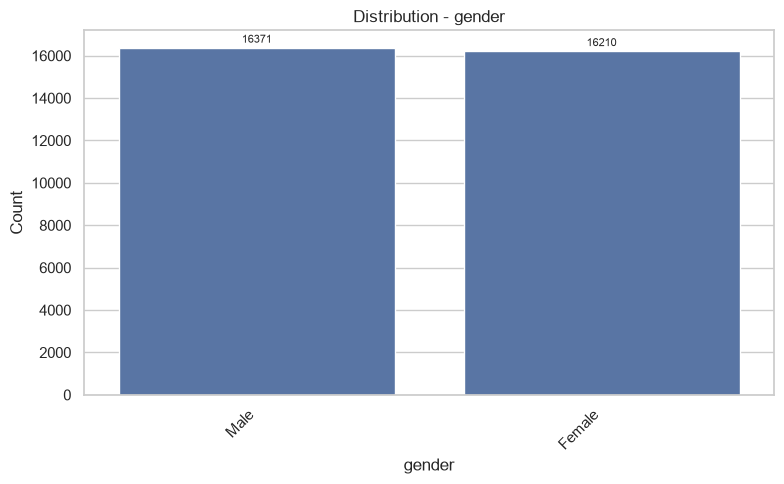


--- Categorical distribution notes (ghi chú phân phối) ---


,column,unique_count,largest_group,largest_group_rate,rare_group_count,grouped_other_for_plot,note
0,person_home_ownership,4,RENT,50.48%,1,False,4 categories | largest_group=RENT (50.48%) | rare_groups(<1%)=1
1,loan_intent,6,EDUCATION,19.81%,0,False,6 categories | largest_group=EDUCATION (19.81%)
2,loan_grade,7,A,33.08%,2,False,7 categories | largest_group=A (33.08%) | rare_groups(<1%)=2
3,cb_person_default_on_file,2,N,82.37%,0,False,2 categories | largest_group=N (82.37%)
4,employment_type,4,Full-time,59.77%,0,False,4 categories | largest_group=Full-time (59.77%)
5,education_level,4,High School,40.47%,0,False,4 categories | largest_group=High School (40.47%)
6,marital_status,4,Single,50.24%,0,False,4 categories | largest_group=Single (50.24%)
7,gender,2,Male,50.25%,0,False,2 categories | largest_group=Male (50.25%)


In [12]:
# 4.2 - Visualize categorical distributions

# ============================================================
# 1. Kiểm tra input
# ============================================================

if "categorical_feature_cols" not in globals():
    raise NameError(
        "Chưa có categorical_feature_cols. "
        "Hãy chạy cell 2.1 trước."
    )

# ============================================================
# 2. Chọn categorical variables quan trọng
# ============================================================

categorical_plot_priority = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
    "employment_type",
    "education_level",
    "marital_status",
    "gender",
]

categorical_plot_cols = [
    col for col in categorical_plot_priority
    if col in categorical_feature_cols
    and col in df_raw.columns
]

# Nếu chưa đủ biến thì bổ sung từ categorical_review_cols
if "categorical_review_cols" in globals():
    for col in categorical_review_cols:
        if (
            col in categorical_feature_cols
            and col not in categorical_plot_cols
        ):
            categorical_plot_cols.append(col)

        if len(categorical_plot_cols) >= 8:
            break

# Fallback nếu danh sách vẫn rỗng
if not categorical_plot_cols:
    categorical_plot_cols = (
        categorical_feature_cols[:8]
    )

print("=" * 90)
print("CATEGORICAL DISTRIBUTION PLOTS")
print("=" * 90)

print(
    f"Categorical plot columns "
    f"({len(categorical_plot_cols)}):"
)

print(categorical_plot_cols)

# ============================================================
# 3. Helper function để vẽ countplot
# ============================================================

MAX_DISPLAY_CATEGORIES = 15

def plot_categorical_distribution(
    column,
    max_categories=MAX_DISPLAY_CATEGORIES
):
    series = (
        df_raw[column]
        .astype("string")
        .fillna("<Missing>")
    )

    value_counts = (
        series
        .value_counts(dropna=False)
    )

    original_unique_count = (
        len(value_counts)
    )

    # --------------------------------------------------------
    # Nếu quá nhiều category:
    # chỉ giữ top N-1 và gom phần còn lại thành "Other"
    # --------------------------------------------------------

    if original_unique_count > max_categories:
        top_categories = (
            value_counts
            .head(max_categories - 1)
            .index
        )

        plot_series = series.where(
            series.isin(top_categories),
            "Other"
        )

        grouped_other = True

    else:
        plot_series = series.copy()
        grouped_other = False

    order = (
        plot_series
        .value_counts()
        .index
        .tolist()
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(
            max(8, len(order) * 0.75),
            5
        )
    )

    ax = sns.countplot(
        x=plot_series,
        order=order
    )

    ax.set_title(
        f"Distribution - {column}"
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Count")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%d",
            padding=2,
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Tạo notes
    # --------------------------------------------------------

    top_value = value_counts.index[0]
    top_count = int(
        value_counts.iloc[0]
    )

    top_rate = (
        top_count / len(series)
    )

    rare_groups = int(
        (
            value_counts / len(series)
            < 0.01
        ).sum()
    )

    notes = []

    notes.append(
        f"{original_unique_count} categories"
    )

    notes.append(
        f"largest_group={top_value} "
        f"({top_rate:.2%})"
    )

    if rare_groups > 0:
        notes.append(
            f"rare_groups(<1%)={rare_groups}"
        )

    if grouped_other:
        notes.append(
            "high cardinality; smaller groups "
            "combined into Other for visualization only"
        )

    return {
        "column": column,
        "unique_count": original_unique_count,
        "largest_group": top_value,
        "largest_group_rate": top_rate,
        "rare_group_count": rare_groups,
        "grouped_other_for_plot": grouped_other,
        "note": " | ".join(notes),
    }

# ============================================================
# 4. Vẽ và lưu notes
# ============================================================

categorical_distribution_records = []

for column in categorical_plot_cols:
    result = plot_categorical_distribution(
        column
    )

    categorical_distribution_records.append(
        result
    )

categorical_distribution_notes = (
    pd.DataFrame(
        categorical_distribution_records
    )
)

# ============================================================
# 5. Display notes
# ============================================================

print()
print(
    "--- Categorical distribution notes "
    "(ghi chú phân phối) ---"
)

display(
    categorical_distribution_notes.style.format({
        "largest_group_rate": "{:.2%}",
    })
)

DEFAULT RATE BY CATEGORICAL VARIABLES
Overall default rate (tỷ lệ vỡ nợ toàn bộ): 21.82%



person_home_ownership - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,RENT,16446,5192,31.57%,50.48%,+9.75%,9.75%,False
1,OTHER,107,33,30.84%,0.33%,+9.02%,9.02%,True
2,MORTGAGE,13444,1690,12.57%,41.26%,-9.25%,9.25%,False
3,OWN,2584,193,7.47%,7.93%,-14.35%,14.35%,False


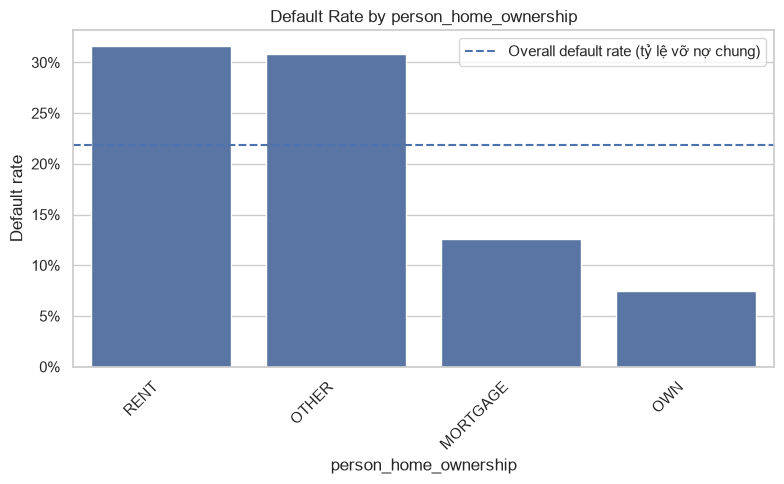


loan_intent - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,DEBTCONSOLIDATION,5212,1490,28.59%,16.00%,+6.77%,6.77%,False
1,MEDICAL,6071,1621,26.70%,18.63%,+4.88%,4.88%,False
2,HOMEIMPROVEMENT,3605,941,26.10%,11.06%,+4.29%,4.29%,False
3,PERSONAL,5521,1098,19.89%,16.95%,-1.93%,1.93%,False
4,EDUCATION,6453,1111,17.22%,19.81%,-4.60%,4.60%,False
5,VENTURE,5719,847,14.81%,17.55%,-7.01%,7.01%,False


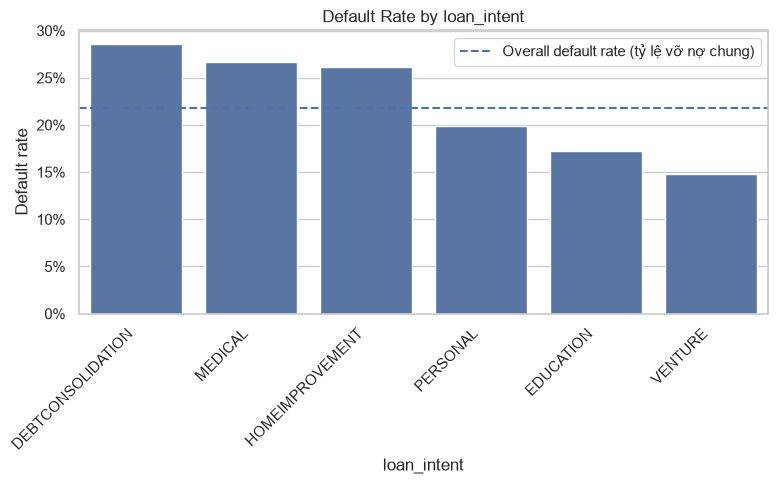


loan_grade - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,G,64,63,98.44%,0.20%,+76.62%,76.62%,True
1,F,241,170,70.54%,0.74%,+48.72%,48.72%,False
2,E,964,621,64.42%,2.96%,+42.60%,42.60%,False
3,D,3626,2141,59.05%,11.13%,+37.23%,37.23%,False
4,C,6458,1339,20.73%,19.82%,-1.08%,1.08%,False
5,B,10451,1701,16.28%,32.08%,-5.54%,5.54%,False
6,A,10777,1073,9.96%,33.08%,-11.86%,11.86%,False


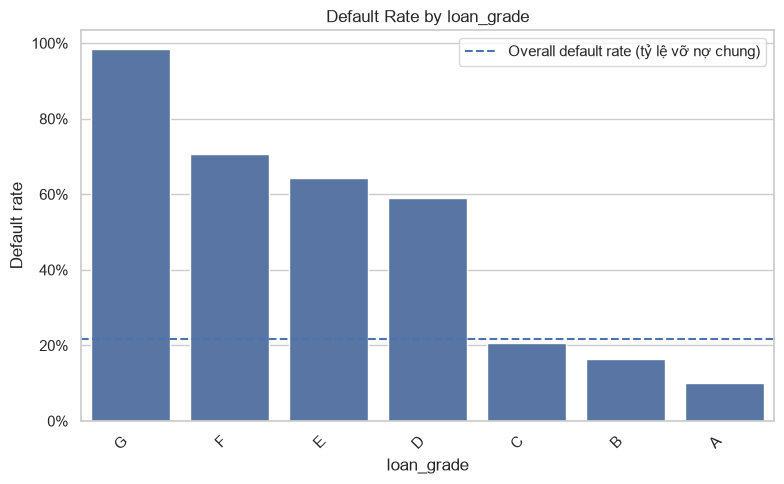


cb_person_default_on_file - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Y,5745,2172,37.81%,17.63%,+15.99%,15.99%,False
1,N,26836,4936,18.39%,82.37%,-3.42%,3.42%,False


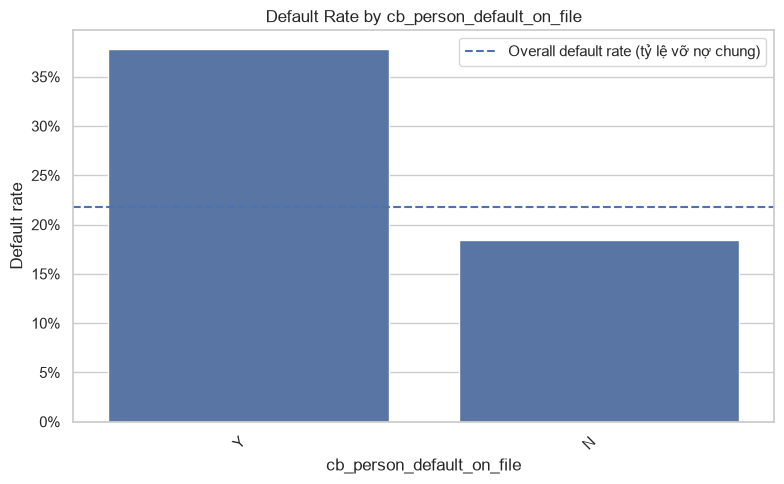


employment_type - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Unemployed,1672,379,22.67%,5.13%,+0.85%,0.85%,False
1,Self-employed,4926,1108,22.49%,15.12%,+0.68%,0.68%,False
2,Part-time,6510,1421,21.83%,19.98%,+0.01%,0.01%,False
3,Full-time,19473,4200,21.57%,59.77%,-0.25%,0.25%,False


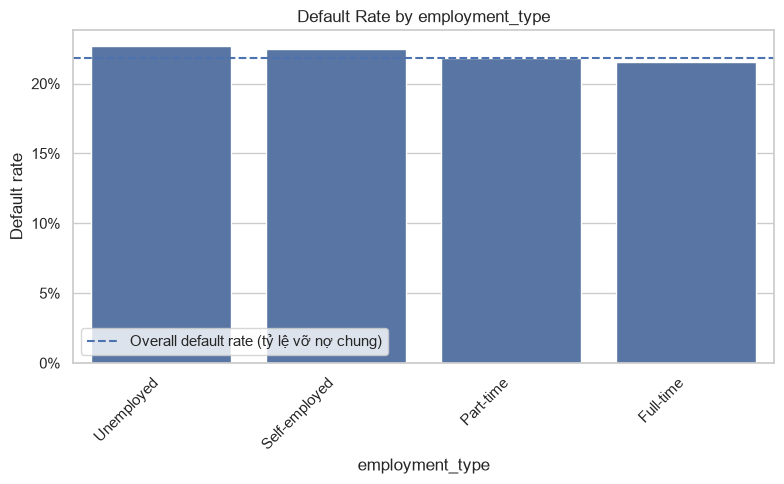


education_level - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Master,6508,1443,22.17%,19.97%,+0.36%,0.36%,False
1,High School,13185,2909,22.06%,40.47%,+0.25%,0.25%,False
2,Bachelor,11390,2439,21.41%,34.96%,-0.40%,0.40%,False
3,PhD,1498,317,21.16%,4.60%,-0.65%,0.65%,False


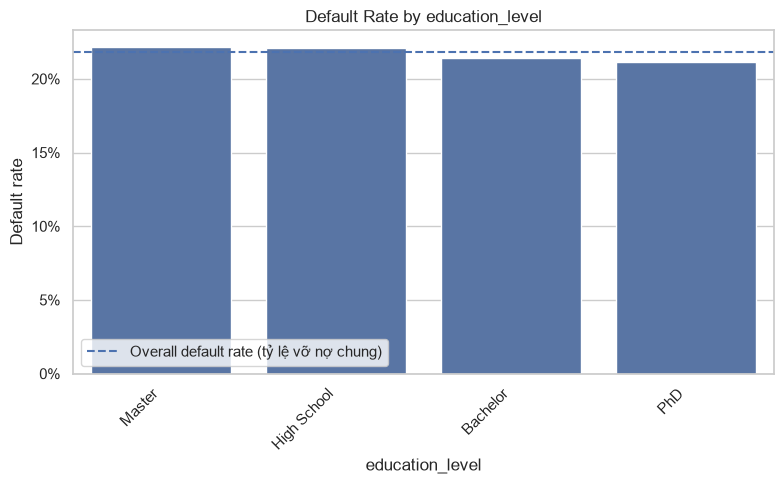


marital_status - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Married,11393,2502,21.96%,34.97%,+0.14%,0.14%,False
1,Divorced,3173,692,21.81%,9.74%,-0.01%,0.01%,False
2,Single,16368,3562,21.76%,50.24%,-0.05%,0.05%,False
3,Widowed,1647,352,21.37%,5.06%,-0.44%,0.44%,False


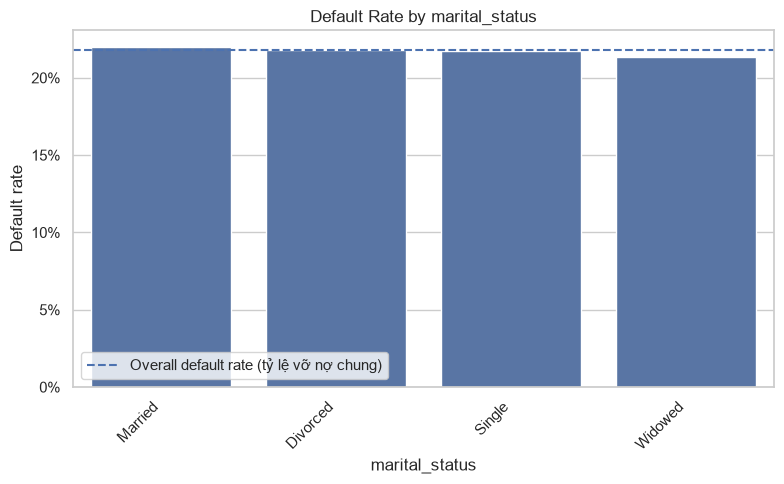


gender - Default rate by category


,category,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Female,16210,3545,21.87%,49.75%,+0.05%,0.05%,False
1,Male,16371,3563,21.76%,50.25%,-0.05%,0.05%,False


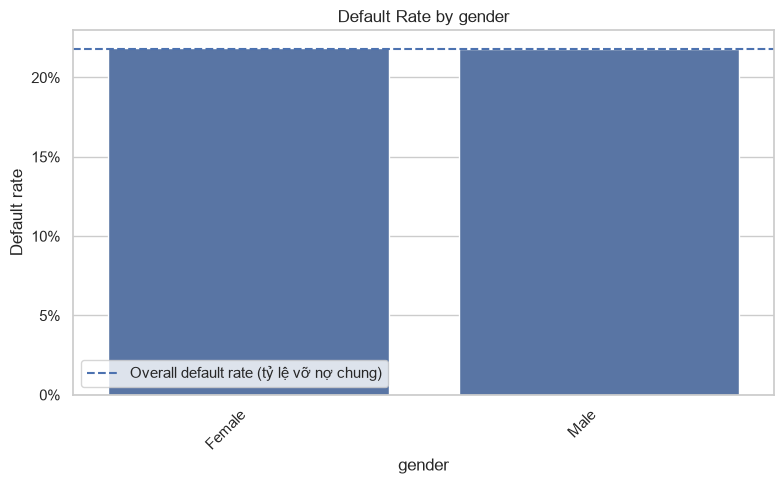


TOP CATEGORICAL TARGET DRIVERS - CÁC BIẾN PHÂN LOẠI ĐÁNG CHÚ Ý


,column,unique_count,reliable_group_count,small_group_count,min_default_rate,max_default_rate,default_rate_spread,max_abs_gap_vs_overall,potential_leakage_flag,sensitive_or_proxy_flag
0,loan_grade,7,6,1,9.96%,70.54%,60.58%,48.72%,True,False
1,cb_person_default_on_file,2,2,0,18.39%,37.81%,19.41%,15.99%,False,False
2,person_home_ownership,4,3,1,7.47%,31.57%,24.10%,14.35%,False,False
3,loan_intent,6,6,0,14.81%,28.59%,13.78%,7.01%,False,False
4,employment_type,4,4,0,21.57%,22.67%,1.10%,0.85%,False,False
5,education_level,4,4,0,21.16%,22.17%,1.01%,0.65%,False,False
6,marital_status,4,4,0,21.37%,21.96%,0.59%,0.44%,False,False
7,gender,2,2,0,21.76%,21.87%,0.11%,0.05%,False,True



Lưu ý:
- Driver (biến có tín hiệu mạnh) trong EDA không đồng nghĩa với nguyên nhân gây default.
- small_group_flag = True nghĩa là nhóm có sample size (số quan sát) nhỏ, default rate có thể không ổn định.
- potential_leakage_flag = True nghĩa là biến có nguy cơ Data Leakage (rò rỉ dữ liệu), chưa được mặc định đưa vào Primary Model (mô hình chính).
- sensitive_or_proxy_flag = True nghĩa là biến cần Fairness/Proxy Review (kiểm tra tính công bằng hoặc biến đại diện).


In [13]:
# 4.3 - Default rate theo categorical variables

# ============================================================
# 1. Kiểm tra input
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(
        f"Không tìm thấy target column: {TARGET_COL}"
    )

if "categorical_plot_cols" not in globals():
    raise NameError(
        "Chưa có categorical_plot_cols. "
        "Hãy chạy cell 4.2 trước."
    )

# Chỉ sử dụng target hợp lệ 0/1
valid_target_mask = (
    df_raw[TARGET_COL]
    .isin([0, 1])
)

valid_target_rows = int(
    valid_target_mask.sum()
)

if valid_target_rows == 0:
    raise ValueError(
        "Không có target 0/1 hợp lệ để phân tích."
    )

overall_default_rate = float(
    df_raw.loc[
        valid_target_mask,
        TARGET_COL
    ].mean()
)

print("=" * 90)
print("DEFAULT RATE BY CATEGORICAL VARIABLES")
print("=" * 90)

print(
    f"Overall default rate "
    f"(tỷ lệ vỡ nợ toàn bộ): "
    f"{overall_default_rate:.2%}"
)

# ============================================================
# 2. Cấu hình small groups
# ============================================================

SMALL_GROUP_MIN_COUNT = 100
SMALL_GROUP_MIN_SHARE = 0.005

category_target_tables = {}

driver_records = []

# ============================================================
# 3. Tạo bảng default rate cho từng biến
# ============================================================

for column in categorical_plot_cols:

    temp = (
        df_raw.loc[
            valid_target_mask,
            [column, TARGET_COL]
        ]
        .copy()
    )

    # Missing được xem như một category riêng trong EDA
    temp["category"] = (
        temp[column]
        .astype("string")
        .fillna("<Missing>")
    )

    category_table = (
        temp
        .groupby(
            "category",
            dropna=False
        )[TARGET_COL]
        .agg(
            count="size",
            default_count="sum",
            default_rate="mean",
        )
        .reset_index()
    )

    category_table["row_share"] = (
        category_table["count"]
        / valid_target_rows
    )

    # Chênh lệch so với default rate toàn dataset
    category_table[
        "default_rate_gap"
    ] = (
        category_table["default_rate"]
        - overall_default_rate
    )

    category_table[
        "abs_default_rate_gap"
    ] = (
        category_table[
            "default_rate_gap"
        ].abs()
    )

    # --------------------------------------------------------
    # Đánh dấu small group
    # --------------------------------------------------------

    category_table[
        "small_group_flag"
    ] = (
        (
            category_table["count"]
            < SMALL_GROUP_MIN_COUNT
        )
        |
        (
            category_table["row_share"]
            < SMALL_GROUP_MIN_SHARE
        )
    )

    category_table = (
        category_table
        .sort_values(
            "default_rate",
            ascending=False
        )
        .reset_index(drop=True)
    )

    category_target_tables[
        column
    ] = category_table

    # ========================================================
    # 4. Tính driver score cho từng categorical variable
    # ========================================================

    reliable_groups = (
        category_table.loc[
            ~category_table[
                "small_group_flag"
            ]
        ]
    )

    if len(reliable_groups) >= 2:

        max_default_rate = float(
            reliable_groups[
                "default_rate"
            ].max()
        )

        min_default_rate = float(
            reliable_groups[
                "default_rate"
            ].min()
        )

        default_rate_spread = (
            max_default_rate
            - min_default_rate
        )

        max_abs_gap = float(
            reliable_groups[
                "abs_default_rate_gap"
            ].max()
        )

    else:
        max_default_rate = np.nan
        min_default_rate = np.nan
        default_rate_spread = np.nan
        max_abs_gap = np.nan

    driver_records.append({
        "column": column,
        "unique_count": int(
            category_table.shape[0]
        ),
        "reliable_group_count": int(
            len(reliable_groups)
        ),
        "small_group_count": int(
            category_table[
                "small_group_flag"
            ].sum()
        ),
        "min_default_rate": (
            min_default_rate
        ),
        "max_default_rate": (
            max_default_rate
        ),
        "default_rate_spread": (
            default_rate_spread
        ),
        "max_abs_gap_vs_overall": (
            max_abs_gap
        ),
        "potential_leakage_flag": (
            column
            in globals().get(
                "potential_leakage_cols",
                []
            )
        ),
        "sensitive_or_proxy_flag": (
            column
            in globals().get(
                "sensitive_or_proxy_cols",
                []
            )
        ),
    })

# ============================================================
# 5. Display bảng và barplot từng biến
# ============================================================

MAX_PLOT_CATEGORIES = 15

for column, table in category_target_tables.items():

    print()
    print("=" * 90)
    print(
        f"{column} - Default rate by category"
    )
    print("=" * 90)

    display(
        table.style.format({
            "row_share": "{:.2%}",
            "default_rate": "{:.2%}",
            "default_rate_gap": "{:+.2%}",
            "abs_default_rate_gap": "{:.2%}",
        })
    )

    # --------------------------------------------------------
    # Chỉ plot tối đa 15 nhóm lớn nhất theo sample size
    # --------------------------------------------------------

    plot_table = (
        table
        .sort_values(
            "count",
            ascending=False
        )
        .head(MAX_PLOT_CATEGORIES)
        .sort_values(
            "default_rate",
            ascending=False
        )
    )

    plt.figure(
        figsize=(
            max(
                8,
                len(plot_table) * 0.75
            ),
            5
        )
    )

    ax = sns.barplot(
        data=plot_table,
        x="category",
        y="default_rate"
    )

    ax.axhline(
        overall_default_rate,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Overall default rate "
            "(tỷ lệ vỡ nợ chung)"
        )
    )

    ax.set_title(
        f"Default Rate by {column}"
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Default rate")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{y:.0%}"
        )
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 6. Xếp hạng categorical target drivers
# ============================================================

categorical_target_driver_summary = (
    pd.DataFrame(driver_records)
)

categorical_target_driver_summary = (
    categorical_target_driver_summary
    .sort_values(
        [
            "max_abs_gap_vs_overall",
            "default_rate_spread",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# Top drivers chỉ để EDA,
# chưa có nghĩa là feature cuối cùng của model
top_categorical_target_drivers = (
    categorical_target_driver_summary
    .head(10)
    .copy()
)

# ============================================================
# 7. Display driver ranking
# ============================================================

print()
print("=" * 90)
print(
    "TOP CATEGORICAL TARGET DRIVERS "
    "- CÁC BIẾN PHÂN LOẠI ĐÁNG CHÚ Ý"
)
print("=" * 90)

display(
    top_categorical_target_drivers.style.format({
        "min_default_rate": "{:.2%}",
        "max_default_rate": "{:.2%}",
        "default_rate_spread": "{:.2%}",
        "max_abs_gap_vs_overall": "{:.2%}",
    })
)

print()
print("Lưu ý:")

print(
    "- Driver (biến có tín hiệu mạnh) trong EDA "
    "không đồng nghĩa với nguyên nhân gây default."
)

print(
    "- small_group_flag = True nghĩa là nhóm có "
    "sample size (số quan sát) nhỏ, default rate "
    "có thể không ổn định."
)

print(
    "- potential_leakage_flag = True nghĩa là biến "
    "có nguy cơ Data Leakage (rò rỉ dữ liệu), "
    "chưa được mặc định đưa vào Primary Model "
    "(mô hình chính)."
)

print(
    "- sensitive_or_proxy_flag = True nghĩa là biến "
    "cần Fairness/Proxy Review "
    "(kiểm tra tính công bằng hoặc biến đại diện)."
)

## Section 5 - Correlation và Redundancy

Correlation giúp phát hiện redundancy và quan hệ tuyến tính giữa numeric variables.

Không kết luận nhân quả từ correlation. Với credit risk, cần chú ý các biến được suy ra trực tiếp từ nhau như `loan_percent_income` và `loan_to_income_ratio`.

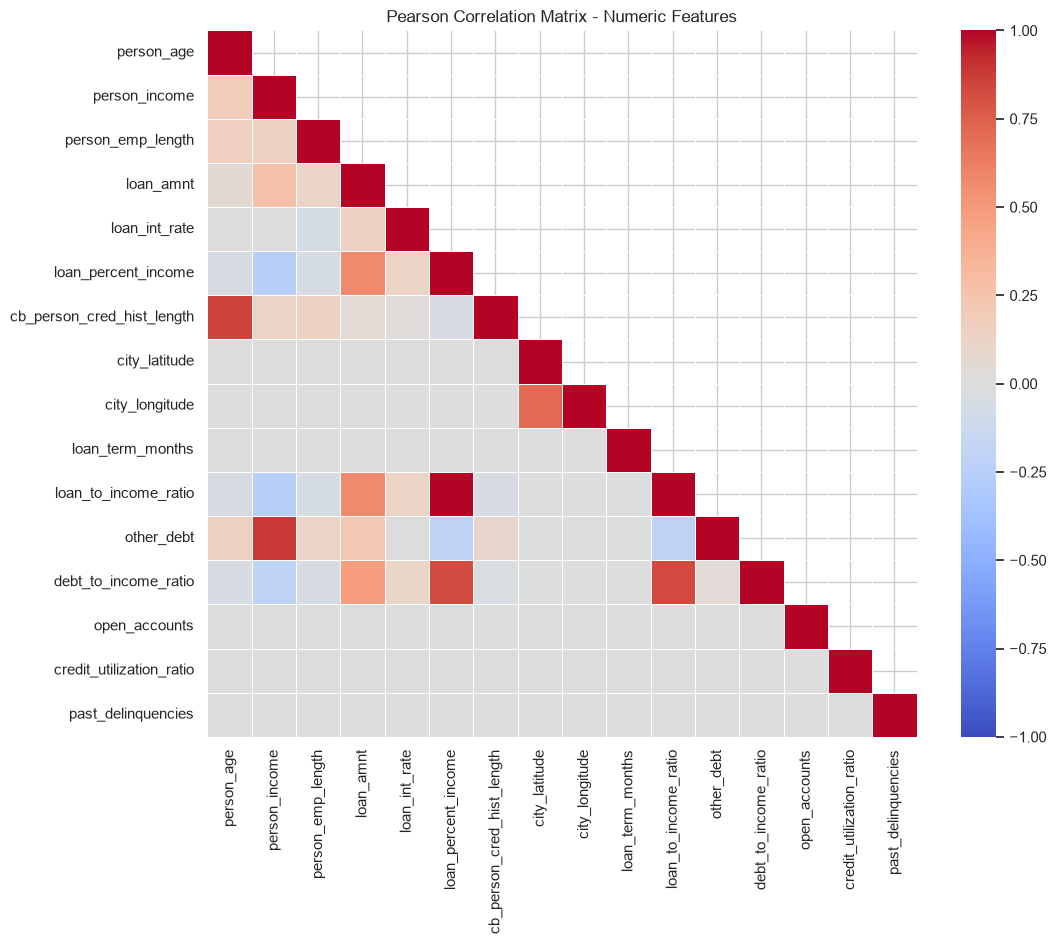

CORRELATION & REDUNDANCY REVIEW - PHÂN TÍCH TƯƠNG QUAN VÀ TRÙNG LẶP BIẾN
Numeric features reviewed: 16
High correlation threshold: |r| >= 0.8

--- Highest correlation pairs (các cặp tương quan mạnh nhất) ---


,feature_1,feature_2,correlation,abs_correlation
0,loan_percent_income,loan_to_income_ratio,+0.999,0.999
1,person_income,other_debt,+0.887,0.887
2,person_age,cb_person_cred_hist_length,+0.859,0.859
3,loan_to_income_ratio,debt_to_income_ratio,+0.829,0.829
4,loan_percent_income,debt_to_income_ratio,+0.828,0.828
5,city_latitude,city_longitude,+0.714,0.714
6,loan_amnt,loan_to_income_ratio,+0.577,0.577
7,loan_amnt,loan_percent_income,+0.573,0.573
8,loan_amnt,debt_to_income_ratio,+0.481,0.481
9,person_income,loan_amnt,+0.267,0.267



--- High correlation pairs (các cặp có tương quan cao) ---


,feature_1,feature_2,correlation,abs_correlation
0,loan_percent_income,loan_to_income_ratio,+0.999,0.999
1,person_income,other_debt,+0.887,0.887
2,person_age,cb_person_cred_hist_length,+0.859,0.859
3,loan_to_income_ratio,debt_to_income_ratio,+0.829,0.829
4,loan_percent_income,debt_to_income_ratio,+0.828,0.828



--- Redundant feature candidates (các cặp biến có khả năng trùng lặp thông tin) ---


,feature_1,feature_2,correlation,abs_correlation,known_relationship,redundancy_level,reason,recommendation
0,loan_percent_income,loan_to_income_ratio,+0.999,0.999,True,strong_candidate,Hai biến có ý nghĩa/công thức nghiệp vụ gần như tương đương và correlation cao.,Ưu tiên chỉ giữ một biến sau khi Feature Analysis (phân tích biến) xác nhận.
1,person_income,other_debt,+0.887,0.887,False,monitor,Correlation cao; có thể chứa một phần thông tin tương tự.,"Theo dõi ở Feature Analysis và Modeling (xây dựng mô hình), chưa tự động loại."
2,person_age,cb_person_cred_hist_length,+0.859,0.859,False,monitor,Correlation cao; có thể chứa một phần thông tin tương tự.,"Theo dõi ở Feature Analysis và Modeling (xây dựng mô hình), chưa tự động loại."
3,loan_to_income_ratio,debt_to_income_ratio,+0.829,0.829,False,monitor,Correlation cao; có thể chứa một phần thông tin tương tự.,"Theo dõi ở Feature Analysis và Modeling (xây dựng mô hình), chưa tự động loại."
4,loan_percent_income,debt_to_income_ratio,+0.828,0.828,False,monitor,Correlation cao; có thể chứa một phần thông tin tương tự.,"Theo dõi ở Feature Analysis và Modeling (xây dựng mô hình), chưa tự động loại."



--- Correlation notes (ghi chú phân tích) ---
- Pearson correlation (tương quan Pearson) chỉ đo quan hệ tuyến tính.
- Correlation cao không đồng nghĩa hai biến chắc chắn phải loại một biến.
- Correlation không chứng minh causality (quan hệ nhân quả).
- ID và target không được đưa vào correlation matrix chính vì mục tiêu ở đây là review redundancy (mức độ trùng lặp thông tin) giữa features.
- loan_percent_income và loan_to_income_ratio được theo dõi đặc biệt vì hai biến có ý nghĩa gần như tương đương trong dataset.


In [14]:
# 5.1 - Correlation matrix

# ============================================================
# 1. Kiểm tra input
# ============================================================

if "numeric_feature_cols" not in globals():
    raise NameError(
        "Chưa có numeric_feature_cols. "
        "Hãy chạy cell 2.1 trước."
    )

corr_cols = [
    col for col in numeric_feature_cols
    if col in df_raw.columns
]

if len(corr_cols) < 2:
    raise ValueError(
        "Cần ít nhất 2 numeric features "
        "để tính correlation."
    )

# Không đưa ID và target vào correlation review chính
excluded_from_corr = [
    col for col in [
        globals().get("ID_COL", "client_ID"),
        globals().get("TARGET_COL", "loan_status"),
    ]
    if col in corr_cols
]

corr_cols = [
    col for col in corr_cols
    if col not in excluded_from_corr
]

# ============================================================
# 2. Tính Pearson correlation matrix
# ============================================================

corr_matrix = (
    df_raw[corr_cols]
    .corr(method="pearson")
)

# ============================================================
# 3. Vẽ correlation heatmap
# ============================================================

# Chỉ hiển thị nửa dưới để tránh lặp thông tin
heatmap_mask = np.triu(
    np.ones_like(
        corr_matrix,
        dtype=bool
    ),
    k=1
)

plt.figure(
    figsize=(
        max(10, len(corr_cols) * 0.7),
        max(8, len(corr_cols) * 0.6),
    )
)

sns.heatmap(
    corr_matrix,
    mask=heatmap_mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=len(corr_cols) <= 12,
    fmt=".2f",
    linewidths=0.5,
)

plt.title(
    "Pearson Correlation Matrix - Numeric Features"
)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Tạo danh sách tất cả các cặp correlation
# ============================================================

upper_triangle = (
    corr_matrix
    .where(
        np.triu(
            np.ones(
                corr_matrix.shape,
                dtype=bool
            ),
            k=1
        )
    )
)

corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]

corr_pairs["abs_correlation"] = (
    corr_pairs["correlation"].abs()
)

corr_pairs = (
    corr_pairs
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# 5. Tìm các cặp có correlation cao
# ============================================================

HIGH_CORR_THRESHOLD = 0.80
VERY_HIGH_CORR_THRESHOLD = 0.95

high_corr_pairs = (
    corr_pairs.loc[
        corr_pairs["abs_correlation"]
        >= HIGH_CORR_THRESHOLD
    ]
    .copy()
    .reset_index(drop=True)
)

# ============================================================
# 6. Đánh dấu các cặp có khả năng redundancy
# ============================================================

# Các cặp đã có lý do nghiệp vụ để nghi ngờ
# có thông tin gần như trùng nhau
known_redundant_pairs = {
    frozenset(
        [
            "loan_percent_income",
            "loan_to_income_ratio",
        ]
    ),
}

redundant_records = []

for _, row in high_corr_pairs.iterrows():

    feature_1 = row["feature_1"]
    feature_2 = row["feature_2"]

    corr_value = float(
        row["correlation"]
    )

    abs_corr = float(
        row["abs_correlation"]
    )

    pair_key = frozenset(
        [feature_1, feature_2]
    )

    known_relationship = (
        pair_key in known_redundant_pairs
    )

    if known_relationship:
        redundancy_level = "strong_candidate"

        reason = (
            "Hai biến có ý nghĩa/công thức nghiệp vụ "
            "gần như tương đương và correlation cao."
        )

        recommendation = (
            "Ưu tiên chỉ giữ một biến sau khi "
            "Feature Analysis "
            "(phân tích biến) xác nhận."
        )

    elif abs_corr >= VERY_HIGH_CORR_THRESHOLD:
        redundancy_level = "review_high_corr"

        reason = (
            "Correlation rất cao nhưng chưa đủ "
            "bằng chứng để kết luận hai biến trùng nhau."
        )

        recommendation = (
            "Review business meaning "
            "(xem xét ý nghĩa nghiệp vụ) và công thức "
            "trước khi quyết định loại biến."
        )

    else:
        redundancy_level = "monitor"

        reason = (
            "Correlation cao; có thể chứa một phần "
            "thông tin tương tự."
        )

        recommendation = (
            "Theo dõi ở Feature Analysis và Modeling "
            "(xây dựng mô hình), chưa tự động loại."
        )

    redundant_records.append({
        "feature_1": feature_1,
        "feature_2": feature_2,
        "correlation": corr_value,
        "abs_correlation": abs_corr,
        "known_relationship": (
            known_relationship
        ),
        "redundancy_level": (
            redundancy_level
        ),
        "reason": reason,
        "recommendation": (
            recommendation
        ),
    })

redundant_feature_candidates = (
    pd.DataFrame(
        redundant_records,
        columns=[
            "feature_1",
            "feature_2",
            "correlation",
            "abs_correlation",
            "known_relationship",
            "redundancy_level",
            "reason",
            "recommendation",
        ]
    )
)

# ============================================================
# 7. Correlation notes
# ============================================================

correlation_notes = [
    (
        "Pearson correlation "
        "(tương quan Pearson) chỉ đo quan hệ tuyến tính."
    ),
    (
        "Correlation cao không đồng nghĩa hai biến "
        "chắc chắn phải loại một biến."
    ),
    (
        "Correlation không chứng minh causality "
        "(quan hệ nhân quả)."
    ),
    (
        "ID và target không được đưa vào correlation matrix "
        "chính vì mục tiêu ở đây là review redundancy "
        "(mức độ trùng lặp thông tin) giữa features."
    ),
    (
        "loan_percent_income và loan_to_income_ratio "
        "được theo dõi đặc biệt vì hai biến có ý nghĩa "
        "gần như tương đương trong dataset."
    ),
]

# ============================================================
# 8. Display
# ============================================================

print("=" * 90)
print(
    "CORRELATION & REDUNDANCY REVIEW - "
    "PHÂN TÍCH TƯƠNG QUAN VÀ TRÙNG LẶP BIẾN"
)
print("=" * 90)

print(
    f"Numeric features reviewed: "
    f"{len(corr_cols)}"
)

print(
    f"High correlation threshold: "
    f"|r| >= {HIGH_CORR_THRESHOLD}"
)

print(
    "\n--- Highest correlation pairs "
    "(các cặp tương quan mạnh nhất) ---"
)

display(
    corr_pairs
    .head(15)
    .style.format({
        "correlation": "{:+.3f}",
        "abs_correlation": "{:.3f}",
    })
)

print(
    "\n--- High correlation pairs "
    "(các cặp có tương quan cao) ---"
)

if high_corr_pairs.empty:
    print(
        "Không có cặp numeric feature nào "
        f"có |correlation| >= {HIGH_CORR_THRESHOLD}."
    )
else:
    display(
        high_corr_pairs.style.format({
            "correlation": "{:+.3f}",
            "abs_correlation": "{:.3f}",
        })
    )

print(
    "\n--- Redundant feature candidates "
    "(các cặp biến có khả năng trùng lặp thông tin) ---"
)

if redundant_feature_candidates.empty:
    print(
        "Không phát hiện redundant feature candidate "
        "theo threshold hiện tại."
    )
else:
    display(
        redundant_feature_candidates.style.format({
            "correlation": "{:+.3f}",
            "abs_correlation": "{:.3f}",
        })
    )

print(
    "\n--- Correlation notes "
    "(ghi chú phân tích) ---"
)

for note in correlation_notes:
    print(f"- {note}")

NUMERIC SCATTER ANALYSIS - PHÂN TÍCH QUAN HỆ GIỮA CÁC BIẾN SỐ


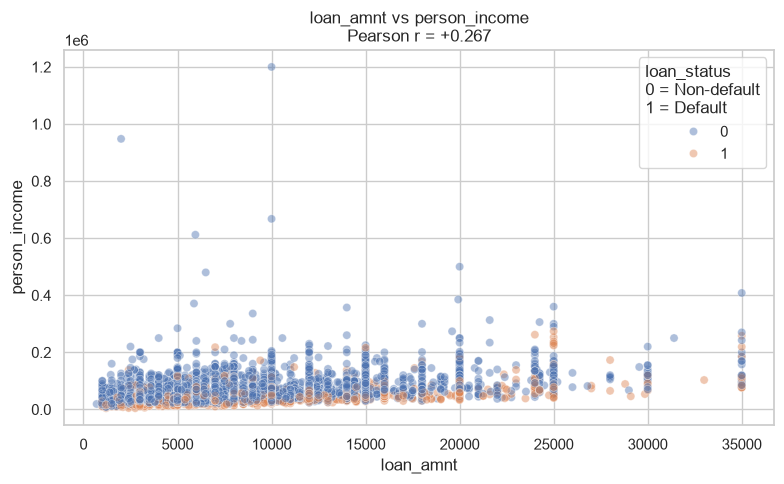

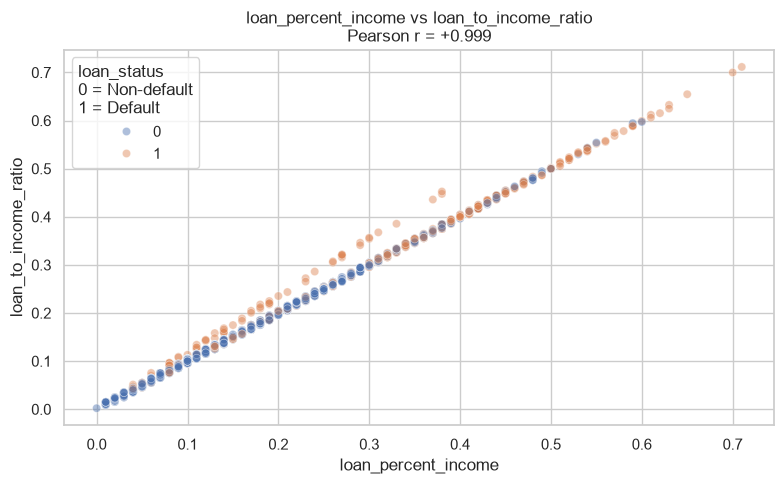

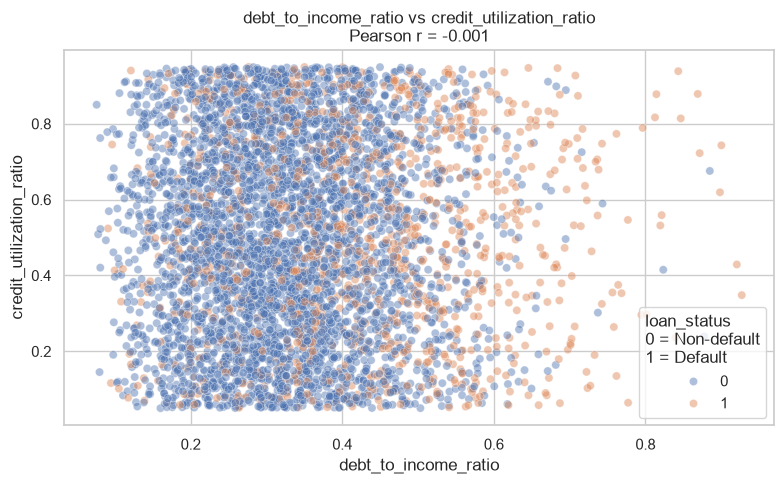


--- Scatter analysis notes (ghi chú phân tích biểu đồ phân tán) ---


,feature_x,feature_y,complete_rows,plot_rows,sampled_for_plot,pearson_correlation,relationship_strength,interpretation
0,loan_amnt,person_income,32581,5000,True,+0.267,very_weak_linear,Ít quan hệ tuyến tính. Scatterplot vẫn cần được xem để phát hiện non-linear relationship (quan hệ phi tuyến) hoặc anomaly (điểm bất thường).
1,loan_percent_income,loan_to_income_ratio,32581,5000,True,+0.999,very_strong_linear,Hai biến có quan hệ tuyến tính gần như hoàn hảo; cần review redundancy (trùng lặp thông tin). Đây là cặp đặc biệt cần chú ý vì hai biến đều biểu diễn tỷ lệ khoản vay trên thu nhập.
2,debt_to_income_ratio,credit_utilization_ratio,32581,5000,True,-0.001,very_weak_linear,Ít quan hệ tuyến tính. Scatterplot vẫn cần được xem để phát hiện non-linear relationship (quan hệ phi tuyến) hoặc anomaly (điểm bất thường).



Lưu ý:
- Scatterplot giúp nhìn cả linear relationship (quan hệ tuyến tính), non-linear pattern (mẫu quan hệ phi tuyến) và anomaly (điểm bất thường).
- Correlation cao không chứng minh causality (quan hệ nhân quả).
- Việc sample tối đa 5,000 dòng chỉ phục vụ visualization (trực quan hóa), không thay đổi df_raw.
- Hue theo loan_status chỉ giúp quan sát sự phân bố Default/Non-default, không dùng để kết luận feature chắc chắn tốt cho model.


In [15]:
# 5.2 - Scatter plots cho các cặp numeric quan trọng

# ============================================================
# 1. Kiểm tra input
# ============================================================

TARGET_COL = globals().get(
    "TARGET_COL",
    "loan_status"
)

# Các cặp được chọn dựa trên ý nghĩa nghiệp vụ
scatter_pair_candidates = [
    (
        "loan_amnt",
        "person_income",
    ),
    (
        "loan_percent_income",
        "loan_to_income_ratio",
    ),
    (
        "debt_to_income_ratio",
        "credit_utilization_ratio",
    ),
]

scatter_pairs = [
    pair
    for pair in scatter_pair_candidates
    if pair[0] in df_raw.columns
    and pair[1] in df_raw.columns
]

if not scatter_pairs:
    raise ValueError(
        "Không tìm thấy cặp numeric feature "
        "phù hợp để vẽ scatterplot."
    )

# ============================================================
# 2. Cấu hình sample
# ============================================================

MAX_SCATTER_ROWS = 5000
RANDOM_STATE = 42

scatter_records = []

print("=" * 90)
print(
    "NUMERIC SCATTER ANALYSIS - "
    "PHÂN TÍCH QUAN HỆ GIỮA CÁC BIẾN SỐ"
)
print("=" * 90)

# ============================================================
# 3. Vẽ scatterplot từng cặp
# ============================================================

for x_col, y_col in scatter_pairs:

    required_cols = [
        x_col,
        y_col,
    ]

    if TARGET_COL in df_raw.columns:
        required_cols.append(
            TARGET_COL
        )

    pair_data = (
        df_raw[required_cols]
        .dropna(
            subset=[
                x_col,
                y_col,
            ]
        )
        .copy()
    )

    total_complete_rows = len(
        pair_data
    )

    # --------------------------------------------------------
    # Sample nếu dataset lớn
    # --------------------------------------------------------

    if (
        total_complete_rows
        > MAX_SCATTER_ROWS
    ):
        plot_data = (
            pair_data
            .sample(
                n=MAX_SCATTER_ROWS,
                random_state=RANDOM_STATE,
            )
            .copy()
        )

        sampled = True

    else:
        plot_data = pair_data.copy()
        sampled = False

    # --------------------------------------------------------
    # Pearson correlation của cặp
    # --------------------------------------------------------

    correlation = float(
        pair_data[
            [x_col, y_col]
        ]
        .corr()
        .iloc[0, 1]
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    if (
        TARGET_COL in plot_data.columns
        and plot_data[
            TARGET_COL
        ].nunique(dropna=True) > 1
    ):

        sns.scatterplot(
            data=plot_data,
            x=x_col,
            y=y_col,
            hue=TARGET_COL,
            alpha=0.45,
            s=35,
        )

        plt.legend(
            title=(
                f"{TARGET_COL}\n"
                "0 = Non-default\n"
                "1 = Default"
            )
        )

    else:

        sns.scatterplot(
            data=plot_data,
            x=x_col,
            y=y_col,
            alpha=0.45,
            s=35,
        )

    plt.title(
        f"{x_col} vs {y_col}\n"
        f"Pearson r = {correlation:+.3f}"
    )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

    # ========================================================
    # 4. Tạo note tự động
    # ========================================================

    abs_corr = abs(
        correlation
    )

    if abs_corr >= 0.95:
        relationship_strength = (
            "very_strong_linear"
        )

        interpretation = (
            "Hai biến có quan hệ tuyến tính gần như "
            "hoàn hảo; cần review redundancy "
            "(trùng lặp thông tin)."
        )

    elif abs_corr >= 0.80:
        relationship_strength = (
            "strong_linear"
        )

        interpretation = (
            "Hai biến có quan hệ tuyến tính mạnh; "
            "cần xem xét khả năng chứa thông tin tương tự."
        )

    elif abs_corr >= 0.50:
        relationship_strength = (
            "moderate_linear"
        )

        interpretation = (
            "Hai biến có quan hệ tuyến tính mức vừa."
        )

    elif abs_corr >= 0.30:
        relationship_strength = (
            "weak_linear"
        )

        interpretation = (
            "Quan hệ tuyến tính tương đối yếu."
        )

    else:
        relationship_strength = (
            "very_weak_linear"
        )

        interpretation = (
            "Ít quan hệ tuyến tính. Scatterplot vẫn cần "
            "được xem để phát hiện non-linear relationship "
            "(quan hệ phi tuyến) hoặc anomaly "
            "(điểm bất thường)."
        )

    # --------------------------------------------------------
    # Ghi chú riêng cho cặp gần như redundant
    # --------------------------------------------------------

    if {
        x_col,
        y_col,
    } == {
        "loan_percent_income",
        "loan_to_income_ratio",
    }:

        interpretation += (
            " Đây là cặp đặc biệt cần chú ý vì hai biến "
            "đều biểu diễn tỷ lệ khoản vay trên thu nhập."
        )

    scatter_records.append({
        "feature_x": x_col,
        "feature_y": y_col,
        "complete_rows": (
            total_complete_rows
        ),
        "plot_rows": len(
            plot_data
        ),
        "sampled_for_plot": sampled,
        "pearson_correlation": (
            correlation
        ),
        "relationship_strength": (
            relationship_strength
        ),
        "interpretation": (
            interpretation
        ),
    })

# ============================================================
# 5. Tạo scatter notes
# ============================================================

scatter_notes = pd.DataFrame(
    scatter_records
)

# ============================================================
# 6. Display summary
# ============================================================

print()
print(
    "--- Scatter analysis notes "
    "(ghi chú phân tích biểu đồ phân tán) ---"
)

display(
    scatter_notes.style.format({
        "pearson_correlation": "{:+.3f}",
    })
)

print()
print("Lưu ý:")

print(
    "- Scatterplot giúp nhìn cả linear relationship "
    "(quan hệ tuyến tính), non-linear pattern "
    "(mẫu quan hệ phi tuyến) và anomaly "
    "(điểm bất thường)."
)

print(
    "- Correlation cao không chứng minh causality "
    "(quan hệ nhân quả)."
)

print(
    "- Việc sample tối đa 5,000 dòng chỉ phục vụ "
    "visualization (trực quan hóa), không thay đổi df_raw."
)

print(
    "- Hue theo loan_status chỉ giúp quan sát sự phân bố "
    "Default/Non-default, không dùng để kết luận feature "
    "chắc chắn tốt cho model."
)

## Section 6 - Missing và Outlier Follow-up

Phần này nối tiếp Data Audit. Mục tiêu là xem missing/outlier có liên quan target hoặc pattern EDA nào không.

Không impute/drop/clip chính thức trong notebook này.

In [16]:
# 6.1 - Missing indicators vs target

# ============================================================
# 1. Kiểm tra input
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(
        f"Không tìm thấy target column: {TARGET_COL}"
    )

valid_target_mask = df_raw[TARGET_COL].isin([0, 1])

if valid_target_mask.sum() == 0:
    raise ValueError(
        "Không có target 0/1 hợp lệ để phân tích."
    )

overall_default_rate = float(
    df_raw.loc[
        valid_target_mask,
        TARGET_COL
    ].mean()
)

# Ưu tiên chỉ kiểm tra feature, không kiểm tra ID và target
if "feature_cols" in globals():
    candidate_cols = [
        col for col in feature_cols
        if col in df_raw.columns
    ]
else:
    candidate_cols = [
        col for col in df_raw.columns
        if col not in {
            globals().get("ID_COL", "client_ID"),
            TARGET_COL,
        }
    ]

# ============================================================
# 2. Tìm các cột có missing
# ============================================================

missing_cols = [
    col for col in candidate_cols
    if df_raw[col].isna().any()
]

missing_target_records = []

# ============================================================
# 3. So sánh Default Rate giữa Missing và Not Missing
# ============================================================

for column in missing_cols:

    missing_mask = (
        df_raw[column].isna()
        & valid_target_mask
    )

    not_missing_mask = (
        df_raw[column].notna()
        & valid_target_mask
    )

    missing_count = int(
        df_raw[column].isna().sum()
    )

    missing_rate = (
        missing_count / len(df_raw)
    )

    default_rate_when_missing = (
        float(
            df_raw.loc[
                missing_mask,
                TARGET_COL
            ].mean()
        )
        if missing_mask.sum() > 0
        else np.nan
    )

    default_rate_when_not_missing = (
        float(
            df_raw.loc[
                not_missing_mask,
                TARGET_COL
            ].mean()
        )
        if not_missing_mask.sum() > 0
        else np.nan
    )

    default_rate_delta = (
        default_rate_when_missing
        - default_rate_when_not_missing
    )

    abs_default_rate_delta = abs(
        default_rate_delta
    )

    # --------------------------------------------------------
    # Phân loại mức tín hiệu để ưu tiên review
    # Đây KHÔNG phải kết luận feature tốt cho model
    # --------------------------------------------------------

    if abs_default_rate_delta >= 0.05:
        missing_signal = "strong"
    elif abs_default_rate_delta >= 0.02:
        missing_signal = "moderate"
    else:
        missing_signal = "weak"

    missing_target_records.append({
        "column": column,
        "missing_count": missing_count,
        "missing_rate": missing_rate,
        "default_rate_when_missing": (
            default_rate_when_missing
        ),
        "default_rate_when_not_missing": (
            default_rate_when_not_missing
        ),
        "default_rate_delta": (
            default_rate_delta
        ),
        "abs_default_rate_delta": (
            abs_default_rate_delta
        ),
        "missing_signal": missing_signal,
    })

# ============================================================
# 4. Tạo summary table
# ============================================================

missing_target_summary = pd.DataFrame(
    missing_target_records,
    columns=[
        "column",
        "missing_count",
        "missing_rate",
        "default_rate_when_missing",
        "default_rate_when_not_missing",
        "default_rate_delta",
        "abs_default_rate_delta",
        "missing_signal",
    ]
)

if not missing_target_summary.empty:
    missing_target_summary = (
        missing_target_summary
        .sort_values(
            [
                "abs_default_rate_delta",
                "missing_rate",
            ],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

# ============================================================
# 5. Missing indicator candidates
# ============================================================

# Tất cả biến có missing đều là candidate để thử.
# Thứ tự được xếp theo độ chênh Default Rate.
# Quyết định cuối cùng phải dựa trên Cross-validation
# (kiểm định chéo).

missing_indicator_candidates = (
    missing_target_summary["column"]
    .tolist()
    if not missing_target_summary.empty
    else []
)

# Các biến có tín hiệu từ moderate trở lên
higher_priority_missing_indicators = (
    missing_target_summary.loc[
        missing_target_summary[
            "missing_signal"
        ].isin(["strong", "moderate"]),
        "column"
    ]
    .tolist()
    if not missing_target_summary.empty
    else []
)

# ============================================================
# 6. Notes
# ============================================================

missing_indicator_notes = []

if not missing_cols:
    missing_indicator_notes.append(
        "Không phát hiện feature nào có missing."
    )
else:
    missing_indicator_notes.append(
        f"Phát hiện {len(missing_cols)} feature có missing."
    )

if higher_priority_missing_indicators:
    missing_indicator_notes.append(
        "Các missing indicator có tín hiệu đáng review hơn: "
        + ", ".join(
            higher_priority_missing_indicators
        )
        + "."
    )

missing_indicator_notes.append(
    "Default Rate khác nhau giữa Missing và Not Missing "
    "chỉ cho thấy missingness có thể chứa tín hiệu; "
    "không chứng minh missing indicator chắc chắn cải thiện model."
)

missing_indicator_notes.append(
    "Missing indicator phải được kiểm chứng bằng "
    "Cross-validation (kiểm định chéo) trong pipeline sau này."
)

# ============================================================
# 7. Display
# ============================================================

print("=" * 90)
print(
    "MISSING INDICATORS VS TARGET - "
    "MISSING VÀ TỶ LỆ VỠ NỢ"
)
print("=" * 90)

print(
    f"Overall Default Rate "
    f"(tỷ lệ vỡ nợ chung): "
    f"{overall_default_rate:.2%}"
)

print(
    f"Columns with missing "
    f"(số cột có dữ liệu thiếu): "
    f"{len(missing_cols)}"
)

print()

if missing_target_summary.empty:
    print(
        "Không có missing feature để phân tích."
    )
else:
    display(
        missing_target_summary.style.format({
            "missing_rate": "{:.2%}",
            "default_rate_when_missing": "{:.2%}",
            "default_rate_when_not_missing": "{:.2%}",
            "default_rate_delta": "{:+.2%}",
            "abs_default_rate_delta": "{:.2%}",
        })
    )

print(
    "\nMissing indicator candidates "
    "(các biến có thể thử thêm cờ đánh dấu missing):"
)
print(missing_indicator_candidates)

print(
    "\nHigher-priority candidates "
    "(các biến nên ưu tiên kiểm chứng):"
)
print(higher_priority_missing_indicators)

print(
    "\n--- EDA notes "
    "(ghi chú phân tích) ---"
)

for note in missing_indicator_notes:
    print(f"- {note}")

MISSING INDICATORS VS TARGET - MISSING VÀ TỶ LỆ VỠ NỢ
Overall Default Rate (tỷ lệ vỡ nợ chung): 21.82%
Columns with missing (số cột có dữ liệu thiếu): 2



,column,missing_count,missing_rate,default_rate_when_missing,default_rate_when_not_missing,default_rate_delta,abs_default_rate_delta,missing_signal
0,person_emp_length,895,2.75%,31.51%,21.54%,+9.97%,9.97%,strong
1,loan_int_rate,3116,9.56%,20.67%,21.94%,-1.27%,1.27%,weak



Missing indicator candidates (các biến có thể thử thêm cờ đánh dấu missing):
['person_emp_length', 'loan_int_rate']

Higher-priority candidates (các biến nên ưu tiên kiểm chứng):
['person_emp_length']

--- EDA notes (ghi chú phân tích) ---
- Phát hiện 2 feature có missing.
- Các missing indicator có tín hiệu đáng review hơn: person_emp_length.
- Default Rate khác nhau giữa Missing và Not Missing chỉ cho thấy missingness có thể chứa tín hiệu; không chứng minh missing indicator chắc chắn cải thiện model.
- Missing indicator phải được kiểm chứng bằng Cross-validation (kiểm định chéo) trong pipeline sau này.


In [17]:
# 6.2 - Outlier follow-up theo business intuition

# ============================================================
# 1. Kiểm tra input
# ============================================================

AGE_COL = "person_age"
EMP_COL = "person_emp_length"

required_cols = [
    AGE_COL,
    EMP_COL,
]

missing_required_cols = [
    col for col in required_cols
    if col not in df_raw.columns
]

if missing_required_cols:
    raise KeyError(
        "Không tìm thấy các cột cần thiết: "
        + ", ".join(missing_required_cols)
    )

# ============================================================
# 2. Business rules
# ============================================================

AGE_MIN = 20
AGE_MAX = 100

# Đây là giả định kiểm tra tính hợp lý dữ liệu,
# không phải khẳng định pháp lý về tuổi lao động.
MIN_WORKING_AGE = 14

age_series = df_raw[AGE_COL]
emp_series = df_raw[EMP_COL]

# ============================================================
# 3. Rule 1 - Age violation
# ============================================================

age_violation_mask = (
    age_series.notna()
    & ~age_series.between(
        AGE_MIN,
        AGE_MAX,
        inclusive="both"
    )
)

age_violation_count = int(
    age_violation_mask.sum()
)

age_violation_rate = (
    age_violation_count
    / len(df_raw)
)

# ============================================================
# 4. Rule 2 - Employment length inconsistent with age
# ============================================================

max_possible_emp_length = (
    age_series
    - MIN_WORKING_AGE
)

# Chỉ kiểm tra khi:
# - age có dữ liệu
# - employment length có dữ liệu
# - age bản thân đã hợp lệ
employment_checkable_mask = (
    age_series.notna()
    & emp_series.notna()
    & age_series.between(
        AGE_MIN,
        AGE_MAX,
        inclusive="both"
    )
)

employment_violation_mask = (
    employment_checkable_mask
    & (
        emp_series
        > max_possible_emp_length
    )
)

employment_violation_count = int(
    employment_violation_mask.sum()
)

employment_violation_rate = (
    employment_violation_count
    / len(df_raw)
)

# ============================================================
# 5. Tạo outlier summary
# ============================================================

outlier_check_summary = pd.DataFrame([
    {
        "check": "age_outside_plausible_range",
        "business_rule": (
            f"{AGE_MIN} <= {AGE_COL} <= {AGE_MAX}"
        ),
        "affected_rows": (
            age_violation_count
        ),
        "rate": age_violation_rate,
        "interpretation": (
            "Tuổi nằm ngoài khoảng hợp lý "
            "được đặt cho project."
        ),
    },
    {
        "check": (
            "employment_length_inconsistent_with_age"
        ),
        "business_rule": (
            f"{EMP_COL} <= "
            f"{AGE_COL} - {MIN_WORKING_AGE}"
        ),
        "affected_rows": (
            employment_violation_count
        ),
        "rate": employment_violation_rate,
        "interpretation": (
            "Số năm làm việc lớn hơn số năm "
            "khách hàng có thể đã đi làm."
        ),
    },
])

# ============================================================
# 6. Preview age violation rows
# ============================================================

preview_columns = [
    col for col in [
        globals().get(
            "ID_COL",
            "client_ID"
        ),
        AGE_COL,
        EMP_COL,
        "person_income",
        "loan_amnt",
        globals().get(
            "TARGET_COL",
            "loan_status"
        ),
    ]
    if col in df_raw.columns
]

age_violation_preview = (
    df_raw.loc[
        age_violation_mask,
        preview_columns
    ]
    .copy()
)

if not age_violation_preview.empty:
    age_violation_preview[
        "violation_reason"
    ] = (
        f"{AGE_COL} outside "
        f"[{AGE_MIN}, {AGE_MAX}]"
    )

    age_violation_preview = (
        age_violation_preview
        .sort_values(
            AGE_COL,
            ascending=False
        )
        .reset_index(drop=True)
    )

# ============================================================
# 7. Preview employment violation rows
# ============================================================

employment_violation_preview = (
    df_raw.loc[
        employment_violation_mask,
        preview_columns
    ]
    .copy()
)

if not employment_violation_preview.empty:

    employment_violation_preview[
        "max_possible_emp_length"
    ] = (
        max_possible_emp_length.loc[
            employment_violation_mask
        ].values
    )

    employment_violation_preview[
        "years_over_limit"
    ] = (
        employment_violation_preview[
            EMP_COL
        ]
        - employment_violation_preview[
            "max_possible_emp_length"
        ]
    )

    employment_violation_preview = (
        employment_violation_preview
        .sort_values(
            "years_over_limit",
            ascending=False
        )
        .reset_index(drop=True)
    )

# ============================================================
# 8. Action note
# ============================================================

outlier_action_note = (
    "EDA chỉ xác nhận lại các outlier "
    "(giá trị ngoại lệ) đã biết và xem context "
    "(bối cảnh) của các dòng vi phạm. "
    "Không drop (xóa), clip (chặn về ngưỡng) "
    "hoặc sửa df_raw tại đây. "
    "person_age ngoài [20, 100] nên được review nguồn dữ liệu; "
    "nếu xác nhận là lỗi có thể cân nhắc loại dòng. "
    "person_emp_length không hợp lý nên cân nhắc "
    "đổi riêng giá trị sai thành missing và xử lý "
    "trong Preprocessing Pipeline "
    "(quy trình tiền xử lý dữ liệu). "
    f"MIN_WORKING_AGE = {MIN_WORKING_AGE} chỉ là "
    "giả định bảo thủ để kiểm tra tính hợp lý dữ liệu."
)

# ============================================================
# 9. Display
# ============================================================

print("=" * 90)
print(
    "OUTLIER FOLLOW-UP - "
    "KIỂM TRA LẠI GIÁ TRỊ NGOẠI LỆ"
)
print("=" * 90)

display(
    outlier_check_summary.style.format({
        "rate": "{:.3%}"
    })
)

print()
print(
    "--- Age violation preview "
    "(các dòng có tuổi bất hợp lý) ---"
)

if age_violation_preview.empty:
    print(
        "Không phát hiện age violation."
    )
else:
    display(age_violation_preview)

print()
print(
    "--- Employment violation preview "
    "(các dòng có số năm làm việc bất hợp lý) ---"
)

if employment_violation_preview.empty:
    print(
        "Không phát hiện employment length violation."
    )
else:
    display(
        employment_violation_preview
    )

print()
print(
    "--- Outlier action note "
    "(ghi chú hướng xử lý) ---"
)

print(outlier_action_note)

OUTLIER FOLLOW-UP - KIỂM TRA LẠI GIÁ TRỊ NGOẠI LỆ


,check,business_rule,affected_rows,rate,interpretation
0,age_outside_plausible_range,20 <= person_age <= 100,5,0.015%,Tuổi nằm ngoài khoảng hợp lý được đặt cho project.
1,employment_length_inconsistent_with_age,person_emp_length <= person_age - 14,2,0.006%,Số năm làm việc lớn hơn số năm khách hàng có thể đã đi làm.



--- Age violation preview (các dòng có tuổi bất hợp lý) ---


,client_ID,person_age,person_emp_length,person_income,loan_amnt,loan_status,violation_reason
0,CUST_00082,144,4.0000,250000,4800,0,"person_age outside [20, 100]"
1,CUST_00184,144,4.0000,200000,6000,0,"person_age outside [20, 100]"
2,CUST_32298,144,12.0000,6000000,5000,0,"person_age outside [20, 100]"
3,CUST_00576,123,2.0000,80004,20400,0,"person_age outside [20, 100]"
4,CUST_00748,123,7.0000,78000,20000,0,"person_age outside [20, 100]"



--- Employment violation preview (các dòng có số năm làm việc bất hợp lý) ---


,client_ID,person_age,person_emp_length,person_income,loan_amnt,loan_status,max_possible_emp_length,years_over_limit
0,CUST_00211,21,123.0000,192000,20000,0,7,116.0000
1,CUST_00001,22,123.0000,59000,35000,1,8,115.0000



--- Outlier action note (ghi chú hướng xử lý) ---
EDA chỉ xác nhận lại các outlier (giá trị ngoại lệ) đã biết và xem context (bối cảnh) của các dòng vi phạm. Không drop (xóa), clip (chặn về ngưỡng) hoặc sửa df_raw tại đây. person_age ngoài [20, 100] nên được review nguồn dữ liệu; nếu xác nhận là lỗi có thể cân nhắc loại dòng. person_emp_length không hợp lý nên cân nhắc đổi riêng giá trị sai thành missing và xử lý trong Preprocessing Pipeline (quy trình tiền xử lý dữ liệu). MIN_WORKING_AGE = 14 chỉ là giả định bảo thủ để kiểm tra tính hợp lý dữ liệu.


## Section 7 - Leakage, Fairness và Proxy Review

EDA được phép xem các biến nhạy cảm/leakage để hiểu dữ liệu, nhưng cần ghi rõ quyết định modeling sau này.

Đặc biệt chú ý:
- `loan_grade` có thể là kết quả underwriting.
- `loan_int_rate` có thể được xác định sau đánh giá risk.
- `gender`, geography có thể là sensitive/proxy variables.

POTENTIAL LEAKAGE REVIEW - ĐÁNH GIÁ NGUY CƠ RÒ RỈ DỮ LIỆU
Overall Default Rate (tỷ lệ vỡ nợ chung): 21.82%


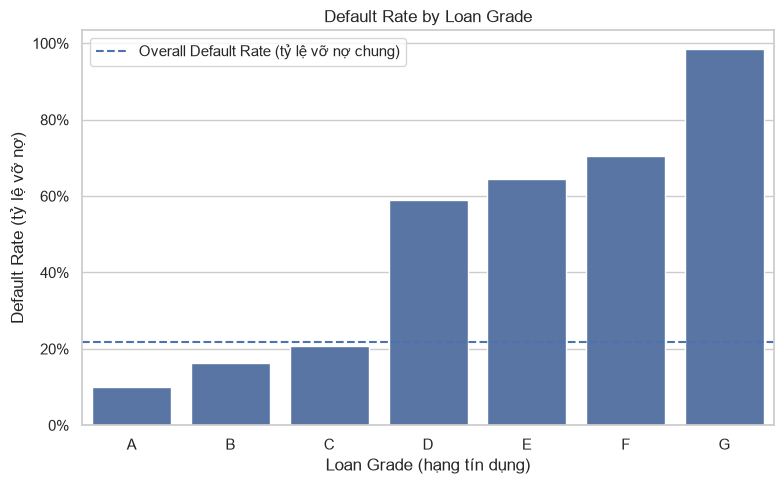


--- loan_grade vs target ---


,loan_grade,count,default_count,default_rate,row_share,default_rate_gap
0,A,10777,1073,9.96%,33.08%,-11.86%
1,B,10451,1701,16.28%,32.08%,-5.54%
2,C,6458,1339,20.73%,19.82%,-1.08%
3,D,3626,2141,59.05%,11.13%,+37.23%
4,E,964,621,64.42%,2.96%,+42.60%
5,F,241,170,70.54%,0.74%,+48.72%
6,G,64,63,98.44%,0.20%,+76.62%


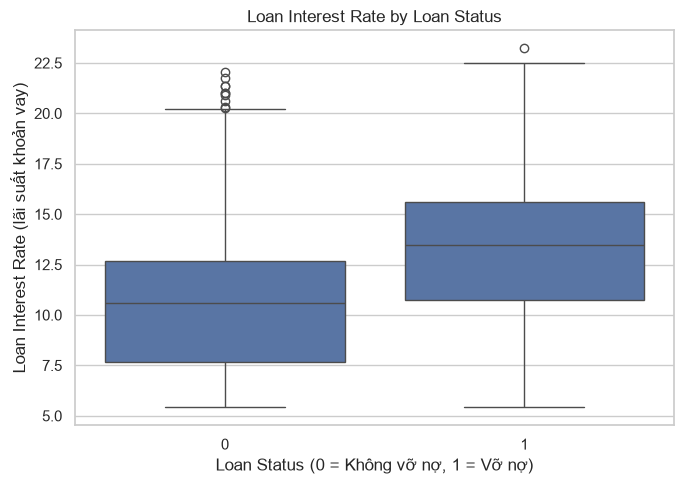


--- loan_int_rate vs target ---


,loan_status,count,mean,median,std,min,max
0,0,23001,10.44,10.59,2.98,5.42,22.06
1,1,6464,13.06,13.49,3.29,5.42,23.22


Median difference (chênh lệch trung vị, Default - Non-default): +2.90

LEAKAGE REVIEW TABLE - BẢNG ĐÁNH GIÁ NGUY CƠ RÒ RỈ


,feature,feature_type,missing_rate,eda_signal,feature_availability_risk,risk_reason,temporary_decision
0,loan_grade,categorical,0.00%,Default Rate Spread = 60.58%,high,"loan_grade có thể là kết quả của Underwriting (quá trình thẩm định tín dụng), tức là được tạo sau khi rủi ro khách hàng đã được đánh giá.",Không dùng trong Primary Baseline (mô hình cơ sở chính) cho đến khi hoàn thành Leakage Audit (kiểm tra rò rỉ dữ liệu).
1,loan_int_rate,numeric,9.56%,Median(Default) - Median(Non-default) = +2.90,high,"loan_int_rate có thể được xác định trong hoặc sau Underwriting (quá trình thẩm định tín dụng), nên có thể đã chứa kết quả đánh giá rủi ro.",Không dùng trong Primary Baseline (mô hình cơ sở chính) cho đến khi xác minh Application-time Availability (biến có sẵn tại thời điểm khách hàng xin vay).



--- Leakage note (ghi chú về rò rỉ dữ liệu) ---
EDA cho phép phân tích loan_grade và loan_int_rate để hiểu Risk Signal (tín hiệu rủi ro), nhưng sức dự báo mạnh không đồng nghĩa feature hợp lệ cho modeling. Cả hai biến đều có Feature Availability Risk (rủi ro về thời điểm biến xuất hiện). Quyết định cuối cùng phải được thực hiện trong Leakage Audit (kiểm tra rò rỉ dữ liệu), dựa trên Data Provenance (nguồn gốc/quá trình hình thành dữ liệu) và Application-time Availability (khả năng biến đã tồn tại tại thời điểm xin vay).


In [18]:
# 7.1 - Leakage review

# ============================================================
# 1. Kiểm tra input
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(
        f"Không tìm thấy target column: {TARGET_COL}"
    )

if "potential_leakage_cols" not in globals():
    potential_leakage_cols = [
        col for col in [
            "loan_grade",
            "loan_int_rate",
        ]
        if col in df_raw.columns
    ]

leakage_cols = [
    col for col in potential_leakage_cols
    if col in df_raw.columns
]

if not leakage_cols:
    raise ValueError(
        "Không tìm thấy potential leakage features "
        "(các biến có nguy cơ rò rỉ dữ liệu)."
    )

valid_target_mask = (
    df_raw[TARGET_COL].isin([0, 1])
)

overall_default_rate = float(
    df_raw.loc[
        valid_target_mask,
        TARGET_COL
    ].mean()
)

# ============================================================
# 2. Chuẩn bị containers
# ============================================================

leakage_review_records = []
leakage_detail_tables = {}

print("=" * 90)
print(
    "POTENTIAL LEAKAGE REVIEW - "
    "ĐÁNH GIÁ NGUY CƠ RÒ RỈ DỮ LIỆU"
)
print("=" * 90)

print(
    f"Overall Default Rate "
    f"(tỷ lệ vỡ nợ chung): "
    f"{overall_default_rate:.2%}"
)

# ============================================================
# 3. Review loan_grade
# ============================================================

if "loan_grade" in leakage_cols:

    grade_data = (
        df_raw.loc[
            valid_target_mask,
            ["loan_grade", TARGET_COL]
        ]
        .copy()
    )

    grade_data["loan_grade"] = (
        grade_data["loan_grade"]
        .astype("string")
        .fillna("<Missing>")
    )

    loan_grade_target_table = (
        grade_data
        .groupby(
            "loan_grade",
            dropna=False
        )[TARGET_COL]
        .agg(
            count="size",
            default_count="sum",
            default_rate="mean",
        )
        .reset_index()
    )

    loan_grade_target_table["row_share"] = (
        loan_grade_target_table["count"]
        / len(grade_data)
    )

    loan_grade_target_table[
        "default_rate_gap"
    ] = (
        loan_grade_target_table["default_rate"]
        - overall_default_rate
    )

    loan_grade_target_table = (
        loan_grade_target_table
        .sort_values("loan_grade")
        .reset_index(drop=True)
    )

    leakage_detail_tables[
        "loan_grade"
    ] = loan_grade_target_table

    reliable_grade_table = (
        loan_grade_target_table.loc[
            loan_grade_target_table["count"] >= 100
        ]
    )

    if len(reliable_grade_table) >= 2:
        grade_default_rate_spread = float(
            reliable_grade_table[
                "default_rate"
            ].max()
            - reliable_grade_table[
                "default_rate"
            ].min()
        )
    else:
        grade_default_rate_spread = np.nan

    # --------------------------------------------------------
    # Plot Default Rate theo loan grade
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=loan_grade_target_table,
        x="loan_grade",
        y="default_rate",
    )

    ax.axhline(
        overall_default_rate,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Overall Default Rate "
            "(tỷ lệ vỡ nợ chung)"
        ),
    )

    ax.set_title(
        "Default Rate by Loan Grade"
    )

    ax.set_xlabel(
        "Loan Grade (hạng tín dụng)"
    )

    ax.set_ylabel(
        "Default Rate (tỷ lệ vỡ nợ)"
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{y:.0%}"
        )
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        "\n--- loan_grade vs target ---"
    )

    display(
        loan_grade_target_table.style.format({
            "row_share": "{:.2%}",
            "default_rate": "{:.2%}",
            "default_rate_gap": "{:+.2%}",
        })
    )

    leakage_review_records.append({
        "feature": "loan_grade",
        "feature_type": "categorical",
        "missing_rate": (
            df_raw["loan_grade"]
            .isna()
            .mean()
        ),
        "eda_signal": (
            f"Default Rate Spread = "
            f"{grade_default_rate_spread:.2%}"
            if pd.notna(
                grade_default_rate_spread
            )
            else
            "Không đủ nhóm để tính spread."
        ),
        "feature_availability_risk": "high",
        "risk_reason": (
            "loan_grade có thể là kết quả của "
            "Underwriting (quá trình thẩm định tín dụng), "
            "tức là được tạo sau khi rủi ro khách hàng "
            "đã được đánh giá."
        ),
        "temporary_decision": (
            "Không dùng trong Primary Baseline "
            "(mô hình cơ sở chính) cho đến khi hoàn thành "
            "Leakage Audit (kiểm tra rò rỉ dữ liệu)."
        ),
    })

# ============================================================
# 4. Review loan_int_rate
# ============================================================

if "loan_int_rate" in leakage_cols:

    rate_data = (
        df_raw.loc[
            valid_target_mask,
            [
                "loan_int_rate",
                TARGET_COL,
            ]
        ]
        .copy()
    )

    loan_int_rate_target_table = (
        rate_data
        .groupby(TARGET_COL)[
            "loan_int_rate"
        ]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
        )
        .reset_index()
    )

    leakage_detail_tables[
        "loan_int_rate"
    ] = loan_int_rate_target_table

    rate_non_default = (
        rate_data.loc[
            rate_data[TARGET_COL] == 0,
            "loan_int_rate"
        ]
    )

    rate_default = (
        rate_data.loc[
            rate_data[TARGET_COL] == 1,
            "loan_int_rate"
        ]
    )

    median_non_default = float(
        rate_non_default.median()
    )

    median_default = float(
        rate_default.median()
    )

    rate_median_gap = (
        median_default
        - median_non_default
    )

    # --------------------------------------------------------
    # Boxplot theo target
    # --------------------------------------------------------

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=rate_data,
        x=TARGET_COL,
        y="loan_int_rate",
    )

    plt.title(
        "Loan Interest Rate by Loan Status"
    )

    plt.xlabel(
        "Loan Status "
        "(0 = Không vỡ nợ, 1 = Vỡ nợ)"
    )

    plt.ylabel(
        "Loan Interest Rate "
        "(lãi suất khoản vay)"
    )

    plt.tight_layout()
    plt.show()

    print(
        "\n--- loan_int_rate vs target ---"
    )

    display(
        loan_int_rate_target_table.style.format({
            "mean": "{:.2f}",
            "median": "{:.2f}",
            "std": "{:.2f}",
            "min": "{:.2f}",
            "max": "{:.2f}",
        })
    )

    print(
        "Median difference "
        "(chênh lệch trung vị, Default - Non-default): "
        f"{rate_median_gap:+.2f}"
    )

    leakage_review_records.append({
        "feature": "loan_int_rate",
        "feature_type": "numeric",
        "missing_rate": (
            df_raw["loan_int_rate"]
            .isna()
            .mean()
        ),
        "eda_signal": (
            "Median(Default) - Median(Non-default) = "
            f"{rate_median_gap:+.2f}"
        ),
        "feature_availability_risk": "high",
        "risk_reason": (
            "loan_int_rate có thể được xác định trong "
            "hoặc sau Underwriting "
            "(quá trình thẩm định tín dụng), "
            "nên có thể đã chứa kết quả đánh giá rủi ro."
        ),
        "temporary_decision": (
            "Không dùng trong Primary Baseline "
            "(mô hình cơ sở chính) cho đến khi xác minh "
            "Application-time Availability "
            "(biến có sẵn tại thời điểm khách hàng xin vay)."
        ),
    })

# ============================================================
# 5. Tạo Leakage Review Table
# ============================================================

leakage_review_table = pd.DataFrame(
    leakage_review_records
)

# ============================================================
# 6. Leakage note
# ============================================================

leakage_note = (
    "EDA cho phép phân tích loan_grade và loan_int_rate "
    "để hiểu Risk Signal (tín hiệu rủi ro), nhưng sức dự báo "
    "mạnh không đồng nghĩa feature hợp lệ cho modeling. "
    "Cả hai biến đều có Feature Availability Risk "
    "(rủi ro về thời điểm biến xuất hiện). "
    "Quyết định cuối cùng phải được thực hiện trong "
    "Leakage Audit (kiểm tra rò rỉ dữ liệu), dựa trên "
    "Data Provenance (nguồn gốc/quá trình hình thành dữ liệu) "
    "và Application-time Availability "
    "(khả năng biến đã tồn tại tại thời điểm xin vay)."
)

# ============================================================
# 7. Display
# ============================================================

print()
print("=" * 90)
print(
    "LEAKAGE REVIEW TABLE - "
    "BẢNG ĐÁNH GIÁ NGUY CƠ RÒ RỈ"
)
print("=" * 90)

display(
    leakage_review_table.style.format({
        "missing_rate": "{:.2%}",
    })
)

print(
    "\n--- Leakage note "
    "(ghi chú về rò rỉ dữ liệu) ---"
)

print(leakage_note)

FAIRNESS / PROXY REVIEW - KIỂM TRA BIẾN NHẠY CẢM VÀ BIẾN ĐẠI DIỆN
Overall Default Rate (tỷ lệ vỡ nợ chung): 21.82%

gender - Default Rate by Group


,group,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Female,16210,3545,21.87%,49.75%,+0.05%,0.05%,False
1,Male,16371,3563,21.76%,50.25%,-0.05%,0.05%,False


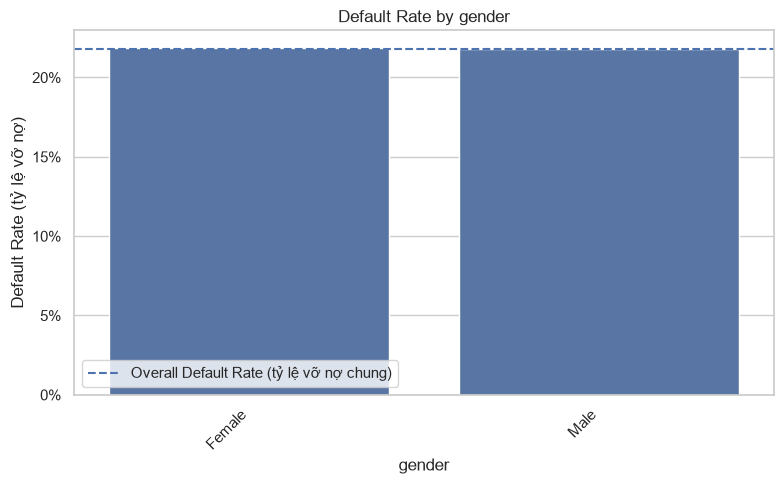


country - Default Rate by Group


,group,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Canada,10785,2358,21.86%,33.10%,+0.05%,0.05%,False
1,USA,10852,2372,21.86%,33.31%,+0.04%,0.04%,False
2,UK,10944,2378,21.73%,33.59%,-0.09%,0.09%,False


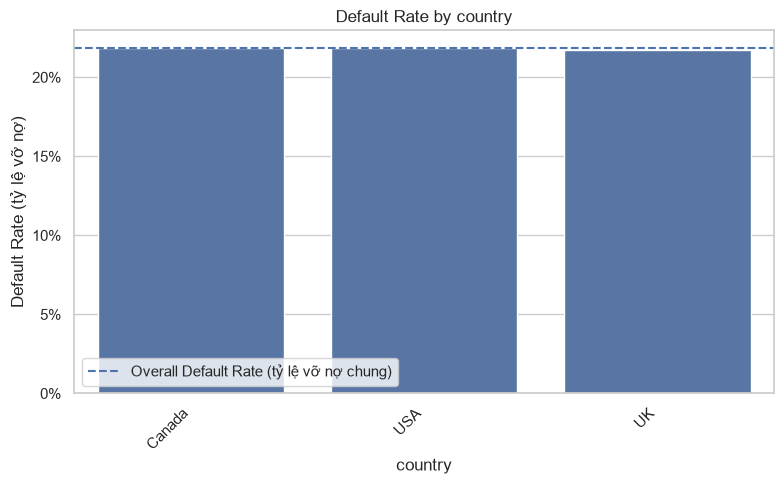


state - Default Rate by Group


,group,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Scotland,3648,821,22.51%,11.20%,+0.69%,0.69%,False
1,BC,3679,827,22.48%,11.29%,+0.66%,0.66%,False
2,California,3679,822,22.34%,11.29%,+0.53%,0.53%,False
3,Texas,3608,802,22.23%,11.07%,+0.41%,0.41%,False
4,Ontario,3553,778,21.90%,10.91%,+0.08%,0.08%,False
5,England,3654,797,21.81%,11.22%,-0.00%,0.00%,False
6,Quebec,3553,753,21.19%,10.91%,-0.62%,0.62%,False
7,New York,3565,748,20.98%,10.94%,-0.83%,0.83%,False
8,Wales,3642,760,20.87%,11.18%,-0.95%,0.95%,False


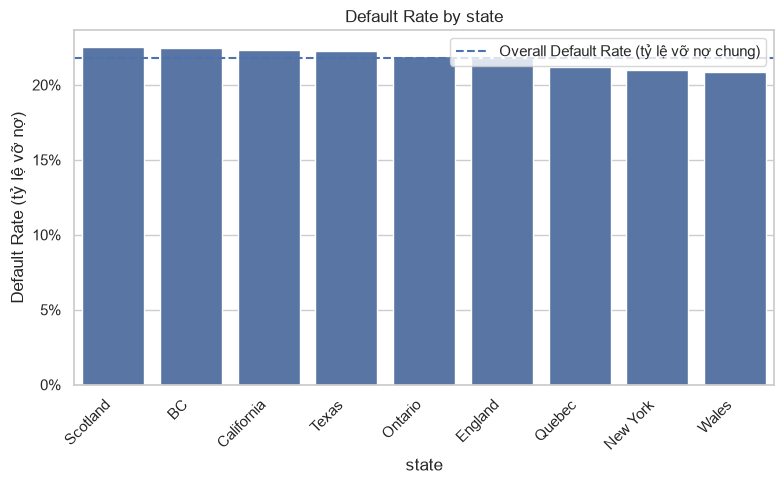


city - Default Rate by Group


,group,count,default_count,default_rate,row_share,default_rate_gap,abs_default_rate_gap,small_group_flag
0,Vancouver,1827,442,24.19%,5.61%,+2.38%,2.38%,False
1,Dallas,1797,424,23.59%,5.52%,+1.78%,1.78%,False
2,Edinburgh,1807,424,23.46%,5.55%,+1.65%,1.65%,False
3,Los Angeles,1838,420,22.85%,5.64%,+1.03%,1.03%,False
4,Manchester,1803,406,22.52%,5.53%,+0.70%,0.70%,False
5,Toronto,1751,385,21.99%,5.37%,+0.17%,0.17%,False
6,Montreal,1799,394,21.90%,5.52%,+0.08%,0.08%,False
7,San Francisco,1841,402,21.84%,5.65%,+0.02%,0.02%,False
8,Ottawa,1802,393,21.81%,5.53%,-0.01%,0.01%,False
9,Glasgow,1841,397,21.56%,5.65%,-0.25%,0.25%,False


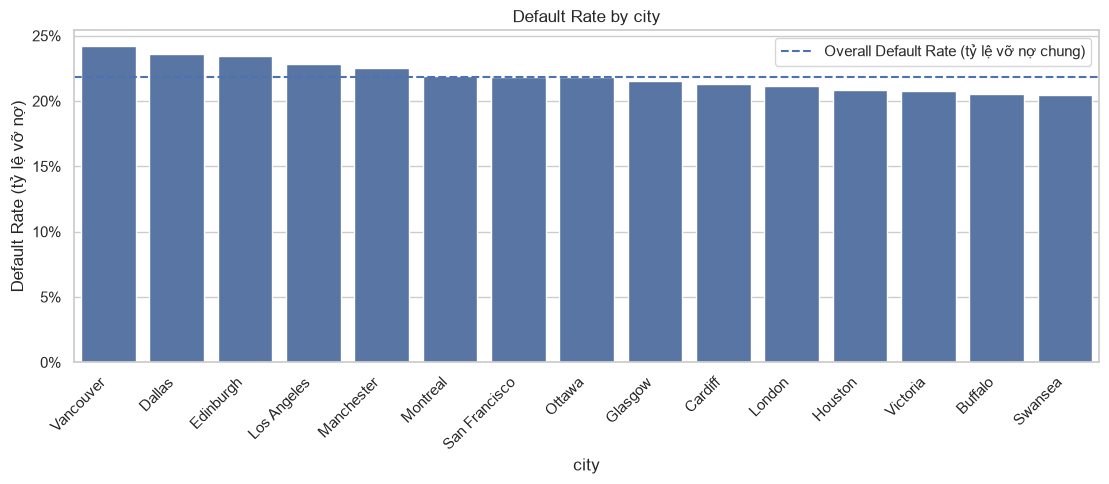


FAIRNESS / PROXY SUMMARY - TỔNG HỢP KIỂM TRA


,column,group_count,reliable_group_count,small_group_count,min_default_rate,max_default_rate,default_rate_spread,max_abs_gap_vs_overall,review_role
0,city,18,18,0,20.43%,24.19%,3.76%,2.38%,Fairness/Proxy Audit only (chỉ dùng để kiểm tra tính công bằng/biến đại diện)
1,state,9,9,0,20.87%,22.51%,1.64%,0.95%,Fairness/Proxy Audit only (chỉ dùng để kiểm tra tính công bằng/biến đại diện)
2,country,3,3,0,21.73%,21.86%,0.13%,0.09%,Fairness/Proxy Audit only (chỉ dùng để kiểm tra tính công bằng/biến đại diện)
3,gender,2,2,0,21.76%,21.87%,0.11%,0.05%,Fairness/Proxy Audit only (chỉ dùng để kiểm tra tính công bằng/biến đại diện)



--- Continuous proxy note (ghi chú biến đại diện dạng số) ---
Các biến city_latitude, city_longitude là Geographic Proxy Variables (biến địa lý có thể đại diện gián tiếp cho đặc điểm nhóm khách hàng). Không kết luận fairness trực tiếp bằng cách so Default Rate theo từng giá trị số; cần review ở Fairness Analysis (phân tích công bằng) sau này.

--- Fairness / proxy note (ghi chú về tính công bằng và biến đại diện) ---
Sự khác biệt Default Rate giữa gender, country, state hoặc city chỉ là EDA Observation (quan sát từ phân tích khám phá). Nó không chứng minh dataset hoặc model có Bias (thiên lệch) hay Discrimination (phân biệt đối xử). Các nhóm có small_group_flag = True có Sample Size (cỡ mẫu) nhỏ nên tỷ lệ vỡ nợ có thể không ổn định. gender và các geographic variables (biến địa lý) không nên tự động được đưa vào Primary Model chỉ vì chúng có tín hiệu mạnh. Fairness chính thức phải được đánh giá sau khi có model bằng các Fairness Metrics (chỉ số đánh giá tính công bằng).


In [19]:
# 7.2 - Fairness / proxy review

# ============================================================
# 1. Kiểm tra input
# ============================================================

if TARGET_COL not in df_raw.columns:
    raise KeyError(
        f"Không tìm thấy target column: {TARGET_COL}"
    )

if "sensitive_or_proxy_cols" not in globals():
    sensitive_or_proxy_cols = [
        col for col in [
            "gender",
            "country",
            "state",
            "city",
            "city_latitude",
            "city_longitude",
        ]
        if col in df_raw.columns
    ]

valid_target_mask = (
    df_raw[TARGET_COL].isin([0, 1])
)

valid_target_rows = int(
    valid_target_mask.sum()
)

overall_default_rate = float(
    df_raw.loc[
        valid_target_mask,
        TARGET_COL
    ].mean()
)

# ============================================================
# 2. Chọn các biến phù hợp để group review
# ============================================================

# Các biến categorical có thể xem Default Rate theo nhóm
fairness_group_priority = [
    "gender",
    "country",
    "state",
    "city",
]

fairness_group_cols = [
    col for col in fairness_group_priority
    if col in sensitive_or_proxy_cols
    and col in df_raw.columns
]

# Latitude/longitude là numeric proxy variables.
# Không group trực tiếp trong cell này.
continuous_proxy_cols = [
    col for col in [
        "city_latitude",
        "city_longitude",
    ]
    if col in sensitive_or_proxy_cols
    and col in df_raw.columns
]

# ============================================================
# 3. Cấu hình Small Group
# ============================================================

SMALL_GROUP_MIN_COUNT = 100
SMALL_GROUP_MIN_SHARE = 0.005

fairness_proxy_tables = {}
fairness_proxy_records = []

# ============================================================
# 4. Phân tích từng sensitive/proxy group
# ============================================================

for column in fairness_group_cols:

    temp = (
        df_raw.loc[
            valid_target_mask,
            [
                column,
                TARGET_COL,
            ]
        ]
        .copy()
    )

    temp["group"] = (
        temp[column]
        .astype("string")
        .fillna("<Missing>")
    )

    group_table = (
        temp
        .groupby(
            "group",
            dropna=False
        )[TARGET_COL]
        .agg(
            count="size",
            default_count="sum",
            default_rate="mean",
        )
        .reset_index()
    )

    group_table["row_share"] = (
        group_table["count"]
        / valid_target_rows
    )

    group_table[
        "default_rate_gap"
    ] = (
        group_table["default_rate"]
        - overall_default_rate
    )

    group_table[
        "abs_default_rate_gap"
    ] = (
        group_table[
            "default_rate_gap"
        ].abs()
    )

    # --------------------------------------------------------
    # Đánh dấu nhóm có sample nhỏ
    # --------------------------------------------------------

    group_table[
        "small_group_flag"
    ] = (
        (
            group_table["count"]
            < SMALL_GROUP_MIN_COUNT
        )
        |
        (
            group_table["row_share"]
            < SMALL_GROUP_MIN_SHARE
        )
    )

    group_table = (
        group_table
        .sort_values(
            "default_rate",
            ascending=False
        )
        .reset_index(drop=True)
    )

    fairness_proxy_tables[
        column
    ] = group_table

    # ========================================================
    # 5. Summary chỉ dùng các group đủ lớn
    # ========================================================

    reliable_groups = (
        group_table.loc[
            ~group_table[
                "small_group_flag"
            ]
        ]
    )

    if len(reliable_groups) >= 2:

        min_default_rate = float(
            reliable_groups[
                "default_rate"
            ].min()
        )

        max_default_rate = float(
            reliable_groups[
                "default_rate"
            ].max()
        )

        default_rate_spread = (
            max_default_rate
            - min_default_rate
        )

        max_abs_gap = float(
            reliable_groups[
                "abs_default_rate_gap"
            ].max()
        )

    else:
        min_default_rate = np.nan
        max_default_rate = np.nan
        default_rate_spread = np.nan
        max_abs_gap = np.nan

    fairness_proxy_records.append({
        "column": column,
        "group_count": int(
            len(group_table)
        ),
        "reliable_group_count": int(
            len(reliable_groups)
        ),
        "small_group_count": int(
            group_table[
                "small_group_flag"
            ].sum()
        ),
        "min_default_rate": (
            min_default_rate
        ),
        "max_default_rate": (
            max_default_rate
        ),
        "default_rate_spread": (
            default_rate_spread
        ),
        "max_abs_gap_vs_overall": (
            max_abs_gap
        ),
        "review_role": (
            "Fairness/Proxy Audit only "
            "(chỉ dùng để kiểm tra tính công bằng/"
            "biến đại diện)"
        ),
    })

# ============================================================
# 6. Tạo summary table
# ============================================================

fairness_proxy_summary = (
    pd.DataFrame(
        fairness_proxy_records
    )
)

if not fairness_proxy_summary.empty:
    fairness_proxy_summary = (
        fairness_proxy_summary
        .sort_values(
            "default_rate_spread",
            ascending=False,
            na_position="last",
        )
        .reset_index(drop=True)
    )

# ============================================================
# 7. Display từng table
# ============================================================

print("=" * 90)
print(
    "FAIRNESS / PROXY REVIEW - "
    "KIỂM TRA BIẾN NHẠY CẢM VÀ BIẾN ĐẠI DIỆN"
)
print("=" * 90)

print(
    f"Overall Default Rate "
    f"(tỷ lệ vỡ nợ chung): "
    f"{overall_default_rate:.2%}"
)

for column, table in fairness_proxy_tables.items():

    print()
    print("=" * 90)
    print(
        f"{column} - Default Rate by Group"
    )
    print("=" * 90)

    display(
        table.style.format({
            "row_share": "{:.2%}",
            "default_rate": "{:.2%}",
            "default_rate_gap": "{:+.2%}",
            "abs_default_rate_gap": "{:.2%}",
        })
    )

    # --------------------------------------------------------
    # Chỉ trực quan hóa tối đa 15 nhóm lớn nhất
    # --------------------------------------------------------

    plot_table = (
        table
        .sort_values(
            "count",
            ascending=False
        )
        .head(15)
        .sort_values(
            "default_rate",
            ascending=False
        )
    )

    plt.figure(
        figsize=(
            max(
                8,
                len(plot_table) * 0.75
            ),
            5,
        )
    )

    ax = sns.barplot(
        data=plot_table,
        x="group",
        y="default_rate",
    )

    ax.axhline(
        overall_default_rate,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Overall Default Rate "
            "(tỷ lệ vỡ nợ chung)"
        ),
    )

    ax.set_title(
        f"Default Rate by {column}"
    )

    ax.set_xlabel(column)

    ax.set_ylabel(
        "Default Rate "
        "(tỷ lệ vỡ nợ)"
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{y:.0%}"
        )
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. Continuous proxy note
# ============================================================

continuous_proxy_note = (
    "Không có continuous geographic proxy "
    "(biến đại diện địa lý dạng số) cần review."
)

if continuous_proxy_cols:
    continuous_proxy_note = (
        "Các biến "
        + ", ".join(
            continuous_proxy_cols
        )
        + " là Geographic Proxy Variables "
        "(biến địa lý có thể đại diện gián tiếp cho "
        "đặc điểm nhóm khách hàng). "
        "Không kết luận fairness trực tiếp bằng cách "
        "so Default Rate theo từng giá trị số; "
        "cần review ở Fairness Analysis "
        "(phân tích công bằng) sau này."
    )

# ============================================================
# 9. Fairness / proxy note
# ============================================================

fairness_proxy_note = (
    "Sự khác biệt Default Rate giữa gender, country, state "
    "hoặc city chỉ là EDA Observation "
    "(quan sát từ phân tích khám phá). "
    "Nó không chứng minh dataset hoặc model có Bias "
    "(thiên lệch) hay Discrimination "
    "(phân biệt đối xử). "
    "Các nhóm có small_group_flag = True có Sample Size "
    "(cỡ mẫu) nhỏ nên tỷ lệ vỡ nợ có thể không ổn định. "
    "gender và các geographic variables "
    "(biến địa lý) không nên tự động được đưa vào "
    "Primary Model chỉ vì chúng có tín hiệu mạnh. "
    "Fairness chính thức phải được đánh giá sau khi có model "
    "bằng các Fairness Metrics "
    "(chỉ số đánh giá tính công bằng)."
)

# ============================================================
# 10. Display summary
# ============================================================

print()
print("=" * 90)
print(
    "FAIRNESS / PROXY SUMMARY - "
    "TỔNG HỢP KIỂM TRA"
)
print("=" * 90)

if fairness_proxy_summary.empty:
    print(
        "Không có categorical sensitive/proxy variable "
        "để phân tích."
    )
else:
    display(
        fairness_proxy_summary.style.format({
            "min_default_rate": "{:.2%}",
            "max_default_rate": "{:.2%}",
            "default_rate_spread": "{:.2%}",
            "max_abs_gap_vs_overall": "{:.2%}",
        })
    )

print(
    "\n--- Continuous proxy note "
    "(ghi chú biến đại diện dạng số) ---"
)

print(continuous_proxy_note)

print(
    "\n--- Fairness / proxy note "
    "(ghi chú về tính công bằng và biến đại diện) ---"
)

print(fairness_proxy_note)

## Section 8 - Tổng hợp EDA Findings

Phần cuối cần gom phát hiện thành bảng để chuyển sang report và giai đoạn Feature Analysis.

Mỗi finding nên có:
- Theme.
- Finding.
- Evidence.
- Risk/interpretation.
- Next action.

In [20]:
# 8.1 - Tạo bảng EDA findings

# ============================================================
# 1. Helper functions
# ============================================================

def _fmt_pct(value):
    if value is None or pd.isna(value):
        return "N/A"
    return f"{float(value):.2%}"


def _fmt_num(value, digits=2):
    if value is None or pd.isna(value):
        return "N/A"
    return f"{float(value):,.{digits}f}"


def _list_preview(values, max_items=5):
    values = list(values) if values is not None else []
    if not values:
        return "None"
    shown = values[:max_items]
    suffix = "" if len(values) <= max_items else f", +{len(values) - max_items} more"
    return ", ".join(map(str, shown)) + suffix


eda_finding_records = []

# ============================================================
# 2. Target finding
# ============================================================

eda_finding_records.append({
    "theme": "target",
    "finding": "Target has a usable binary default/non-default structure.",
    "evidence": (
        f"Default rate = {_fmt_pct(globals().get('default_rate'))}; "
        f"imbalance ratio = {_fmt_num(globals().get('class_imbalance_ratio'))}:1; "
        f"target missing = {globals().get('target_missing_count', 'N/A')}."
    ),
    "risk_or_interpretation": (
        "Class balance is acceptable for EDA, but later modeling should still "
        "track ROC-AUC, PR-AUC, recall/precision, and calibration instead of accuracy only."
    ),
    "next_action": "Use this default rate as baseline and benchmark all models against it.",
})

# ============================================================
# 3. Feature grouping finding
# ============================================================

eda_finding_records.append({
    "theme": "feature_groups",
    "finding": "Features are separated into numeric, categorical, leakage-watch, and proxy-watch groups.",
    "evidence": (
        f"{len(globals().get('numeric_feature_cols', []))} numeric features; "
        f"{len(globals().get('categorical_feature_cols', []))} categorical features; "
        f"leakage watchlist = {_list_preview(globals().get('potential_leakage_cols', []))}; "
        f"proxy watchlist = {_list_preview(globals().get('sensitive_or_proxy_cols', []))}."
    ),
    "risk_or_interpretation": (
        "Clear grouping reduces the chance of mixing audit-only variables into the primary model."
    ),
    "next_action": "Carry these groups into feature analysis and preprocessing configuration.",
})

# ============================================================
# 4. Numeric distribution finding
# ============================================================

numeric_review_cols = globals().get("numeric_review_cols", [])
top_numeric_review = numeric_review_cols[:5]

eda_finding_records.append({
    "theme": "numeric_distribution",
    "finding": "Several numeric variables need preprocessing review before modeling.",
    "evidence": (
        f"{len(numeric_review_cols)} / {len(globals().get('numeric_feature_cols', []))} "
        f"numeric features were flagged; top examples = {_list_preview(top_numeric_review)}."
    ),
    "risk_or_interpretation": (
        "Missingness, skewness, extreme values, or audit-watch flags can distort model fitting "
        "if handled inconsistently."
    ),
    "next_action": "Review imputation, robust scaling/log transforms, and business-rule treatment in the pipeline.",
})

# ============================================================
# 5. Numeric target relationship finding
# ============================================================

top_numeric_target_drivers = globals().get("top_numeric_target_drivers", [])

if "numeric_target_driver_summary" in globals() and not numeric_target_driver_summary.empty:
    top_numeric_driver_evidence = (
        numeric_target_driver_summary
        .head(5)[["column", "standardized_median_diff"]]
        .assign(
            standardized_median_diff=lambda frame: frame["standardized_median_diff"].map(
                lambda value: _fmt_num(value, 2)
            )
        )
    )
    numeric_driver_evidence = "; ".join(
        f"{row.column} ({row.standardized_median_diff})"
        for row in top_numeric_driver_evidence.itertuples(index=False)
    )
else:
    numeric_driver_evidence = "No numeric target driver summary available."

eda_finding_records.append({
    "theme": "numeric_target",
    "finding": "Some numeric variables show visible separation between default and non-default groups.",
    "evidence": numeric_driver_evidence,
    "risk_or_interpretation": (
        "These are EDA signals, not proof of stable predictive value; differences must be validated out-of-sample."
    ),
    "next_action": "Prioritize these variables in feature analysis, but confirm with cross-validation and stability checks.",
})

# ============================================================
# 6. Categorical target finding
# ============================================================

if "categorical_target_driver_summary" in globals() and not categorical_target_driver_summary.empty:
    top_categorical_rows = categorical_target_driver_summary.head(5).copy()
    categorical_evidence_parts = []
    for row in top_categorical_rows.itertuples(index=False):
        column = getattr(row, "column", None)
        spread = getattr(row, "default_rate_spread", np.nan)
        categorical_evidence_parts.append(
            f"{column} spread={_fmt_pct(spread)}"
        )
    categorical_evidence = "; ".join(categorical_evidence_parts)
else:
    categorical_evidence = "No categorical target driver summary available."

eda_finding_records.append({
    "theme": "categorical_target",
    "finding": "Categorical groups show different observed default rates.",
    "evidence": categorical_evidence,
    "risk_or_interpretation": (
        "High-cardinality or small groups can produce unstable default-rate estimates."
    ),
    "next_action": "Use rare-category handling and validate encoding choices before modeling.",
})

# ============================================================
# 7. Missingness finding
# ============================================================

missing_indicator_candidates = globals().get("missing_indicator_candidates", [])
higher_priority_missing_indicators = globals().get("higher_priority_missing_indicators", [])

eda_finding_records.append({
    "theme": "missing",
    "finding": "Missingness may carry target signal for selected features.",
    "evidence": (
        f"Missing indicator candidates = {_list_preview(missing_indicator_candidates)}; "
        f"higher-priority = {_list_preview(higher_priority_missing_indicators)}."
    ),
    "risk_or_interpretation": (
        "Missing indicators can help if missingness is informative, but they can also overfit data collection artifacts."
    ),
    "next_action": "Test missing indicators inside the preprocessing pipeline with cross-validation.",
})

# ============================================================
# 8. Outlier finding
# ============================================================

if "outlier_check_summary" in globals() and not outlier_check_summary.empty:
    outlier_evidence = "; ".join(
        f"{row.check}: {int(row.affected_rows):,} rows ({_fmt_pct(row.rate)})"
        for row in outlier_check_summary.itertuples(index=False)
    )
else:
    outlier_evidence = "No outlier check summary available."

eda_finding_records.append({
    "theme": "outlier",
    "finding": "Business-rule outlier checks identify rows that need source-data review.",
    "evidence": outlier_evidence,
    "risk_or_interpretation": (
        "Dropping or clipping rows during EDA would hide data-quality decisions that should belong to preprocessing."
    ),
    "next_action": "Document final outlier rules and apply them reproducibly in preprocessing, not in df_raw.",
})

# ============================================================
# 9. Correlation / redundancy finding
# ============================================================

if "high_corr_pairs" in globals() and not high_corr_pairs.empty:
    corr_evidence = "; ".join(
        f"{row.feature_1} ~ {row.feature_2}: r={row.correlation:+.3f}"
        for row in high_corr_pairs.head(5).itertuples(index=False)
    )
elif "scatter_notes" in globals() and not scatter_notes.empty:
    corr_evidence = "; ".join(
        f"{row.feature_x} ~ {row.feature_y}: r={row.pearson_correlation:+.3f}"
        for row in scatter_notes.head(5).itertuples(index=False)
    )
else:
    corr_evidence = "No correlation summary available."

eda_finding_records.append({
    "theme": "correlation",
    "finding": "Correlation review highlights potential redundancy among numeric variables.",
    "evidence": corr_evidence,
    "risk_or_interpretation": (
        "Redundant variables can make interpretation unstable, especially for linear or scorecard-style models."
    ),
    "next_action": "Review correlated pairs during feature selection and compare keep/drop decisions by validation metrics.",
})

# ============================================================
# 10. Leakage finding
# ============================================================

if "leakage_review_table" in globals() and not leakage_review_table.empty:
    leakage_evidence = "; ".join(
        f"{row.feature}: risk={row.feature_availability_risk}, signal={row.eda_signal}"
        for row in leakage_review_table.itertuples(index=False)
    )
else:
    leakage_evidence = "No leakage review table available."

eda_finding_records.append({
    "theme": "leakage",
    "finding": "loan_grade and loan_int_rate require application-time availability checks.",
    "evidence": leakage_evidence,
    "risk_or_interpretation": (
        "Strong EDA signal from underwriting-derived variables may be leakage if the feature is unavailable at application time."
    ),
    "next_action": "Exclude high-risk leakage-watch variables from the primary baseline until provenance is confirmed.",
})

# ============================================================
# 11. Fairness / proxy finding
# ============================================================

if "fairness_proxy_summary" in globals() and not fairness_proxy_summary.empty:
    fairness_evidence = "; ".join(
        f"{row.column}: spread={_fmt_pct(row.default_rate_spread)}, "
        f"small_groups={int(row.small_group_count)}"
        for row in fairness_proxy_summary.head(5).itertuples(index=False)
    )
else:
    fairness_evidence = "No categorical fairness/proxy summary available."

eda_finding_records.append({
    "theme": "fairness_proxy",
    "finding": "Sensitive/proxy variables should be treated as audit variables, not automatic model inputs.",
    "evidence": fairness_evidence,
    "risk_or_interpretation": (
        "Group default-rate differences are descriptive EDA observations and do not prove model bias by themselves."
    ),
    "next_action": "Reserve these variables for fairness/proxy audit and evaluate formal fairness metrics after modeling.",
})


# ============================================================
# 12. Numeric risk trend finding
# ============================================================

if "numeric_risk_band_trend_summary" in globals() and not numeric_risk_band_trend_summary.empty:
    trend_evidence = "; ".join(
        f"{row.feature}: {row.first_band}={_fmt_pct(row.first_band_default_rate)} "
        f"to {row.last_band}={_fmt_pct(row.last_band_default_rate)} "
        f"({row.end_to_end_default_rate_delta:+.2%})"
        for row in numeric_risk_band_trend_summary.itertuples(index=False)
    )
else:
    trend_evidence = "No numeric risk band trend summary available."

eda_finding_records.append({
    "theme": "numeric_risk_trend",
    "finding": "Income, loan-to-income, and debt-to-income bands provide business-readable risk trend checks.",
    "evidence": trend_evidence,
    "risk_or_interpretation": (
        "Band trends are easier to explain than raw boxplots, but they remain descriptive EDA signals."
    ),
    "next_action": "Use these trend checks to prioritize monotonic transformations or scorecard bins later.",
})

# ============================================================
# 12. Create and display final findings table
# ============================================================

eda_findings = pd.DataFrame(eda_finding_records)[
    [
        "theme",
        "finding",
        "evidence",
        "risk_or_interpretation",
        "next_action",
    ]
]

print("=" * 90)
print("EDA FINDINGS - TỔNG HỢP PHÁT HIỆN CHÍNH")
print("=" * 90)
print(f"Total findings: {len(eda_findings)}")

display(eda_findings)

EDA FINDINGS - TỔNG HỢP PHÁT HIỆN CHÍNH
Total findings: 11


,theme,finding,evidence,risk_or_interpretation,next_action
0,target,Target has a usable binary default/non-default...,Default rate = 21.82%; imbalance ratio = 3.58:...,"Class balance is acceptable for EDA, but later...",Use this default rate as baseline and benchmar...
1,feature_groups,"Features are separated into numeric, categoric...",16 numeric features; 11 categorical features; ...,Clear grouping reduces the chance of mixing au...,Carry these groups into feature analysis and p...
2,numeric_distribution,Several numeric variables need preprocessing r...,12 / 16 numeric features were flagged; top exa...,"Missingness, skewness, extreme values, or audi...","Review imputation, robust scaling/log transfor..."
3,numeric_target,Some numeric variables show visible separation...,loan_percent_income (1.03); loan_to_income_rat...,"These are EDA signals, not proof of stable pre...",Prioritize these variables in feature analysis...
4,categorical_target,Categorical groups show different observed def...,loan_grade spread=60.58%; cb_person_default_on...,High-cardinality or small groups can produce u...,Use rare-category handling and validate encodi...
5,missing,Missingness may carry target signal for select...,Missing indicator candidates = person_emp_leng...,Missing indicators can help if missingness is ...,Test missing indicators inside the preprocessi...
6,outlier,Business-rule outlier checks identify rows tha...,age_outside_plausible_range: 5 rows (0.02%); e...,Dropping or clipping rows during EDA would hid...,Document final outlier rules and apply them re...
7,correlation,Correlation review highlights potential redund...,loan_percent_income ~ loan_to_income_ratio: r=...,Redundant variables can make interpretation un...,Review correlated pairs during feature selecti...
8,leakage,loan_grade and loan_int_rate require applicati...,"loan_grade: risk=high, signal=Default Rate Spr...",Strong EDA signal from underwriting-derived va...,Exclude high-risk leakage-watch variables from...
9,fairness_proxy,Sensitive/proxy variables should be treated as...,"city: spread=3.76%, small_groups=0; state: spr...",Group default-rate differences are descriptive...,Reserve these variables for fairness/proxy aud...


In [21]:
# 8.2 - Optional export EDA findings

# ============================================================
# 1. Cấu hình export
# ============================================================

EXPORT_EDA_FINDINGS = False
EDA_FINDINGS_EXPORT_PATH = REPORT_PATH / "eda_findings_draft.md"

# ============================================================
# 2. Kiểm tra input
# ============================================================

if "eda_findings" not in globals():
    raise NameError(
        "Chưa có eda_findings. Hãy chạy cell 8.1 trước khi export."
    )

required_finding_cols = [
    "theme",
    "finding",
    "evidence",
    "risk_or_interpretation",
    "next_action",
]

missing_finding_cols = [
    col for col in required_finding_cols
    if col not in eda_findings.columns
]

if missing_finding_cols:
    raise KeyError(
        "eda_findings thiếu các cột bắt buộc: "
        + ", ".join(missing_finding_cols)
    )

has_incomplete_marker = (
    eda_findings[required_finding_cols]
    .astype("string")
    .apply(lambda col: col.str.contains("INCOMPLETE_MARKER", case=False, na=False))
    .any()
    .any()
)

if has_incomplete_marker:
    raise ValueError(
        "eda_findings vẫn còn incomplete marker; cần hoàn thiện trước khi export."
    )

# ============================================================
# 3. Export nếu bật flag
# ============================================================

if EXPORT_EDA_FINDINGS:
    REPORT_PATH.mkdir(parents=True, exist_ok=True)

    try:
        findings_markdown = eda_findings.to_markdown(index=False)
    except ImportError:
        findings_markdown = eda_findings.to_csv(index=False)

    EDA_FINDINGS_EXPORT_PATH.write_text(
        "# EDA Findings Draft\n\n"
        + findings_markdown
        + "\n",
        encoding="utf-8",
    )

    print(f"Exported EDA findings to: {EDA_FINDINGS_EXPORT_PATH}")
else:
    print(
        "EXPORT_EDA_FINDINGS = False; không ghi file. "
        "Đổi thành True khi muốn xuất reports/eda_findings_draft.md."
    )

EXPORT_EDA_FINDINGS = False; không ghi file. Đổi thành True khi muốn xuất reports/eda_findings_draft.md.


## Section 9 - Checklist trước khi hoàn thành EDA

- [x] Đã tính target distribution và default rate.
- [x] Đã phân nhóm biến numeric/categorical/ID/target.
- [x] Đã ghi numeric distribution findings.
- [x] Đã ghi numeric-by-target findings.
- [x] Đã ghi categorical distribution findings.
- [x] Đã ghi categorical default-rate findings.
- [x] Đã kiểm tra correlation/redundancy.
- [x] Đã follow-up missing/outlier từ Data Audit.
- [x] Đã ghi leakage notes.
- [x] Đã ghi fairness/proxy notes.
- [x] Đã tạo `eda_findings`.

In [22]:
# 9.1 - Checklist trạng thái EDA

# ============================================================
# 1. Tạo checklist tự động từ các object chính
# ============================================================

eda_checklist_records = [
    {
        "item": "Target distribution and default rate",
        "status": (
            "target_distribution" in globals()
            and "default_rate" in globals()
        ),
        "evidence_object": "target_distribution, default_rate",
    },
    {
        "item": "Feature grouping completed",
        "status": (
            "feature_group_summary" in globals()
            and "numeric_feature_cols" in globals()
            and "categorical_feature_cols" in globals()
        ),
        "evidence_object": "feature_group_summary",
    },
    {
        "item": "Numeric distribution reviewed",
        "status": (
            "numeric_eda_summary" in globals()
            and "numeric_summary_note" in globals()
        ),
        "evidence_object": "numeric_eda_summary, numeric_summary_note",
    },
    {
        "item": "Numeric-by-target reviewed",
        "status": (
            "numeric_target_driver_summary" in globals()
            and "numeric_target_note" in globals()
        ),
        "evidence_object": "numeric_target_driver_summary, numeric_target_note",
    },
    {
        "item": "Categorical distribution reviewed",
        "status": "categorical_eda_summary" in globals(),
        "evidence_object": "categorical_eda_summary",
    },
    {
        "item": "Categorical default-rate reviewed",
        "status": "categorical_target_driver_summary" in globals(),
        "evidence_object": "categorical_target_driver_summary",
    },
    {
        "item": "Correlation/redundancy reviewed",
        "status": (
            "correlation_summary" in globals()
            or "high_corr_pairs" in globals()
            or "scatter_notes" in globals()
        ),
        "evidence_object": "correlation_summary/high_corr_pairs/scatter_notes",
    },
    {
        "item": "Missing follow-up completed",
        "status": (
            "missing_target_summary" in globals()
            and "missing_indicator_candidates" in globals()
        ),
        "evidence_object": "missing_target_summary",
    },
    {
        "item": "Outlier follow-up completed",
        "status": (
            "outlier_check_summary" in globals()
            and "outlier_action_note" in globals()
        ),
        "evidence_object": "outlier_check_summary, outlier_action_note",
    },
    {
        "item": "Leakage notes completed",
        "status": (
            "leakage_review_table" in globals()
            and "leakage_note" in globals()
        ),
        "evidence_object": "leakage_review_table, leakage_note",
    },
    {
        "item": "Fairness/proxy notes completed",
        "status": (
            "fairness_proxy_summary" in globals()
            and "fairness_proxy_note" in globals()
        ),
        "evidence_object": "fairness_proxy_summary, fairness_proxy_note",
    },
    {
        "item": "EDA findings table created",
        "status": (
            "eda_findings" in globals()
            and not eda_findings.empty
        ),
        "evidence_object": "eda_findings",
    },
]

eda_checklist = pd.DataFrame(eda_checklist_records)
eda_checklist["status_label"] = np.where(
    eda_checklist["status"],
    "Done",
    "Pending",
)

pending_eda_items = (
    eda_checklist
    .loc[~eda_checklist["status"], "item"]
    .tolist()
)

# ============================================================
# 2. Display checklist
# ============================================================

print("=" * 90)
print("EDA COMPLETION CHECKLIST")
print("=" * 90)

display(eda_checklist[["item", "status_label", "evidence_object"]])

if pending_eda_items:
    print("\nCác mục còn chưa hoàn thành:")
    for item in pending_eda_items:
        print(f"- {item}")
else:
    print("\nTất cả checklist items đã hoàn thành.")

EDA COMPLETION CHECKLIST


,item,status_label,evidence_object
0,Target distribution and default rate,Done,"target_distribution, default_rate"
1,Feature grouping completed,Done,feature_group_summary
2,Numeric distribution reviewed,Done,"numeric_eda_summary, numeric_summary_note"
3,Numeric-by-target reviewed,Done,"numeric_target_driver_summary, numeric_target_..."
4,Categorical distribution reviewed,Done,categorical_eda_summary
5,Categorical default-rate reviewed,Done,categorical_target_driver_summary
6,Correlation/redundancy reviewed,Done,correlation_summary/high_corr_pairs/scatter_notes
7,Missing follow-up completed,Done,missing_target_summary
8,Outlier follow-up completed,Done,"outlier_check_summary, outlier_action_note"
9,Leakage notes completed,Done,"leakage_review_table, leakage_note"



Tất cả checklist items đã hoàn thành.


In [23]:
# FINAL NOTEBOOK 02 COMPLETION
# ============================================================
# Contract objects for EDA handoff into Feature Analysis.
# ============================================================

numeric_risk_band_summary = numeric_risk_band_trend_summary.copy()
categorical_risk_summary = categorical_target_driver_summary.copy()
missingness_target_summary = missing_target_summary.copy()
redundancy_summary = pd.DataFrame(redundant_records).copy()

eda_findings_summary = eda_findings.rename(columns={
    "risk_or_interpretation": "modeling_implication",
}).copy()
if "modeling_implication" not in eda_findings_summary.columns:
    eda_findings_summary["modeling_implication"] = eda_findings_summary.get("evidence", "")

eda_completion_checks = pd.DataFrame([
    {"check": "target_eda_complete", "status": "target_distribution" in globals() and default_rate is not None},
    {"check": "numeric_eda_complete", "status": "numeric_eda_summary" in globals() and "numeric_target_driver_summary" in globals()},
    {"check": "categorical_eda_complete", "status": "categorical_eda_summary" in globals() and "categorical_target_driver_summary" in globals()},
    {"check": "missingness_target_complete", "status": "missing_target_summary" in globals()},
    {"check": "risk_band_complete", "status": "numeric_risk_band_summary" in globals() and not numeric_risk_band_summary.empty},
    {"check": "correlation_redundancy_complete", "status": "redundancy_summary" in globals()},
    {"check": "leakage_descriptive_complete", "status": "leakage_review_table" in globals()},
    {"check": "fairness_proxy_review_complete", "status": "fairness_proxy_summary" in globals()},
    {"check": "eda_findings_summary_complete", "status": "eda_findings_summary" in globals() and not eda_findings_summary.empty},
])
if not eda_completion_checks["status"].all():
    failed = eda_completion_checks.loc[~eda_completion_checks["status"], "check"].tolist()
    raise AssertionError("EDA completion checks failed: " + ", ".join(failed))

display(numeric_risk_band_summary.head(20))
display(categorical_risk_summary.head(20))
display(missingness_target_summary)
display(redundancy_summary)
display(eda_findings_summary)
display(eda_completion_checks)
print("EDA Complete")


,feature,expected_direction,first_band,first_band_default_rate,last_band,last_band_default_rate,end_to_end_default_rate_delta
0,person_income,default_rate_down_when_feature_up,<25K,0.5221,>=100K,0.0953,-0.4268
1,loan_to_income_ratio,default_rate_up_when_feature_up,<10%,0.1121,>=40%,0.7473,0.6352
2,debt_to_income_ratio,default_rate_up_when_feature_up,<10%,0.1290,>=40%,0.3887,0.2597


,column,unique_count,reliable_group_count,small_group_count,min_default_rate,max_default_rate,default_rate_spread,max_abs_gap_vs_overall,potential_leakage_flag,sensitive_or_proxy_flag
0,loan_grade,7,6,1,0.0996,0.7054,0.6058,0.4872,True,False
1,cb_person_default_on_file,2,2,0,0.1839,0.3781,0.1941,0.1599,False,False
2,person_home_ownership,4,3,1,0.0747,0.3157,0.2410,0.1435,False,False
3,loan_intent,6,6,0,0.1481,0.2859,0.1378,0.0701,False,False
4,employment_type,4,4,0,0.2157,0.2267,0.0110,0.0085,False,False
5,education_level,4,4,0,0.2116,0.2217,0.0101,0.0065,False,False
6,marital_status,4,4,0,0.2137,0.2196,0.0059,0.0044,False,False
7,gender,2,2,0,0.2176,0.2187,0.0011,0.0005,False,True


,column,missing_count,missing_rate,default_rate_when_missing,default_rate_when_not_missing,default_rate_delta,abs_default_rate_delta,missing_signal
0,person_emp_length,895,0.0275,0.3151,0.2154,0.0997,0.0997,strong
1,loan_int_rate,3116,0.0956,0.2067,0.2194,-0.0127,0.0127,weak


,feature_1,feature_2,correlation,abs_correlation,known_relationship,redundancy_level,reason,recommendation
0,loan_percent_income,loan_to_income_ratio,0.9989,0.9989,True,strong_candidate,Hai biến có ý nghĩa/công thức nghiệp vụ gần nh...,Ưu tiên chỉ giữ một biến sau khi Feature Analy...
1,person_income,other_debt,0.8868,0.8868,False,monitor,Correlation cao; có thể chứa một phần thông ti...,Theo dõi ở Feature Analysis và Modeling (xây d...
2,person_age,cb_person_cred_hist_length,0.8591,0.8591,False,monitor,Correlation cao; có thể chứa một phần thông ti...,Theo dõi ở Feature Analysis và Modeling (xây d...
3,loan_to_income_ratio,debt_to_income_ratio,0.8289,0.8289,False,monitor,Correlation cao; có thể chứa một phần thông ti...,Theo dõi ở Feature Analysis và Modeling (xây d...
4,loan_percent_income,debt_to_income_ratio,0.8279,0.8279,False,monitor,Correlation cao; có thể chứa một phần thông ti...,Theo dõi ở Feature Analysis và Modeling (xây d...


,theme,finding,evidence,modeling_implication,next_action
0,target,Target has a usable binary default/non-default...,Default rate = 21.82%; imbalance ratio = 3.58:...,"Class balance is acceptable for EDA, but later...",Use this default rate as baseline and benchmar...
1,feature_groups,"Features are separated into numeric, categoric...",16 numeric features; 11 categorical features; ...,Clear grouping reduces the chance of mixing au...,Carry these groups into feature analysis and p...
2,numeric_distribution,Several numeric variables need preprocessing r...,12 / 16 numeric features were flagged; top exa...,"Missingness, skewness, extreme values, or audi...","Review imputation, robust scaling/log transfor..."
3,numeric_target,Some numeric variables show visible separation...,loan_percent_income (1.03); loan_to_income_rat...,"These are EDA signals, not proof of stable pre...",Prioritize these variables in feature analysis...
4,categorical_target,Categorical groups show different observed def...,loan_grade spread=60.58%; cb_person_default_on...,High-cardinality or small groups can produce u...,Use rare-category handling and validate encodi...
5,missing,Missingness may carry target signal for select...,Missing indicator candidates = person_emp_leng...,Missing indicators can help if missingness is ...,Test missing indicators inside the preprocessi...
6,outlier,Business-rule outlier checks identify rows tha...,age_outside_plausible_range: 5 rows (0.02%); e...,Dropping or clipping rows during EDA would hid...,Document final outlier rules and apply them re...
7,correlation,Correlation review highlights potential redund...,loan_percent_income ~ loan_to_income_ratio: r=...,Redundant variables can make interpretation un...,Review correlated pairs during feature selecti...
8,leakage,loan_grade and loan_int_rate require applicati...,"loan_grade: risk=high, signal=Default Rate Spr...",Strong EDA signal from underwriting-derived va...,Exclude high-risk leakage-watch variables from...
9,fairness_proxy,Sensitive/proxy variables should be treated as...,"city: spread=3.76%, small_groups=0; state: spr...",Group default-rate differences are descriptive...,Reserve these variables for fairness/proxy aud...


,check,status
0,target_eda_complete,True
1,numeric_eda_complete,True
2,categorical_eda_complete,True
3,missingness_target_complete,True
4,risk_band_complete,True
5,correlation_redundancy_complete,True
6,leakage_descriptive_complete,True
7,fairness_proxy_review_complete,True
8,eda_findings_summary_complete,True


EDA Complete
